# Olist Customer-Experience Risk Prediction

**Business question:** Can purchase-time and order-level information identify Olist orders at risk of a poor customer experience before the customer submits a review?

This notebook develops a leakage-safe machine learning workflow for customer-experience risk prediction. The analysis moves from raw relational data inspection through target construction, order-level joins, feature engineering, exploratory analysis, preprocessing, modeling, evaluation, interpretation, and final conclusions.

## Table of Contents
0. Title and Setup
1. Data Loading and Inspection
2. Target Definition and Population Filter
3. Data Integration (Joins and Aggregation)
4. Feature Engineering
5. Exploratory Data Analysis
6. Preprocessing
7. Model Training
8. Evaluation and Comparison
9. Feature Importance and Error Analysis
10. Conclusions and Future Work


## 0. Title and Setup

In [1]:
from pathlib import Path
import warnings

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError:
    plt = None
    sns = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "olist_data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"

warnings.filterwarnings("ignore", category=FutureWarning)
if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")
if plt is not None:
    plt.rcParams["figure.figsize"] = (10, 6)


## 1. Data Loading and Inspection

### Data Loading Scope

The first step loads the raw Olist CSV files, parses known timestamp fields, documents each table's schema and grain, and validates key uniqueness assumptions before any modeling-table joins are attempted.

The Olist data is relational. The intended final modeling grain is one row per delivered order with a valid review outcome, but this section only inspects source tables and enriches the product dimension with English category names.

### Relational Table Roles and Grain

| DataFrame | Source CSV | Grain | Primary / important keys | Role |
|---|---|---|---|---|
| `orders` | `olist_orders_dataset.csv` | One row per order | `order_id`, `customer_id` | Central order table with purchase, approval, carrier, delivery, and estimated delivery timestamps. |
| `customers` | `olist_customers_dataset.csv` | One row per order-level customer record | `customer_id`, `customer_unique_id` | Customer geography and customer identifiers. |
| `order_items` | `olist_order_items_dataset.csv` | One row per order line item | `order_id`, `order_item_id`, `product_id`, `seller_id` | Basket contents, seller linkage, item price, freight, and shipping limit. |
| `order_payments` | `olist_order_payments_dataset.csv` | One row per payment record | `order_id`, `payment_sequential` | Payment method, installment, and payment value information. |
| `order_reviews` | `olist_order_reviews_dataset.csv` | Review outcome records; local file is not unique by `review_id` or `order_id` | `review_id`, `order_id` | Review outcomes and review metadata. Only `review_score` is used to define the target. This table is treated as potentially non-unique until review deduplication is complete. |
| `products` | `olist_products_dataset.csv` plus category translation | One row per product | `product_id`, `product_category_name` | Product category and physical/listing attributes. |
| `sellers` | `olist_sellers_dataset.csv` | One row per seller | `seller_id` | Seller geography. |
| `geolocation` | `olist_geolocation_dataset.csv` | Many rows per zip-code prefix | `geolocation_zip_code_prefix` | Latitude/longitude and geographic reference table. The zip prefix is not unique. |
| `category_translation` | `product_category_name_translation.csv` | One row per product category | `product_category_name` | Portuguese-to-English product category labels. |

No order-level analytical dataset is created yet. Many-to-one aggregations and joins are deferred until the data integration section.

**Schema discovery note:** The local dataset does not have a unique `review_id`, and some orders have multiple review rows. This behavior is documented here so review deduplication can be handled explicitly before target construction.

In [2]:
data_files = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products_raw": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

missing_files = [filename for filename in data_files.values() if not (DATA_DIR / filename).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing expected raw data files: {missing_files}")

customers = pd.read_csv(DATA_DIR / data_files["customers"])
geolocation = pd.read_csv(DATA_DIR / data_files["geolocation"])
order_items = pd.read_csv(DATA_DIR / data_files["order_items"])
order_payments = pd.read_csv(DATA_DIR / data_files["order_payments"])
order_reviews = pd.read_csv(DATA_DIR / data_files["order_reviews"])
orders = pd.read_csv(DATA_DIR / data_files["orders"])
products_raw = pd.read_csv(DATA_DIR / data_files["products_raw"])
sellers = pd.read_csv(DATA_DIR / data_files["sellers"])
category_translation = pd.read_csv(DATA_DIR / data_files["category_translation"])

tables_raw = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products_raw": products_raw,
    "sellers": sellers,
    "category_translation": category_translation,
}

pd.DataFrame(
    {
        "table": tables_raw.keys(),
        "source_file": [data_files[name] for name in tables_raw.keys()],
        "rows": [df.shape[0] for df in tables_raw.values()],
        "columns": [df.shape[1] for df in tables_raw.values()],
    }
)

,table,source_file,rows,columns
0,customers,olist_customers_dataset.csv,99441,5
1,geolocation,olist_geolocation_dataset.csv,1000163,5
2,order_items,olist_order_items_dataset.csv,112650,7
3,order_payments,olist_order_payments_dataset.csv,103886,5
4,order_reviews,olist_order_reviews_dataset.csv,99224,7
5,orders,olist_orders_dataset.csv,99441,8
6,products_raw,olist_products_dataset.csv,32951,9
7,sellers,olist_sellers_dataset.csv,3095,4
8,category_translation,product_category_name_translation.csv,71,2


In [3]:
datetime_columns = {
    "orders": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
    "order_items": ["shipping_limit_date"],
    "order_reviews": ["review_creation_date", "review_answer_timestamp"],
}

datetime_parse_audit = []
for table_name, columns in datetime_columns.items():
    df = tables_raw[table_name]
    for column in columns:
        non_null_before = df[column].notna().sum()
        df[column] = pd.to_datetime(df[column], errors="coerce")
        non_null_after = df[column].notna().sum()
        datetime_parse_audit.append(
            {
                "table": table_name,
                "column": column,
                "dtype_after_parse": str(df[column].dtype),
                "non_null_before": non_null_before,
                "non_null_after": non_null_after,
                "new_missing_from_parse": non_null_before - non_null_after,
                "datetime_dtype": pd.api.types.is_datetime64_any_dtype(df[column]),
            }
        )

datetime_parse_audit = pd.DataFrame(datetime_parse_audit)
datetime_parse_audit

,table,column,dtype_after_parse,non_null_before,non_null_after,new_missing_from_parse,datetime_dtype
0,orders,order_purchase_timestamp,datetime64[ns],99441,99441,0,True
1,orders,order_approved_at,datetime64[ns],99281,99281,0,True
2,orders,order_delivered_carrier_date,datetime64[ns],97658,97658,0,True
3,orders,order_delivered_customer_date,datetime64[ns],96476,96476,0,True
4,orders,order_estimated_delivery_date,datetime64[ns],99441,99441,0,True
5,order_items,shipping_limit_date,datetime64[ns],112650,112650,0,True
6,order_reviews,review_creation_date,datetime64[ns],99224,99224,0,True
7,order_reviews,review_answer_timestamp,datetime64[ns],99224,99224,0,True


In [4]:
products = products_raw.merge(
    category_translation,
    on="product_category_name",
    how="left",
    validate="many_to_one",
)

# Use the translated product dimension for downstream inspection and analysis.
tables = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation,
}

translation_audit = pd.DataFrame(
    [
        {
            "check": "product rows preserved after category translation",
            "expected": len(products_raw),
            "actual": len(products),
            "passes": len(products_raw) == len(products),
        },
        {
            "check": "product_id uniqueness preserved after category translation",
            "expected": products_raw["product_id"].nunique(),
            "actual": products["product_id"].nunique(),
            "passes": products_raw["product_id"].nunique() == products["product_id"].nunique(),
        },
        {
            "check": "translated category column present",
            "expected": "product_category_name_english",
            "actual": "product_category_name_english" in products.columns,
            "passes": "product_category_name_english" in products.columns,
        },
    ]
)

translation_audit

,check,expected,actual,passes
0,product rows preserved after category translation,32951,32951,True
1,product_id uniqueness preserved after category...,32951,32951,True
2,translated category column present,product_category_name_english,True,True


In [5]:
def table_schema_summary(name: str, df: pd.DataFrame) -> pd.DataFrame:
    """Return a compact schema summary for one source table."""
    return pd.DataFrame(
        {
            "column": df.columns,
            "dtype": df.dtypes.astype(str).values,
            "null_count": df.isna().sum().values,
            "null_pct": (df.isna().mean().values * 100).round(2),
        }
    )


for name, df in tables.items():
    print(f"\n{name}: shape={df.shape}")
    print(f"columns={list(df.columns)}")
    display(table_schema_summary(name, df))
    display(df.head(3))


customers: shape=(99441, 5)
columns=['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


,column,dtype,null_count,null_pct
0,customer_id,object,0,0.0
1,customer_unique_id,object,0,0.0
2,customer_zip_code_prefix,int64,0,0.0
3,customer_city,object,0,0.0
4,customer_state,object,0,0.0


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



geolocation: shape=(1000163, 5)
columns=['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']


,column,dtype,null_count,null_pct
0,geolocation_zip_code_prefix,int64,0,0.0
1,geolocation_lat,float64,0,0.0
2,geolocation_lng,float64,0,0.0
3,geolocation_city,object,0,0.0
4,geolocation_state,object,0,0.0


...

,column,dtype,null_count,null_pct
0,seller_id,object,0,0.0
1,seller_zip_code_prefix,int64,0,0.0
2,seller_city,object,0,0.0
3,seller_state,object,0,0.0


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



category_translation: shape=(71, 2)
columns=['product_category_name', 'product_category_name_english']


,column,dtype,null_count,null_pct
0,product_category_name,object,0,0.0
1,product_category_name_english,object,0,0.0


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


In [6]:
key_uniqueness_checks = pd.DataFrame(
    [
        {
            "table": "orders",
            "key": "order_id",
            "expected_unique": True,
            "rows": len(orders),
            "unique_values": orders["order_id"].nunique(),
            "is_unique": orders["order_id"].nunique() == len(orders),
        },
        {
            "table": "customers",
            "key": "customer_id",
            "expected_unique": True,
            "rows": len(customers),
            "unique_values": customers["customer_id"].nunique(),
            "is_unique": customers["customer_id"].nunique() == len(customers),
        },
        {
            "table": "products",
            "key": "product_id",
            "expected_unique": True,
            "rows": len(products),
            "unique_values": products["product_id"].nunique(),
            "is_unique": products["product_id"].nunique() == len(products),
        },
        {
            "table": "sellers",
            "key": "seller_id",
            "expected_unique": True,
            "rows": len(sellers),
            "unique_values": sellers["seller_id"].nunique(),
            "is_unique": sellers["seller_id"].nunique() == len(sellers),
        },
        {
            "table": "order_reviews",
            "key": "review_id",
            "expected_unique": True,
            "rows": len(order_reviews),
            "unique_values": order_reviews["review_id"].nunique(),
            "is_unique": order_reviews["review_id"].nunique() == len(order_reviews),
        },
        {
            "table": "category_translation",
            "key": "product_category_name",
            "expected_unique": True,
            "rows": len(category_translation),
            "unique_values": category_translation["product_category_name"].nunique(dropna=False),
            "is_unique": category_translation["product_category_name"].nunique(dropna=False) == len(category_translation),
        },
        {
            "table": "geolocation",
            "key": "geolocation_zip_code_prefix",
            "expected_unique": False,
            "rows": len(geolocation),
            "unique_values": geolocation["geolocation_zip_code_prefix"].nunique(dropna=False),
            "is_unique": geolocation["geolocation_zip_code_prefix"].nunique(dropna=False) == len(geolocation),
        },
    ]
)

review_order_id_counts = order_reviews.groupby("order_id").size()
duplicate_review_behavior = review_order_id_counts.value_counts().sort_index().rename_axis("reviews_per_order").reset_index(name="n_orders")
duplicate_review_summary = pd.DataFrame(
    [
        {
            "metric": "review rows",
            "value": len(order_reviews),
        },
        {
            "metric": "unique review_ids",
            "value": order_reviews["review_id"].nunique(),
        },
        {
            "metric": "duplicate review_id rows",
            "value": int(order_reviews.duplicated("review_id").sum()),
        },
        {
            "metric": "unique reviewed order_ids",
            "value": order_reviews["order_id"].nunique(),
        },
        {
            "metric": "orders with more than one review row",
            "value": int((review_order_id_counts > 1).sum()),
        },
        {
            "metric": "maximum review rows for a single order_id",
            "value": int(review_order_id_counts.max()),
        },
    ]
)

display(key_uniqueness_checks)
display(duplicate_review_summary)
display(duplicate_review_behavior)

,table,key,expected_unique,rows,unique_values,is_unique
0,orders,order_id,True,99441,99441,True
1,customers,customer_id,True,99441,99441,True
2,products,product_id,True,32951,32951,True
3,sellers,seller_id,True,3095,3095,True
4,order_reviews,review_id,True,99224,98410,False
5,category_translation,product_category_name,True,71,71,True
6,geolocation,geolocation_zip_code_prefix,False,1000163,19015,False


,metric,value
0,review rows,99224
1,unique review_ids,98410
2,duplicate review_id rows,814
3,unique reviewed order_ids,98673
4,orders with more than one review row,547
5,maximum review rows for a single order_id,3


,reviews_per_order,n_orders
0,1,98126
1,2,543
2,3,4


In [7]:
phase_1_validation = pd.DataFrame(
    [
        {
            "validation_check": "all expected CSV files loaded",
            "status": "pass",
            "details": f"{len(tables_raw)} tables loaded from {DATA_DIR}",
        },
        {
            "validation_check": "orders.order_id is unique",
            "status": "pass" if orders["order_id"].nunique() == len(orders) else "needs review",
            "details": f"{orders['order_id'].nunique():,} unique IDs across {len(orders):,} rows",
        },
        {
            "validation_check": "customers.customer_id is unique",
            "status": "pass" if customers["customer_id"].nunique() == len(customers) else "needs review",
            "details": f"{customers['customer_id'].nunique():,} unique IDs across {len(customers):,} rows",
        },
        {
            "validation_check": "products.product_id is unique after translation",
            "status": "pass" if products["product_id"].nunique() == len(products) else "needs review",
            "details": f"{products['product_id'].nunique():,} unique IDs across {len(products):,} rows",
        },
        {
            "validation_check": "sellers.seller_id is unique",
            "status": "pass" if sellers["seller_id"].nunique() == len(sellers) else "needs review",
            "details": f"{sellers['seller_id'].nunique():,} unique IDs across {len(sellers):,} rows",
        },
        {
            "validation_check": "reviews.review_id local schema discovery",
            "status": "documented schema discovery",
            "details": f"Blueprint expected uniqueness, but local data has {order_reviews['review_id'].nunique():,} unique review_ids across {len(order_reviews):,} rows and {int(order_reviews.duplicated('review_id').sum()):,} duplicate review_id rows. Handle in Phase 2.",
        },
        {
            "validation_check": "category_translation.product_category_name is unique",
            "status": "pass" if category_translation["product_category_name"].nunique(dropna=False) == len(category_translation) else "needs review",
            "details": f"{category_translation['product_category_name'].nunique(dropna=False):,} unique categories across {len(category_translation):,} rows",
        },
        {
            "validation_check": "geolocation zip prefix is intentionally not unique",
            "status": "pass" if geolocation["geolocation_zip_code_prefix"].nunique(dropna=False) < len(geolocation) else "needs review",
            "details": f"{geolocation['geolocation_zip_code_prefix'].nunique(dropna=False):,} unique prefixes across {len(geolocation):,} rows",
        },
        {
            "validation_check": "duplicate order_id behavior in reviews documented",
            "status": "pass",
            "details": f"{int((review_order_id_counts > 1).sum()):,} order_ids have more than one review row; handle in Phase 2",
        },
        {
            "validation_check": "datetime parsing succeeded",
            "status": "pass" if datetime_parse_audit["datetime_dtype"].all() and (datetime_parse_audit["new_missing_from_parse"] == 0).all() else "needs review",
            "details": f"{datetime_parse_audit['datetime_dtype'].sum()} / {len(datetime_parse_audit)} timestamp columns parsed as datetime; no new missing values introduced",
        },
        {
            "validation_check": "Phase 1 overall result",
            "status": "pass",
            "details": "Phase 1 succeeded overall. The review_id uniqueness mismatch is documented schema discovery, not a Phase 1 failure.",
        },
    ]
)

phase_1_validation

,validation_check,status,details
0,all expected CSV files loaded,pass,9 tables loaded from /mnt/data/Programming/ML_...
1,orders.order_id is unique,pass,"99,441 unique IDs across 99,441 rows"
2,customers.customer_id is unique,pass,"99,441 unique IDs across 99,441 rows"
3,products.product_id is unique after translation,pass,"32,951 unique IDs across 32,951 rows"
4,sellers.seller_id is unique,pass,"3,095 unique IDs across 3,095 rows"
5,reviews.review_id local schema discovery,documented schema discovery,"Blueprint expected uniqueness, but local data ..."
6,category_translation.product_category_name is ...,pass,71 unique categories across 71 rows
7,geolocation zip prefix is intentionally not un...,pass,"19,015 unique prefixes across 1,000,163 rows"
8,duplicate order_id behavior in reviews documented,pass,547 order_ids have more than one review row; h...
9,datetime parsing succeeded,pass,8 / 8 timestamp columns parsed as datetime; no...


### Review Identifier Diagnostic

The local reviews table is not unique by `review_id`, and some `order_id` values have multiple review rows. This is an important schema finding because the modeling target must be defined at one row per order.

Until review deduplication is complete, `order_reviews` is treated as potentially non-unique at both the `review_id` and `order_id` levels.

In [8]:
duplicated_review_id_mask = order_reviews.duplicated("review_id", keep=False)
duplicated_order_id_mask = order_reviews.duplicated("order_id", keep=False)

review_identifier_diagnostic = pd.DataFrame(
    [
        {
            "diagnostic": "review_id is unique",
            "value": order_reviews["review_id"].is_unique,
        },
        {
            "diagnostic": "order_id is unique in reviews",
            "value": order_reviews["order_id"].is_unique,
        },
        {
            "diagnostic": "duplicated review_id rows",
            "value": int(duplicated_review_id_mask.sum()),
        },
        {
            "diagnostic": "review_id values with duplicates",
            "value": int(order_reviews.loc[duplicated_review_id_mask, "review_id"].nunique()),
        },
        {
            "diagnostic": "duplicated order_id rows",
            "value": int(duplicated_order_id_mask.sum()),
        },
        {
            "diagnostic": "order_id values with duplicates",
            "value": int(order_reviews.loc[duplicated_order_id_mask, "order_id"].nunique()),
        },
    ]
)

sample_duplicated_reviews = (
    order_reviews.loc[duplicated_review_id_mask | duplicated_order_id_mask]
    .sort_values(["order_id", "review_id", "review_creation_date"])
    .head(10)
)

display(review_identifier_diagnostic)
display(sample_duplicated_reviews)

,diagnostic,value
0,review_id is unique,False
1,order_id is unique in reviews,False
2,duplicated review_id rows,1603
3,review_id values with duplicates,789
4,duplicated order_id rows,1098
5,order_id values with duplicates,547


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25,2017-08-29 21:45:57
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29,2017-08-30 01:59:12
7629,0501aab2f381486c36bf0f071442c0c2,0068c109948b9a1dfb8530d1978acef3,1,NaN,Espero obter uma resposta para minha encomenda...,2018-02-09,2018-02-10 23:55:18
33124,a555fec0a2d54ccb104762e54f058603,00a250dbdb3153cc6ecf4d3f07ef6a17,2,NaN,"Fiz um pedido de 4 itens, ele foi separado em ...",2017-12-17,2017-12-17 18:25:11
78935,17939259ccc419f355fb4a148151fb00,00d94e8901b75ee0d6ef1f87f947b666,4,NaN,NaN,2017-05-24,2017-05-26 18:54:13
30797,32e2c7e889f7a185d462265398ee3631,00d9ac423c9ad6781c0ed04e87666691,5,NaN,NaN,2017-10-21,2017-10-22 00:47:25
59306,be73f1f6aa0093c8ab5706df396b31eb,00ea690fe8c5eba029a3884243a02352,5,NaN,NaN,2017-12-16,2017-12-17 00:35:00
91247,d223527addf6e17b6978d2e9b982d26f,01094e169d4b14edaf6954eeddb83633,5,NaN,Perfeito,2017-10-18,2017-10-20 23:41:34
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04,2018-03-05 17:02:00
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22,2018-02-23 12:12:30


### Data Loading Summary

The source tables load successfully from `olist_data/`, and the product dimension has been enriched with English category names. At this point the notebook has not created an order-level modeling table, target variable, cross-table joins, aggregations, or engineered features.

The main schema issue is in `order_reviews`: `review_id` is not unique, and some orders have more than one review row. This is handled as a data property rather than an error, and it motivates the explicit review deduplication rule used in the target construction section.

Key validation conclusions:

- The expected source tables load successfully.
- The central order/customer/product/seller keys are unique where expected.
- `order_reviews` is potentially non-unique at both the `review_id` and `order_id` levels.
- Duplicate review behavior is documented before target construction.
- Timestamp parsing produced datetime dtypes without introducing new missing values.

## 2. Target Definition and Population Filter

### Target and Modeling Population

This section defines the supervised learning target and the modeling population. The business framing is customer-experience risk: before a review is submitted, can the business identify orders likely to result in a poor customer experience?

The target is binary:

- `low_review = 1` when `review_score <= 2`
- `low_review = 0` when `review_score >= 3`

Only delivered orders with valid reviews are included in the modeling population. Delivered orders are the appropriate population because review outcomes are only meaningful after fulfillment, and orders without reviews do not provide an observed target. The result is a clean order-level base table with one row per order and the target attached. Item, payment, product, seller, and geolocation features are not merged yet.

### Review Deduplication Rule

Because `order_reviews` is not unique by either `review_id` or `order_id`, reviews must be reduced to one target record per `order_id` before joining to orders. This prevents row explosion and gives each order exactly one supervised-learning label.

**Chosen rule:** for each `order_id`, use the minimum `review_score` observed across all review rows. This is a conservative customer-risk definition: if any review for an order reports a poor experience, the order should be treated as having produced a poor customer-experience outcome. The exact target still follows the project definition: scores 1-2 are low reviews, scores 3-5 are not low reviews.

This rule intentionally uses only `review_score` to construct the target. Review text, review titles, review creation timestamps, and review answer timestamps are not predictors and will not be carried into the modeling feature space.

In [9]:
review_rows_per_order = order_reviews.groupby("order_id").size()
review_duplicate_order_summary = pd.DataFrame(
    [
        {"metric": "review rows", "value": len(order_reviews)},
        {"metric": "unique order_ids in reviews", "value": order_reviews["order_id"].nunique()},
        {"metric": "orders with exactly 1 review row", "value": int((review_rows_per_order == 1).sum())},
        {"metric": "orders with more than 1 review row", "value": int((review_rows_per_order > 1).sum())},
        {"metric": "maximum review rows for one order", "value": int(review_rows_per_order.max())},
        {"metric": "duplicated review_id rows", "value": int(order_reviews.duplicated("review_id").sum())},
        {"metric": "review_id values appearing more than once", "value": int((order_reviews.groupby("review_id").size() > 1).sum())},
    ]
)

review_rows_per_order_distribution = (
    review_rows_per_order.value_counts()
    .sort_index()
    .rename_axis("review_rows_per_order")
    .reset_index(name="n_orders")
)

orders_with_conflicting_review_scores = (
    order_reviews.groupby("order_id")["review_score"]
    .nunique()
    .gt(1)
    .sum()
)

review_score_conflict_summary = pd.DataFrame(
    [
        {
            "metric": "orders with multiple distinct review scores",
            "value": int(orders_with_conflicting_review_scores),
        },
        {
            "metric": "orders affected by min-score deduplication rule",
            "value": int((review_rows_per_order > 1).sum()),
        },
    ]
)

display(review_duplicate_order_summary)
display(review_rows_per_order_distribution)
display(review_score_conflict_summary)

,metric,value
0,review rows,99224
1,unique order_ids in reviews,98673
2,orders with exactly 1 review row,98126
3,orders with more than 1 review row,547
4,maximum review rows for one order,3
5,duplicated review_id rows,814
6,review_id values appearing more than once,789


,review_rows_per_order,n_orders
0,1,98126
1,2,543
2,3,4


,metric,value
0,orders with multiple distinct review scores,202
1,orders affected by min-score deduplication rule,547


In [10]:
reviews_deduped = (
    order_reviews.groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "min"),
        n_review_rows=("review_id", "size"),
        n_distinct_review_ids=("review_id", "nunique"),
    )
)

reviews_deduped["low_review"] = np.select(
    [reviews_deduped["review_score"] <= 2, reviews_deduped["review_score"] >= 3],
    [1, 0],
    default=np.nan,
)
if reviews_deduped["low_review"].isna().any():
    raise ValueError("Unexpected review_score values found outside the target definition.")
reviews_deduped["low_review"] = reviews_deduped["low_review"].astype(int)

review_score_distribution_after_dedup = (
    reviews_deduped["review_score"]
    .value_counts()
    .sort_index()
    .rename_axis("deduplicated_review_score")
    .reset_index(name="n_orders")
)
review_score_distribution_after_dedup["pct_orders"] = (
    review_score_distribution_after_dedup["n_orders"] / len(reviews_deduped) * 100
).round(2)

review_deduplication_audit = pd.DataFrame(
    [
        {
            "check": "deduplicated review table has one row per order_id",
            "passes": reviews_deduped["order_id"].is_unique,
            "details": f"{reviews_deduped['order_id'].nunique():,} unique order_ids across {len(reviews_deduped):,} rows",
        },
        {
            "check": "target review_score has no nulls",
            "passes": reviews_deduped["review_score"].notna().all(),
            "details": f"{int(reviews_deduped['review_score'].isna().sum()):,} null review_score values",
        },
        {
            "check": "review_score values are valid 1-5 scores",
            "passes": reviews_deduped["review_score"].between(1, 5).all(),
            "details": f"observed scores: {sorted(reviews_deduped['review_score'].unique().tolist())}",
        },
        {
            "check": "low_review contains only 0/1 values",
            "passes": set(reviews_deduped["low_review"].unique()).issubset({0, 1}),
            "details": f"observed values: {sorted(reviews_deduped['low_review'].unique().tolist())}",
        },
    ]
)

display(reviews_deduped.head())
display(review_score_distribution_after_dedup)
display(review_deduplication_audit)

,order_id,review_score,n_review_rows,n_distinct_review_ids,low_review
0,00010242fe8c5a6d1ba2dd792cb16214,5,1,1,0
1,00018f77f2f0320c557190d7a144bdd3,4,1,1,0
2,000229ec398224ef6ca0657da4fc703e,5,1,1,0
3,00024acbcdf0a6daa1e931b038114c75,4,1,1,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5,1,1,0


,deduplicated_review_score,n_orders,pct_orders
0,1,11393,11.55
1,2,3140,3.18
2,3,8138,8.25
3,4,19047,19.30
4,5,56955,57.72


,check,passes,details
0,deduplicated review table has one row per orde...,True,"98,673 unique order_ids across 98,673 rows"
1,target review_score has no nulls,True,0 null review_score values
2,review_score values are valid 1-5 scores,True,"observed scores: [1, 2, 3, 4, 5]"
3,low_review contains only 0/1 values,True,"observed values: [0, 1]"


In [11]:
order_status_summary = (
    orders["order_status"]
    .value_counts(dropna=False)
    .rename_axis("order_status")
    .reset_index(name="n_orders")
)
order_status_summary["pct_orders"] = (order_status_summary["n_orders"] / len(orders) * 100).round(2)

orders_delivered = orders.loc[orders["order_status"] == "delivered"].copy()

population_filter_summary = pd.DataFrame(
    [
        {"step": "all orders", "n_orders": len(orders)},
        {"step": "delivered orders", "n_orders": len(orders_delivered)},
        {"step": "orders with deduplicated review target", "n_orders": len(reviews_deduped)},
    ]
)

display(order_status_summary)
display(population_filter_summary)

,order_status,n_orders,pct_orders
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


,step,n_orders
0,all orders,99441
1,delivered orders,96478
2,orders with deduplicated review target,98673


In [12]:
target_columns = ["order_id", "review_score", "low_review", "n_review_rows", "n_distinct_review_ids"]
orders_base = orders_delivered.merge(
    reviews_deduped[target_columns],
    on="order_id",
    how="inner",
    validate="one_to_one",
)

# These review diagnostics are useful for target auditing only. They must not become predictors.
review_audit_columns = ["review_score", "n_review_rows", "n_distinct_review_ids"]

modeling_population_summary = pd.DataFrame(
    [
        {"step": "delivered orders", "n_orders": len(orders_delivered)},
        {"step": "delivered orders with valid review target", "n_orders": len(orders_base)},
        {"step": "delivered orders dropped because they lack a review target", "n_orders": len(orders_delivered) - len(orders_base)},
    ]
)

class_distribution = (
    orders_base["low_review"]
    .value_counts()
    .sort_index()
    .rename_axis("low_review")
    .reset_index(name="n_orders")
)
class_distribution["label"] = class_distribution["low_review"].map(
    {0: "review_score >= 3", 1: "review_score <= 2"}
)
class_distribution["pct_orders"] = (class_distribution["n_orders"] / len(orders_base) * 100).round(2)

# Keep a clean base target table; review-only audit columns are removed before feature modeling.
orders_model_base = orders_base.drop(columns=review_audit_columns)

display(modeling_population_summary)
display(class_distribution)
display(orders_base.head())

,step,n_orders
0,delivered orders,96478
1,delivered orders with valid review target,95832
2,delivered orders dropped because they lack a r...,646


,low_review,n_orders,label,pct_orders
0,0,83521,review_score >= 3,87.15
1,1,12311,review_score <= 2,12.85


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,low_review,n_review_rows,n_distinct_review_ids
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4,0,1,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4,0,1,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5,0,1,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,5,0,1,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,5,0,1,1


In [13]:
phase_2_validation = pd.DataFrame(
    [
        {
            "validation_check": "orders_base row count is in expected Phase 2 range",
            "status": "pass" if 95_000 <= len(orders_base) <= 98_000 else "review",
            "details": f"{len(orders_base):,} delivered orders with review targets",
        },
        {
            "validation_check": "orders_base has unique order_id",
            "status": "pass" if orders_base["order_id"].is_unique else "fail",
            "details": f"{orders_base['order_id'].nunique():,} unique order_ids across {len(orders_base):,} rows",
        },
        {
            "validation_check": "low_review has no nulls",
            "status": "pass" if orders_base["low_review"].notna().all() else "fail",
            "details": f"{int(orders_base['low_review'].isna().sum()):,} null low_review values",
        },
        {
            "validation_check": "review_score has no nulls",
            "status": "pass" if orders_base["review_score"].notna().all() else "fail",
            "details": f"{int(orders_base['review_score'].isna().sum()):,} null review_score values",
        },
        {
            "validation_check": "target is binary",
            "status": "pass" if set(orders_base["low_review"].unique()).issubset({0, 1}) else "fail",
            "details": f"observed values: {sorted(orders_base['low_review'].unique().tolist())}",
        },
        {
            "validation_check": "class distribution is documented",
            "status": "pass",
            "details": "; ".join(
                f"low_review={row.low_review}: {row.n_orders:,} ({row.pct_orders}%)"
                for row in class_distribution.itertuples(index=False)
            ),
        },
        {
            "validation_check": "modeling base excludes review-derived diagnostic columns",
            "status": "pass" if not set(review_audit_columns).intersection(orders_model_base.columns) else "fail",
            "details": f"orders_model_base columns: {list(orders_model_base.columns)}",
        },
    ]
)

phase_2_validation

,validation_check,status,details
0,orders_base row count is in expected Phase 2 r...,pass,"95,832 delivered orders with review targets"
1,orders_base has unique order_id,pass,"95,832 unique order_ids across 95,832 rows"
2,low_review has no nulls,pass,0 null low_review values
3,review_score has no nulls,pass,0 null review_score values
4,target is binary,pass,"observed values: [0, 1]"
5,class distribution is documented,pass,"low_review=0: 83,521 (87.15%); low_review=1: 1..."
6,modeling base excludes review-derived diagnost...,pass,"orders_model_base columns: ['order_id', 'custo..."


### Target Construction Summary

The first order-level modeling population contains delivered orders with a valid deduplicated review target. This is not yet the final feature table; it is the target-bearing order base that later sections enrich with pre-review features.

Important leakage boundary:

- `review_score` is used only to define the target.
- `review_comment_title`, `review_comment_message`, `review_creation_date`, and `review_answer_timestamp` are not used as predictors.
- `n_review_rows` and `n_distinct_review_ids` are retained only in `orders_base` for auditability and are removed from `orders_model_base` before feature modeling.
- Actual delivery-date fields remain in the intermediate order table for now, but they are excluded before the primary predictor matrix is created.

The key invariant is that `orders_base` has exactly one row per `order_id` and no missing `low_review` values.

## 3. Data Integration (Joins and Aggregation)

### Order-Level Data Integration

This section builds the analytical DataFrame at the project's modeling grain: **one row per delivered order with a valid review target**. The starting point is `orders_model_base`, which already has a unique `order_id` and the binary `low_review` target.

The Olist data is relational, so every table with multiple rows per order is aggregated to `order_id` before it is merged. This prevents duplicate explosion and keeps the target table at the intended grain.

The raw geolocation table is not merged in this primary workflow because zip prefixes are not unique. Customer and seller state-level geography provide a simpler, leakage-safe geography signal for the course scope.

### Join Safety Rules

For each merge in this phase, the notebook uses the same validation pattern:

1. The right-hand table must be unique by the merge key before joining.
2. The merge uses `validate="many_to_one"` or `validate="one_to_one"` as appropriate.
3. Row count must remain exactly equal to the target-bearing base table.
4. `order_id` must remain unique after the merge.
5. Newly introduced nulls are recorded for the columns added by that source.

The main modeling table must not include review text, review timestamps, actual customer delivery date, actual lateness, or carrier handoff timing. Those fields are either target-source fields or post-purchase/post-delivery information outside the primary deployable feature scope.

In [14]:
join_audit_records = []
source_column_records = []


def first_mode(series: pd.Series):
    modes = series.dropna().mode()
    return modes.iloc[0] if not modes.empty else np.nan


def merge_order_level(base_df: pd.DataFrame, right_df: pd.DataFrame, source_name: str, validate: str = "many_to_one") -> pd.DataFrame:
    """Merge an order-level table while enforcing row-count and uniqueness invariants."""
    before_rows = len(base_df)
    before_unique_orders = base_df["order_id"].nunique()
    added_columns = [column for column in right_df.columns if column != "order_id"]

    if right_df["order_id"].nunique() != len(right_df):
        raise ValueError(f"{source_name} is not unique by order_id before merge.")

    merged = base_df.merge(right_df, on="order_id", how="left", validate=validate)

    after_rows = len(merged)
    after_unique_orders = merged["order_id"].nunique()
    row_count_ok = after_rows == before_rows
    order_unique_ok = after_unique_orders == before_unique_orders == after_rows

    if not row_count_ok or not order_unique_ok:
        raise ValueError(
            f"{source_name} merge violated grain: rows {before_rows} -> {after_rows}, "
            f"unique orders {before_unique_orders} -> {after_unique_orders}."
        )

    join_audit_records.append(
        {
            "merge_step": source_name,
            "rows_before": before_rows,
            "rows_after": after_rows,
            "unique_orders_after": after_unique_orders,
            "row_count_preserved": row_count_ok,
            "order_id_unique": order_unique_ok,
            "columns_added": len(added_columns),
            "new_null_values": int(merged[added_columns].isna().sum().sum()) if added_columns else 0,
        }
    )
    source_column_records.append(
        {
            "source": source_name,
            "columns_added": added_columns,
            "n_columns_added": len(added_columns),
        }
    )
    return merged


leakage_exclusion_columns = [
    "order_status",  # constant after delivered-order filtering
    "order_delivered_customer_date",  # forbidden actual delivery outcome
    "order_delivered_carrier_date",  # excluded from strict primary pre-review scope
]

model_df = orders_model_base.drop(columns=leakage_exclusion_columns, errors="ignore").copy()
expected_model_rows = len(model_df)

base_model_audit = pd.DataFrame(
    [
        {"check": "model_df starts at Phase 2 modeling grain", "passes": model_df["order_id"].is_unique and len(model_df) == len(orders_model_base), "details": f"{len(model_df):,} rows; {model_df['order_id'].nunique():,} unique order_ids"},
        {"check": "forbidden delivery columns excluded", "passes": not set(leakage_exclusion_columns).intersection(model_df.columns), "details": f"excluded columns: {leakage_exclusion_columns}"},
    ]
)

base_model_audit

,check,passes,details
0,model_df starts at Phase 2 modeling grain,True,"95,832 rows; 95,832 unique order_ids"
1,forbidden delivery columns excluded,True,"excluded columns: ['order_status', 'order_deli..."


### Customer Geography Join

`customers` is one row per `customer_id`, so it can be joined directly after selecting geography columns. This adds customer state, city, and zip-code prefix. The high-cardinality `customer_unique_id` is not carried forward because it is an identifier rather than a generalizable pre-review feature.

In [15]:
customer_features = customers[
    ["customer_id", "customer_zip_code_prefix", "customer_city", "customer_state"]
].copy()

if customer_features["customer_id"].nunique() != len(customer_features):
    raise ValueError("customers is not unique by customer_id.")

before_rows = len(model_df)
model_df = model_df.merge(customer_features, on="customer_id", how="left", validate="many_to_one")
if len(model_df) != before_rows or not model_df["order_id"].is_unique:
    raise ValueError("Customer merge violated the order-level grain.")

customer_added_columns = ["customer_zip_code_prefix", "customer_city", "customer_state"]
join_audit_records.append(
    {
        "merge_step": "customers",
        "rows_before": before_rows,
        "rows_after": len(model_df),
        "unique_orders_after": model_df["order_id"].nunique(),
        "row_count_preserved": len(model_df) == before_rows,
        "order_id_unique": model_df["order_id"].is_unique,
        "columns_added": len(customer_added_columns),
        "new_null_values": int(model_df[customer_added_columns].isna().sum().sum()),
    }
)
source_column_records.append(
    {
        "source": "customers",
        "columns_added": customer_added_columns,
        "n_columns_added": len(customer_added_columns),
    }
)

model_df[customer_added_columns].head()

,customer_zip_code_prefix,customer_city,customer_state
0,3149,sao paulo,SP
1,47813,barreiras,BA
2,75265,vianopolis,GO
3,59296,sao goncalo do amarante,RN
4,9195,santo andre,SP


### Order Items Aggregation

`order_items` has one row per order line item, so it must be aggregated before joining. This contributes basket size, price, freight, product-count, and seller-count features. A freight-to-price ratio is included as an order-level basket/shipping burden signal derived only from purchase-time item and freight values.

In [16]:
items_agg = (
    order_items.groupby("order_id", as_index=False)
    .agg(
        n_items=("order_item_id", "count"),
        total_price=("price", "sum"),
        avg_price=("price", "mean"),
        max_price=("price", "max"),
        total_freight=("freight_value", "sum"),
        avg_freight=("freight_value", "mean"),
        n_distinct_products=("product_id", "nunique"),
        n_distinct_sellers=("seller_id", "nunique"),
    )
)
items_agg["freight_ratio"] = np.where(
    items_agg["total_price"] > 0,
    items_agg["total_freight"] / items_agg["total_price"],
    np.nan,
)

model_df = merge_order_level(model_df, items_agg, "order_items_agg")
items_agg.head()

,order_id,n_items,total_price,avg_price,max_price,total_freight,avg_freight,n_distinct_products,n_distinct_sellers,freight_ratio
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,58.90,58.90,13.29,13.29,1,1,0.225637
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,239.90,239.90,19.93,19.93,1,1,0.083076
2,000229ec398224ef6ca0657da4fc703e,1,199.00,199.00,199.00,17.87,17.87,1,1,0.089799
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.99,12.99,12.79,12.79,1,1,0.984604
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,199.90,199.90,18.14,18.14,1,1,0.090745


### Product and Category Aggregation

Product information is linked through `order_items.product_id`. The join to products happens at line-item grain first, then product/category attributes are aggregated back to `order_id` before merging into `model_df`. This prevents row multiplication while adding product complexity and listing-quality signals.

In [17]:
product_columns = [
    "product_id",
    "product_category_name_english",
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
]

items_products = order_items.merge(
    products[product_columns],
    on="product_id",
    how="left",
    validate="many_to_one",
)
items_products["product_volume_cm3"] = (
    items_products["product_length_cm"]
    * items_products["product_height_cm"]
    * items_products["product_width_cm"]
)

product_agg = (
    items_products.groupby("order_id", as_index=False)
    .agg(
        n_categories=("product_category_name_english", "nunique"),
        primary_category=("product_category_name_english", first_mode),
        avg_product_weight_g=("product_weight_g", "mean"),
        max_product_weight_g=("product_weight_g", "max"),
        avg_product_photos_qty=("product_photos_qty", "mean"),
        avg_product_name_length=("product_name_lenght", "mean"),
        avg_product_description_length=("product_description_lenght", "mean"),
        total_product_volume_cm3=("product_volume_cm3", "sum"),
        avg_product_volume_cm3=("product_volume_cm3", "mean"),
    )
)

model_df = merge_order_level(model_df, product_agg, "product_agg")
product_agg.head()

,order_id,n_categories,primary_category,avg_product_weight_g,max_product_weight_g,avg_product_photos_qty,avg_product_name_length,avg_product_description_length,total_product_volume_cm3,avg_product_volume_cm3
0,00010242fe8c5a6d1ba2dd792cb16214,1,cool_stuff,650.0,650.0,4.0,58.0,598.0,3528.0,3528.0
1,00018f77f2f0320c557190d7a144bdd3,1,pet_shop,30000.0,30000.0,2.0,56.0,239.0,60000.0,60000.0
2,000229ec398224ef6ca0657da4fc703e,1,furniture_decor,3050.0,3050.0,2.0,59.0,695.0,14157.0,14157.0
3,00024acbcdf0a6daa1e931b038114c75,1,perfumery,200.0,200.0,1.0,42.0,480.0,2400.0,2400.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,garden_tools,3750.0,3750.0,1.0,59.0,409.0,42000.0,42000.0


### Payments Aggregation

`order_payments` can contain multiple payment rows per order, so it is aggregated to `order_id`. The resulting features describe payment complexity, installment behavior, total payment value, and whether common payment types were used.

In [18]:
payments_agg = (
    order_payments.groupby("order_id", as_index=False)
    .agg(
        n_payment_methods=("payment_type", "nunique"),
        n_payment_rows=("payment_sequential", "count"),
        max_payment_installments=("payment_installments", "max"),
        total_payment_installments=("payment_installments", "sum"),
        total_payment_value=("payment_value", "sum"),
        has_credit_card=("payment_type", lambda values: int("credit_card" in set(values))),
        has_boleto=("payment_type", lambda values: int("boleto" in set(values))),
        has_voucher=("payment_type", lambda values: int("voucher" in set(values))),
        has_debit_card=("payment_type", lambda values: int("debit_card" in set(values))),
    )
)

payments_agg = payments_agg.merge(
    items_agg[["order_id", "total_price", "total_freight"]],
    on="order_id",
    how="left",
    validate="one_to_one",
)
payments_agg["payment_value_diff"] = payments_agg["total_payment_value"] - (
    payments_agg["total_price"] + payments_agg["total_freight"]
)
payments_agg = payments_agg.drop(columns=["total_price", "total_freight"])

model_df = merge_order_level(model_df, payments_agg, "payments_agg")
payments_agg.head()

,order_id,n_payment_methods,n_payment_rows,max_payment_installments,total_payment_installments,total_payment_value,has_credit_card,has_boleto,has_voucher,has_debit_card,payment_value_diff
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,2,2,72.19,1,0,0,0,0.000000e+00
1,00018f77f2f0320c557190d7a144bdd3,1,1,3,3,259.83,1,0,0,0,0.000000e+00
2,000229ec398224ef6ca0657da4fc703e,1,1,5,5,216.87,1,0,0,0,0.000000e+00
3,00024acbcdf0a6daa1e931b038114c75,1,1,2,2,25.78,1,0,0,0,0.000000e+00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,3,3,218.04,1,0,0,0,-2.842171e-14


### Seller Aggregation

Seller geography is linked through `order_items.seller_id`. As with products, the item-level seller join is aggregated back to order level before merging. This adds seller-state complexity and whether the primary seller state matches the customer state.

In [19]:
items_sellers = order_items.merge(
    sellers[["seller_id", "seller_zip_code_prefix", "seller_city", "seller_state"]],
    on="seller_id",
    how="left",
    validate="many_to_one",
)

seller_agg = (
    items_sellers.groupby("order_id", as_index=False)
    .agg(
        n_seller_states=("seller_state", "nunique"),
        primary_seller_state=("seller_state", first_mode),
        primary_seller_city=("seller_city", first_mode),
        primary_seller_zip_code_prefix=("seller_zip_code_prefix", first_mode),
    )
)

model_df = merge_order_level(model_df, seller_agg, "seller_agg")
model_df["seller_customer_same_state"] = (
    model_df["primary_seller_state"].notna()
    & model_df["customer_state"].notna()
    & (model_df["primary_seller_state"] == model_df["customer_state"])
).astype(int)

# Account for the derived same-state column in the source summary.
source_column_records.append(
    {
        "source": "seller_customer_geography_derived",
        "columns_added": ["seller_customer_same_state"],
        "n_columns_added": 1,
    }
)

seller_agg.head()

,order_id,n_seller_states,primary_seller_state,primary_seller_city,primary_seller_zip_code_prefix
0,00010242fe8c5a6d1ba2dd792cb16214,1,SP,volta redonda,27277
1,00018f77f2f0320c557190d7a144bdd3,1,SP,sao paulo,3471
2,000229ec398224ef6ca0657da4fc703e,1,MG,borda da mata,37564
3,00024acbcdf0a6daa1e931b038114c75,1,SP,franca,14403
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,PR,loanda,87900


In [20]:
join_audit = pd.DataFrame(join_audit_records)
source_column_summary = pd.DataFrame(source_column_records)
source_column_summary["columns_added"] = source_column_summary["columns_added"].apply(lambda cols: ", ".join(cols))

forbidden_primary_model_columns = [
    "review_score",
    "review_comment_title",
    "review_comment_message",
    "review_creation_date",
    "review_answer_timestamp",
    "order_delivered_customer_date",
    "order_delivered_carrier_date",
]

null_profile = pd.DataFrame(
    {
        "column": model_df.columns,
        "null_count": model_df.isna().sum().values,
        "null_pct": (model_df.isna().mean().values * 100).round(2),
        "dtype": model_df.dtypes.astype(str).values,
    }
).sort_values(["null_count", "column"], ascending=[False, True])

phase_3_validation = pd.DataFrame(
    [
        {
            "validation_check": "final row count equals Phase 2 base row count",
            "status": "pass" if len(model_df) == expected_model_rows else "fail",
            "details": f"model_df rows: {len(model_df):,}; Phase 2 base rows: {expected_model_rows:,}",
        },
        {
            "validation_check": "order_id remains unique",
            "status": "pass" if model_df["order_id"].is_unique else "fail",
            "details": f"{model_df['order_id'].nunique():,} unique order_ids across {len(model_df):,} rows",
        },
        {
            "validation_check": "row count preserved after every merge",
            "status": "pass" if join_audit["row_count_preserved"].all() else "fail",
            "details": f"{int(join_audit['row_count_preserved'].sum())} / {len(join_audit)} merge steps preserved row count",
        },
        {
            "validation_check": "order_id unique after every merge",
            "status": "pass" if join_audit["order_id_unique"].all() else "fail",
            "details": f"{int(join_audit['order_id_unique'].sum())} / {len(join_audit)} merge steps preserved unique order_id",
        },
        {
            "validation_check": "forbidden leakage columns excluded from model_df",
            "status": "pass" if not set(forbidden_primary_model_columns).intersection(model_df.columns) else "fail",
            "details": f"present forbidden columns: {sorted(set(forbidden_primary_model_columns).intersection(model_df.columns))}",
        },
        {
            "validation_check": "low_review target retained and complete",
            "status": "pass" if "low_review" in model_df.columns and model_df["low_review"].notna().all() else "fail",
            "details": f"low_review nulls: {int(model_df['low_review'].isna().sum()) if 'low_review' in model_df.columns else 'missing'}",
        },
    ]
)

final_shape_summary = pd.DataFrame(
    [
        {"metric": "final model_df rows", "value": len(model_df)},
        {"metric": "final model_df columns", "value": model_df.shape[1]},
        {"metric": "model_df order_id.nunique()", "value": model_df["order_id"].nunique()},
    ]
)

display(join_audit)
display(final_shape_summary)
display(source_column_summary)
display(null_profile)
display(phase_3_validation)

,merge_step,rows_before,rows_after,unique_orders_after,row_count_preserved,order_id_unique,columns_added,new_null_values
0,customers,95832,95832,95832,True,True,3,0
1,order_items_agg,95832,95832,95832,True,True,9,0
2,product_agg,95832,95832,95832,True,True,9,5363
3,payments_agg,95832,95832,95832,True,True,10,10
4,seller_agg,95832,95832,95832,True,True,4,0


,metric,value
0,final model_df rows,95832
1,final model_df columns,42
2,model_df order_id.nunique(),95832


,source,columns_added,n_columns_added
0,customers,"customer_zip_code_prefix, customer_city, custo...",3
1,order_items_agg,"n_items, total_price, avg_price, max_price, to...",9
2,product_agg,"n_categories, primary_category, avg_product_we...",9
3,payments_agg,"n_payment_methods, n_payment_rows, max_payment...",10
4,seller_agg,"n_seller_states, primary_seller_state, primary...",4
5,seller_customer_geography_derived,seller_customer_same_state,1


,column,null_count,null_pct,dtype
19,primary_category,1343,1.40,object
24,avg_product_description_length,1324,1.38,float64
23,avg_product_name_length,1324,1.38,float64
22,avg_product_photos_qty,1324,1.38,float64
26,avg_product_volume_cm3,16,0.02,float64
20,avg_product_weight_g,16,0.02,float64
21,max_product_weight_g,16,0.02,float64
3,order_approved_at,14,0.01,datetime64[ns]
33,has_boleto,1,0.00,float64
32,has_credit_card,1,0.00,float64


,validation_check,status,details
0,final row count equals Phase 2 base row count,pass,"model_df rows: 95,832; Phase 2 base rows: 95,832"
1,order_id remains unique,pass,"95,832 unique order_ids across 95,832 rows"
2,row count preserved after every merge,pass,5 / 5 merge steps preserved row count
3,order_id unique after every merge,pass,5 / 5 merge steps preserved unique order_id
4,forbidden leakage columns excluded from model_df,pass,present forbidden columns: []
5,low_review target retained and complete,pass,low_review nulls: 0


### Data Integration Summary

`model_df` is the first fully integrated order-level analytical DataFrame. Its grain remains one row per delivered order with a valid review target.

Duplicate explosion is prevented by aggregating every many-side source to `order_id` before merging:

- `items_agg` contributes basket price, freight, item count, product count, and seller count features.
- `product_agg` contributes product/category composition and product physical/listing attributes.
- `payments_agg` contributes payment-method, installment, and payment-value features.
- `seller_agg` contributes seller geography and seller-state complexity features.
- `customers` contributes customer geography through a direct `customer_id` join.

The primary `model_df` excludes review-derived predictor fields and actual delivery outcome fields. State-level customer/seller geography is retained as the core geography signal.

## 4. Feature Engineering

### Leakage-Safe Feature Engineering

This section converts the integrated order-level table `model_df` into the primary leakage-safe feature set for prediction. The target remains `low_review`; all predictors must be available before the customer submits a review and must not depend on actual delivery outcomes.

Feature engineering is organized into the following families:

- **Order timing:** captures purchase timing, approval delay, and estimated delivery horizon. These may reflect shopping context, operational timing, and expected fulfillment difficulty.
- **Basket composition:** captures order size, value, freight burden, and seller/product complexity.
- **Payment behavior:** captures payment method and installment complexity, which may proxy for order/payment friction and customer segments.
- **Customer geography:** captures customer location patterns that may relate to logistics and service expectations.
- **Seller geography:** captures seller location and whether the seller/customer are in the same state.
- **Product/category signals:** captures product category, weight, volume, and listing-description signals that may affect fulfillment difficulty or expectation mismatch.
- **Safe interactions:** limited interactions derived only from safe pre-review features.

### Leakage Boundary for Primary Features

The primary modeling dataset must not include:

- `review_score`, review comments, review titles, review timestamps, or review answer timestamps
- `order_delivered_customer_date`
- `order_delivered_carrier_date`
- actual lateness or any feature derived from actual delivery
- raw IDs as predictors (`order_id`, `customer_id`, zip-code prefixes)

`order_approved_at`, `order_purchase_timestamp`, and `order_estimated_delivery_date` are used only to derive safe timing features, then removed from the primary predictor matrix.

In [21]:
features_df = model_df.copy()

# Order timing features: all derived from purchase/approval/estimated-delivery timestamps.
features_df["purchase_year"] = features_df["order_purchase_timestamp"].dt.year
features_df["purchase_month"] = features_df["order_purchase_timestamp"].dt.month
features_df["purchase_day"] = features_df["order_purchase_timestamp"].dt.day
features_df["purchase_dayofweek"] = features_df["order_purchase_timestamp"].dt.dayofweek
features_df["purchase_hour"] = features_df["order_purchase_timestamp"].dt.hour
features_df["weekend_purchase_flag"] = features_df["purchase_dayofweek"].isin([5, 6]).astype(int)
features_df["approval_delay_hours"] = (
    (features_df["order_approved_at"] - features_df["order_purchase_timestamp"]).dt.total_seconds() / 3600
)
features_df["approval_delay_days"] = features_df["approval_delay_hours"] / 24
features_df["estimated_delivery_days"] = (
    (features_df["order_estimated_delivery_date"] - features_df["order_purchase_timestamp"]).dt.total_seconds() / 86400
)

# Basket composition features.
features_df["total_basket_value"] = features_df["total_price"] + features_df["total_freight"]
features_df["freight_share"] = np.where(
    features_df["total_basket_value"] > 0,
    features_df["total_freight"] / features_df["total_basket_value"],
    np.nan,
)
features_df["avg_item_price"] = features_df["avg_price"]
expensive_order_threshold = features_df["total_basket_value"].quantile(0.75)
features_df["expensive_order_flag"] = (features_df["total_basket_value"] >= expensive_order_threshold).astype(int)
features_df["multi_seller_flag"] = (features_df["n_distinct_sellers"] > 1).astype(int)
features_df["multi_item_flag"] = (features_df["n_items"] > 1).astype(int)
features_df["multi_product_flag"] = (features_df["n_distinct_products"] > 1).astype(int)

# Payment behavior features.
features_df["payment_count"] = features_df["n_payment_rows"]
features_df["multiple_payment_methods_flag"] = (features_df["n_payment_methods"] > 1).astype(int)
features_df["installment_purchase_flag"] = (features_df["max_payment_installments"] > 1).astype(int)
features_df["high_installment_flag"] = (features_df["max_payment_installments"] >= 6).astype(int)

# Customer geography features. Use frequency rather than one-hot for high-cardinality city.
customer_city_frequency = features_df["customer_city"].value_counts(normalize=True)
features_df["customer_city_freq"] = features_df["customer_city"].map(customer_city_frequency)

# Seller geography features.
features_df["same_state_flag"] = features_df["seller_customer_same_state"]
features_df["multi_seller_state_flag"] = (features_df["n_seller_states"] > 1).astype(int)

# Product/category signals.
features_df["multi_category_flag"] = (features_df["n_categories"] > 1).astype(int)
features_df["avg_product_volume_cm3_safe"] = features_df["avg_product_volume_cm3"]
features_df["total_product_volume_cm3_safe"] = features_df["total_product_volume_cm3"]

# Safe interactions derived only from pre-review variables.
features_df["estimated_days_per_item"] = np.where(
    features_df["n_items"] > 0,
    features_df["estimated_delivery_days"] / features_df["n_items"],
    np.nan,
)
features_df["freight_per_item"] = np.where(
    features_df["n_items"] > 0,
    features_df["total_freight"] / features_df["n_items"],
    np.nan,
)
features_df["price_per_kg"] = np.where(
    features_df["avg_product_weight_g"] > 0,
    features_df["avg_item_price"] / (features_df["avg_product_weight_g"] / 1000),
    np.nan,
)

feature_engineering_summary = pd.DataFrame(
    [
        {"feature_family": "order timing", "n_features": 9},
        {"feature_family": "basket composition", "n_features": 8},
        {"feature_family": "payment behavior", "n_features": 4},
        {"feature_family": "customer geography", "n_features": 1},
        {"feature_family": "seller geography", "n_features": 2},
        {"feature_family": "product/category signals", "n_features": 3},
        {"feature_family": "safe interactions", "n_features": 3},
    ]
)

feature_threshold_summary = pd.DataFrame(
    [
        {
            "threshold_name": "expensive_order_threshold",
            "definition": "75th percentile of total_basket_value",
            "value": expensive_order_threshold,
        }
    ]
)

display(feature_engineering_summary)
display(feature_threshold_summary)

,feature_family,n_features
0,order timing,9
1,basket composition,8
2,payment behavior,4
3,customer geography,1
4,seller geography,2
5,product/category signals,3
6,safe interactions,3


,threshold_name,definition,value
0,expensive_order_threshold,75th percentile of total_basket_value,176.16


In [22]:
feature_family_map = {
    # Order timing
    "purchase_year": "order timing",
    "purchase_month": "order timing",
    "purchase_day": "order timing",
    "purchase_dayofweek": "order timing",
    "purchase_hour": "order timing",
    "weekend_purchase_flag": "order timing",
    "approval_delay_hours": "order timing",
    "approval_delay_days": "order timing",
    "estimated_delivery_days": "order timing",
    # Basket composition
    "n_items": "basket composition",
    "total_price": "basket composition",
    "avg_price": "basket composition",
    "max_price": "basket composition",
    "total_freight": "basket composition",
    "avg_freight": "basket composition",
    "freight_ratio": "basket composition",
    "n_distinct_products": "basket composition",
    "n_distinct_sellers": "basket composition",
    "total_basket_value": "basket composition",
    "freight_share": "basket composition",
    "avg_item_price": "basket composition",
    "expensive_order_flag": "basket composition",
    "multi_seller_flag": "basket composition",
    "multi_item_flag": "basket composition",
    "multi_product_flag": "basket composition",
    # Payment behavior
    "n_payment_methods": "payment behavior",
    "n_payment_rows": "payment behavior",
    "max_payment_installments": "payment behavior",
    "total_payment_installments": "payment behavior",
    "total_payment_value": "payment behavior",
    "has_credit_card": "payment behavior",
    "has_boleto": "payment behavior",
    "has_voucher": "payment behavior",
    "has_debit_card": "payment behavior",
    "payment_value_diff": "payment behavior",
    "payment_count": "payment behavior",
    "multiple_payment_methods_flag": "payment behavior",
    "installment_purchase_flag": "payment behavior",
    "high_installment_flag": "payment behavior",
    # Customer geography
    "customer_state": "customer geography",
    "customer_city_freq": "customer geography",
    # Seller geography
    "n_seller_states": "seller geography",
    "primary_seller_state": "seller geography",
    "seller_customer_same_state": "seller geography",
    "same_state_flag": "seller geography",
    "multi_seller_state_flag": "seller geography",
    # Product/category signals
    "n_categories": "product/category signals",
    "primary_category": "product/category signals",
    "avg_product_weight_g": "product/category signals",
    "max_product_weight_g": "product/category signals",
    "avg_product_photos_qty": "product/category signals",
    "avg_product_name_length": "product/category signals",
    "avg_product_description_length": "product/category signals",
    "total_product_volume_cm3": "product/category signals",
    "avg_product_volume_cm3": "product/category signals",
    "multi_category_flag": "product/category signals",
    "avg_product_volume_cm3_safe": "product/category signals",
    "total_product_volume_cm3_safe": "product/category signals",
    # Safe interactions
    "estimated_days_per_item": "safe interactions",
    "freight_per_item": "safe interactions",
    "price_per_kg": "safe interactions",
}

candidate_feature_columns = list(feature_family_map.keys())
missing_candidate_columns = [col for col in candidate_feature_columns if col not in features_df.columns]
if missing_candidate_columns:
    raise ValueError(f"Missing expected engineered feature columns: {missing_candidate_columns}")

# Remove intentionally redundant aliases before modeling while keeping the inventory explicit.
redundant_feature_columns = [
    "avg_price",  # alias of avg_item_price
    "freight_ratio",  # similar to freight_share, but denominator differs; keep freight_share for interpretability
    "n_payment_rows",  # alias source for payment_count
    "seller_customer_same_state",  # alias source for same_state_flag
    "avg_product_volume_cm3",  # represented by avg_product_volume_cm3_safe
    "total_product_volume_cm3",  # represented by total_product_volume_cm3_safe
    "freight_per_item",  # exact duplicate of avg_freight
]

primary_feature_columns = [
    col for col in candidate_feature_columns
    if col not in redundant_feature_columns
]

dropped_forbidden_or_raw_columns = sorted(
    set(features_df.columns) - set(primary_feature_columns) - {"low_review"}
)

primary_model_df = features_df[primary_feature_columns + ["low_review"]].copy()
X_primary = primary_model_df.drop(columns=["low_review"])
y = primary_model_df["low_review"].copy()

numeric_feature_columns = X_primary.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_feature_columns = X_primary.select_dtypes(include=["object", "category", "string"]).columns.tolist()

feature_inventory = pd.DataFrame(
    [
        {
            "feature_name": col,
            "family": feature_family_map[col],
            "dtype": str(primary_model_df[col].dtype),
            "leakage_safe": "yes",
        }
        for col in primary_feature_columns
    ]
)

feature_set_summary = pd.DataFrame(
    [
        {"metric": "primary_model_df rows", "value": primary_model_df.shape[0]},
        {"metric": "primary_model_df columns including target", "value": primary_model_df.shape[1]},
        {"metric": "feature count", "value": X_primary.shape[1]},
        {"metric": "target count", "value": y.shape[0]},
        {"metric": "numeric feature count", "value": len(numeric_feature_columns)},
        {"metric": "categorical feature count", "value": len(categorical_feature_columns)},
    ]
)

display(feature_set_summary)
display(feature_inventory)
print("Dropped forbidden/raw/redundant columns:")
print(dropped_forbidden_or_raw_columns)
print("Numeric features:")
print(numeric_feature_columns)
print("Categorical features:")
print(categorical_feature_columns)

,metric,value
0,primary_model_df rows,95832
1,primary_model_df columns including target,55
2,feature count,54
3,target count,95832
4,numeric feature count,51
5,categorical feature count,3


,feature_name,family,dtype,leakage_safe
0,purchase_year,order timing,int32,yes
1,purchase_month,order timing,int32,yes
2,purchase_day,order timing,int32,yes
3,purchase_dayofweek,order timing,int32,yes
4,purchase_hour,order timing,int32,yes
5,weekend_purchase_flag,order timing,int64,yes
6,approval_delay_hours,order timing,float64,yes
7,approval_delay_days,order timing,float64,yes
8,estimated_delivery_days,order timing,float64,yes
9,n_items,basket composition,int64,yes


Dropped forbidden/raw/redundant columns:
['avg_price', 'avg_product_volume_cm3', 'customer_city', 'customer_id', 'customer_zip_code_prefix', 'freight_per_item', 'freight_ratio', 'n_payment_rows', 'order_approved_at', 'order_estimated_delivery_date', 'order_id', 'order_purchase_timestamp', 'primary_seller_city', 'primary_seller_zip_code_prefix', 'seller_customer_same_state', 'total_product_volume_cm3']
Numeric features:
['purchase_year', 'purchase_month', 'purchase_day', 'purchase_dayofweek', 'purchase_hour', 'weekend_purchase_flag', 'approval_delay_hours', 'approval_delay_days', 'estimated_delivery_days', 'n_items', 'total_price', 'max_price', 'total_freight', 'avg_freight', 'n_distinct_products', 'n_distinct_sellers', 'total_basket_value', 'freight_share', 'avg_item_price', 'expensive_order_flag', 'multi_seller_flag', 'multi_item_flag', 'multi_product_flag', 'n_payment_methods', 'max_payment_installments', 'total_payment_installments', 'total_payment_value', 'has_credit_card', 'has_bo

### Feature Quality and Leakage Checks

The checks below look for common feature-table problems before exploratory analysis or preprocessing:

- constant or near-constant features that add little modeling value
- duplicate columns that encode the same values
- features with suspiciously high univariate association with the target
- forbidden leakage columns accidentally present in the primary model dataset

These checks are not a substitute for model evaluation, but they are an early guardrail against target contamination and accidental row/schema mistakes.

In [23]:
n_rows_primary = len(X_primary)

feature_uniqueness_profile = pd.DataFrame(
    {
        "feature_name": X_primary.columns,
        "n_unique_dropna_false": [X_primary[col].nunique(dropna=False) for col in X_primary.columns],
        "missing_pct": [(X_primary[col].isna().mean() * 100).round(2) for col in X_primary.columns],
    }
)
feature_uniqueness_profile["unique_ratio"] = (
    feature_uniqueness_profile["n_unique_dropna_false"] / n_rows_primary
).round(6)
feature_uniqueness_profile["is_constant"] = feature_uniqueness_profile["n_unique_dropna_false"] <= 1
feature_uniqueness_profile["is_near_constant"] = False
for col in X_primary.columns:
    top_frequency = X_primary[col].value_counts(dropna=False, normalize=True).iloc[0]
    feature_uniqueness_profile.loc[
        feature_uniqueness_profile["feature_name"] == col,
        "top_value_share",
    ] = round(top_frequency, 4)
    feature_uniqueness_profile.loc[
        feature_uniqueness_profile["feature_name"] == col,
        "is_near_constant",
    ] = (top_frequency >= 0.995) and (X_primary[col].nunique(dropna=False) > 1)

constant_features = feature_uniqueness_profile.loc[
    feature_uniqueness_profile["is_constant"], "feature_name"
].tolist()
near_constant_features = feature_uniqueness_profile.loc[
    feature_uniqueness_profile["is_near_constant"], "feature_name"
].tolist()

duplicate_feature_pairs = []
for idx, left in enumerate(X_primary.columns):
    for right in X_primary.columns[idx + 1:]:
        if X_primary[left].equals(X_primary[right]):
            duplicate_feature_pairs.append({"feature_1": left, "feature_2": right})
duplicate_feature_pairs = pd.DataFrame(duplicate_feature_pairs)

numeric_target_corr = (
    primary_model_df[numeric_feature_columns + ["low_review"]]
    .corr(numeric_only=True)["low_review"]
    .drop("low_review")
    .abs()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature_name", "low_review": "abs_corr_with_target"})
)
suspicious_target_like_features = numeric_target_corr.loc[
    numeric_target_corr["abs_corr_with_target"] >= 0.50
].copy()

forbidden_primary_columns = [
    "review_score",
    "review_comment_title",
    "review_comment_message",
    "review_creation_date",
    "review_answer_timestamp",
    "order_delivered_customer_date",
    "order_delivered_carrier_date",
    "actual_lateness",
    "delivery_lateness",
]
forbidden_present = sorted(set(forbidden_primary_columns).intersection(primary_model_df.columns))
raw_id_columns = ["order_id", "customer_id", "customer_unique_id", "product_id", "seller_id"]
raw_ids_present = sorted(set(raw_id_columns).intersection(X_primary.columns))

feature_quality_summary = pd.DataFrame(
    [
        {"check": "constant features", "status": "pass" if not constant_features else "review", "details": constant_features},
        {"check": "near-constant features", "status": "pass" if not near_constant_features else "review", "details": near_constant_features},
        {"check": "duplicate feature columns", "status": "pass" if duplicate_feature_pairs.empty else "review", "details": f"{len(duplicate_feature_pairs)} duplicate pairs"},
        {"check": "suspicious target-like correlations", "status": "pass" if suspicious_target_like_features.empty else "review", "details": f"{len(suspicious_target_like_features)} features with |corr| >= 0.50"},
        {"check": "forbidden leakage columns absent", "status": "pass" if not forbidden_present else "fail", "details": forbidden_present},
        {"check": "raw ID columns absent from X_primary", "status": "pass" if not raw_ids_present else "fail", "details": raw_ids_present},
    ]
)

display(feature_quality_summary)
display(feature_uniqueness_profile.sort_values(["is_constant", "is_near_constant", "top_value_share"], ascending=[False, False, False]))
display(duplicate_feature_pairs if not duplicate_feature_pairs.empty else pd.DataFrame({"message": ["No duplicate feature columns found."]}))
display(numeric_target_corr.head(15))
display(suspicious_target_like_features if not suspicious_target_like_features.empty else pd.DataFrame({"message": ["No suspiciously target-like numeric features found at |corr| >= 0.50."]}))

,check,status,details
0,constant features,pass,[]
1,near-constant features,pass,[]
2,duplicate feature columns,pass,0 duplicate pairs
3,suspicious target-like correlations,pass,0 features with |corr| >= 0.50
4,forbidden leakage columns absent,pass,[]
5,raw ID columns absent from X_primary,pass,[]


,feature_name,n_unique_dropna_false,missing_pct,unique_ratio,is_constant,is_near_constant,top_value_share
38,n_seller_states,3,0.00,0.000031,False,False,0.9948
41,multi_seller_state_flag,2,0.00,0.000021,False,False,0.9948
49,multi_category_flag,2,0.00,0.000021,False,False,0.9925
15,n_distinct_sellers,5,0.00,0.000052,False,False,0.9868
20,multi_seller_flag,2,0.00,0.000021,False,False,0.9868
30,has_debit_card,3,0.00,0.000031,False,False,0.9846
42,n_categories,4,0.00,0.000042,False,False,0.9785
23,n_payment_methods,3,0.00,0.000031,False,False,0.9774
33,multiple_payment_methods_flag,2,0.00,0.000021,False,False,0.9774
32,payment_count,20,0.00,0.000209,False,False,0.9702


,message
0,No duplicate feature columns found.


,feature_name,abs_corr_with_target
0,multi_item_flag,0.139549
1,n_items,0.126466
2,n_distinct_sellers,0.119950
3,multi_seller_flag,0.119870
4,multi_product_flag,0.117234
5,n_distinct_products,0.109732
6,total_freight,0.088380
7,n_seller_states,0.079828
8,multi_seller_state_flag,0.079712
9,multi_category_flag,0.075498


,message
0,No suspiciously target-like numeric features f...


In [24]:
phase_4_validation = pd.DataFrame(
    [
        {
            "validation_check": "primary_model_df row count matches model_df",
            "status": "pass" if len(primary_model_df) == len(model_df) else "fail",
            "details": f"primary_model_df rows: {len(primary_model_df):,}; model_df rows: {len(model_df):,}",
        },
        {
            "validation_check": "target vector complete",
            "status": "pass" if y.notna().all() else "fail",
            "details": f"target nulls: {int(y.isna().sum())}; target count: {len(y):,}",
        },
        {
            "validation_check": "feature count satisfies project requirement",
            "status": "pass" if X_primary.shape[1] >= 5 else "fail",
            "details": f"{X_primary.shape[1]} features in X_primary",
        },
        {
            "validation_check": "no forbidden leakage columns in primary_model_df",
            "status": "pass" if not forbidden_present else "fail",
            "details": f"forbidden columns present: {forbidden_present}",
        },
        {
            "validation_check": "no raw ID columns in X_primary",
            "status": "pass" if not raw_ids_present else "fail",
            "details": f"raw IDs present: {raw_ids_present}",
        },
        {
            "validation_check": "no constant features",
            "status": "pass" if not constant_features else "review",
            "details": f"constant features: {constant_features}",
        },
        {
            "validation_check": "no suspiciously target-like numeric features",
            "status": "pass" if suspicious_target_like_features.empty else "review",
            "details": f"features with |corr| >= 0.50: {suspicious_target_like_features['feature_name'].tolist() if not suspicious_target_like_features.empty else []}",
        },
        {
            "validation_check": "numeric and categorical feature lists created",
            "status": "pass" if numeric_feature_columns and categorical_feature_columns else "review",
            "details": f"{len(numeric_feature_columns)} numeric; {len(categorical_feature_columns)} categorical",
        },
    ]
)

phase_4_final_summary = pd.DataFrame(
    [
        {"metric": "primary_model_df shape", "value": str(primary_model_df.shape)},
        {"metric": "X_primary shape", "value": str(X_primary.shape)},
        {"metric": "feature count", "value": X_primary.shape[1]},
        {"metric": "target count", "value": len(y)},
        {"metric": "numeric features", "value": len(numeric_feature_columns)},
        {"metric": "categorical features", "value": len(categorical_feature_columns)},
    ]
)

display(phase_4_final_summary)
display(phase_4_validation)
print("Dropped forbidden/raw/redundant columns:")
print(dropped_forbidden_or_raw_columns)
print("Numeric feature list:")
print(numeric_feature_columns)
print("Categorical feature list:")
print(categorical_feature_columns)

,metric,value
0,primary_model_df shape,"(95832, 55)"
1,X_primary shape,"(95832, 54)"
2,feature count,54
3,target count,95832
4,numeric features,51
5,categorical features,3


,validation_check,status,details
0,primary_model_df row count matches model_df,pass,"primary_model_df rows: 95,832; model_df rows: ..."
1,target vector complete,pass,"target nulls: 0; target count: 95,832"
2,feature count satisfies project requirement,pass,54 features in X_primary
3,no forbidden leakage columns in primary_model_df,pass,forbidden columns present: []
4,no raw ID columns in X_primary,pass,raw IDs present: []
5,no constant features,pass,constant features: []
6,no suspiciously target-like numeric features,pass,features with |corr| >= 0.50: []
7,numeric and categorical feature lists created,pass,51 numeric; 3 categorical


Dropped forbidden/raw/redundant columns:
['avg_price', 'avg_product_volume_cm3', 'customer_city', 'customer_id', 'customer_zip_code_prefix', 'freight_per_item', 'freight_ratio', 'n_payment_rows', 'order_approved_at', 'order_estimated_delivery_date', 'order_id', 'order_purchase_timestamp', 'primary_seller_city', 'primary_seller_zip_code_prefix', 'seller_customer_same_state', 'total_product_volume_cm3']
Numeric feature list:
['purchase_year', 'purchase_month', 'purchase_day', 'purchase_dayofweek', 'purchase_hour', 'weekend_purchase_flag', 'approval_delay_hours', 'approval_delay_days', 'estimated_delivery_days', 'n_items', 'total_price', 'max_price', 'total_freight', 'avg_freight', 'n_distinct_products', 'n_distinct_sellers', 'total_basket_value', 'freight_share', 'avg_item_price', 'expensive_order_flag', 'multi_seller_flag', 'multi_item_flag', 'multi_product_flag', 'n_payment_methods', 'max_payment_installments', 'total_payment_installments', 'total_payment_value', 'has_credit_card', 'ha

### Feature Engineering Summary

This section produces the primary leakage-safe modeling objects:

- `primary_model_df`: engineered primary modeling table including `low_review`
- `X_primary`: predictors only
- `y`: target only
- `numeric_feature_columns`: candidate numeric columns for preprocessing
- `categorical_feature_columns`: candidate categorical columns for preprocessing
- `feature_inventory`: feature family, dtype, and leakage-safety documentation

The final primary feature set excludes raw IDs, review-derived fields, actual delivery dates, actual lateness, and carrier handoff timing. Any delivery-outcome or oracle-style feature belongs in a separate explanatory analysis, not in `X_primary`.

A few engineered thresholds and frequencies are data-derived descriptive features. For this course project, the central leakage boundary is that no target, review text, review timestamp, or actual delivery outcome information enters the primary predictors.

## 5. Exploratory Data Analysis

### Exploratory Analysis Scope

This section examines the target, major feature families, and early modeling diagnostics before preprocessing or model fitting. The purpose is not to prove causality, but to understand which pre-review signals are associated with low customer reviews and which modeling issues, such as skew, imbalance, and categorical cardinality, need to be handled later.

All comparisons use the leakage-safe primary feature table (`primary_model_df`) except for the review-score distribution plot, which uses the pre-binarized `review_score` only to provide target context.

In [25]:
if plt is None or sns is None:
    raise ImportError("Phase 5 plotting requires matplotlib and seaborn. Install the packages in requirements.txt before running EDA cells.")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

eda_df = primary_model_df.copy()
eda_df["review_outcome"] = eda_df["low_review"].map({0: "Not low review (3-5)", 1: "Low review (1-2)"})
global_low_review_rate = eda_df["low_review"].mean()

TARGET_PALETTE = {"Not low review (3-5)": "#4C78A8", "Low review (1-2)": "#F58518"}
RATE_COLOR = "#4C78A8"
BASELINE_COLOR = "#D62728"


def save_figure(fig, filename: str) -> Path:
    path = FIGURES_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    return path


def add_rate_baseline(ax, rate: float = global_low_review_rate) -> None:
    ax.axhline(rate, color=BASELINE_COLOR, linestyle="--", linewidth=1.2, label=f"Overall rate ({rate:.1%})")


def format_percent_axis(ax) -> None:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))


def low_review_rate_by(column: str, data: pd.DataFrame = eda_df, min_count: int = 0) -> pd.DataFrame:
    grouped = (
        data.groupby(column, dropna=False)["low_review"]
        .agg(n_orders="count", low_review_rate="mean")
        .reset_index()
    )
    return grouped.loc[grouped["n_orders"] >= min_count].copy()

eda_plot_registry = []

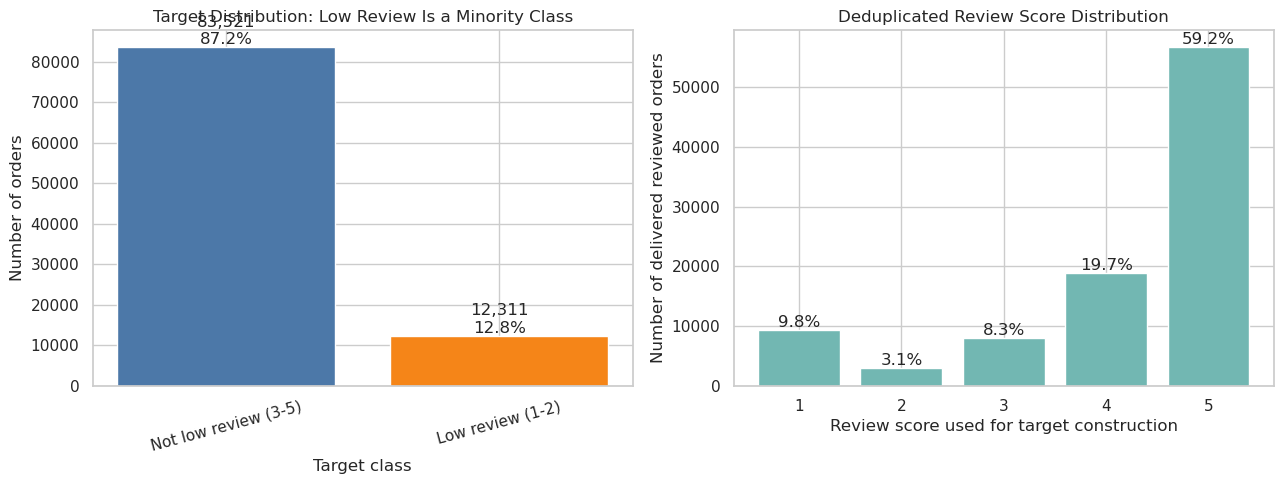

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

class_counts = (
    eda_df["review_outcome"]
    .value_counts()
    .reindex(["Not low review (3-5)", "Low review (1-2)"])
)
class_rates = class_counts / class_counts.sum()
axes[0].bar(class_counts.index, class_counts.values, color=[TARGET_PALETTE[label] for label in class_counts.index])
axes[0].set_title("Target Distribution: Low Review Is a Minority Class")
axes[0].set_xlabel("Target class")
axes[0].set_ylabel("Number of orders")
axes[0].tick_params(axis="x", rotation=15)
for idx, (count, rate) in enumerate(zip(class_counts.values, class_rates.values)):
    axes[0].text(idx, count, f"{count:,}\n{rate:.1%}", ha="center", va="bottom")

review_score_counts = orders_base["review_score"].value_counts().sort_index()
review_score_rates = review_score_counts / review_score_counts.sum()
axes[1].bar(review_score_counts.index.astype(str), review_score_counts.values, color="#72B7B2")
axes[1].set_title("Deduplicated Review Score Distribution")
axes[1].set_xlabel("Review score used for target construction")
axes[1].set_ylabel("Number of delivered reviewed orders")
for idx, (count, rate) in enumerate(zip(review_score_counts.values, review_score_rates.values)):
    axes[1].text(idx, count, f"{rate:.1%}", ha="center", va="bottom")

path = save_figure(fig, "phase5_target_and_review_distribution.png")
eda_plot_registry.append({"figure": "Target and review score distribution", "path": str(path)})
plt.show()

**Interpretation.** Low reviews are a moderate minority class: 12,311 of 95,832 delivered reviewed orders, or 12.85%, are `low_review = 1`. This confirms that accuracy alone will be misleading later because a model can look strong by mostly predicting the majority class.

The underlying review distribution is highly right-skewed: score 5 accounts for about 59.2% of the modeling population, while scores 1 and 2 together define the 12.85% low-review class. This makes the project a customer-experience risk detection problem rather than a balanced generic classification task.

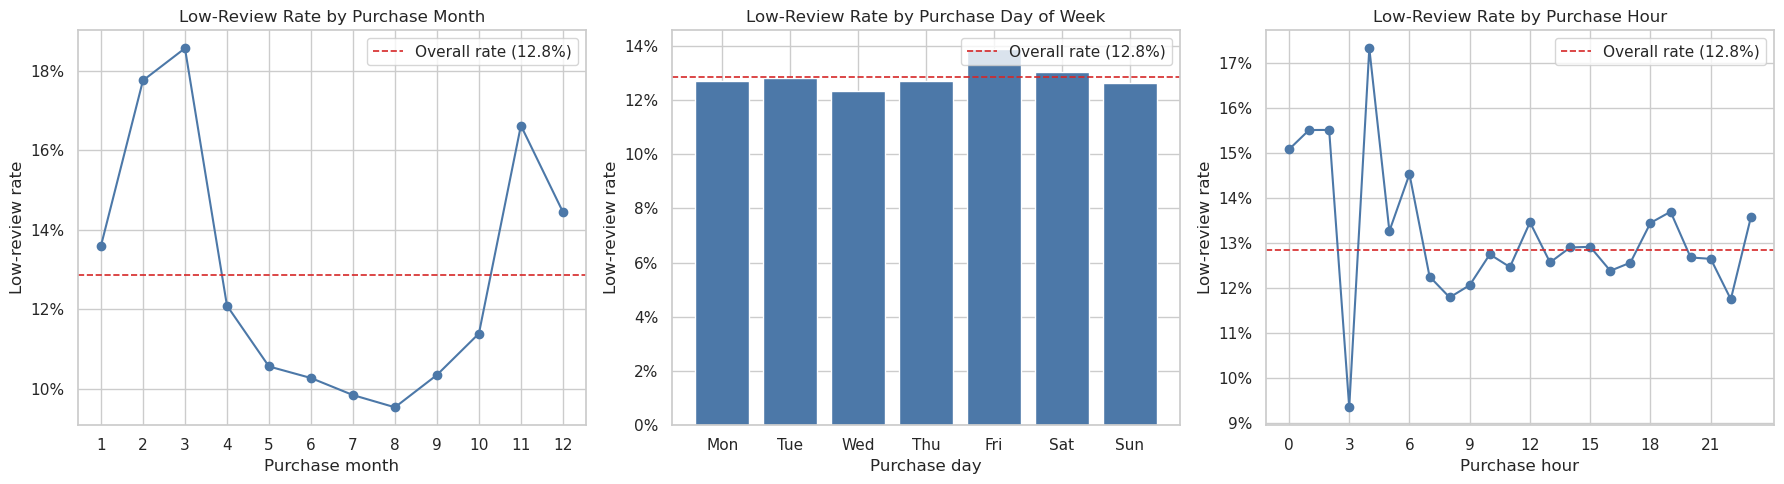

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

month_rate = low_review_rate_by("purchase_month").sort_values("purchase_month")
axes[0].plot(month_rate["purchase_month"], month_rate["low_review_rate"], marker="o", color=RATE_COLOR)
add_rate_baseline(axes[0])
format_percent_axis(axes[0])
axes[0].set_title("Low-Review Rate by Purchase Month")
axes[0].set_xlabel("Purchase month")
axes[0].set_ylabel("Low-review rate")
axes[0].set_xticks(range(1, 13))
axes[0].legend(loc="upper right")

weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_rate = low_review_rate_by("purchase_dayofweek").sort_values("purchase_dayofweek")
axes[1].bar(weekday_labels, dow_rate["low_review_rate"], color=RATE_COLOR)
add_rate_baseline(axes[1])
format_percent_axis(axes[1])
axes[1].set_title("Low-Review Rate by Purchase Day of Week")
axes[1].set_xlabel("Purchase day")
axes[1].set_ylabel("Low-review rate")
axes[1].legend(loc="upper right")

hour_rate = low_review_rate_by("purchase_hour").sort_values("purchase_hour")
axes[2].plot(hour_rate["purchase_hour"], hour_rate["low_review_rate"], marker="o", color=RATE_COLOR)
add_rate_baseline(axes[2])
format_percent_axis(axes[2])
axes[2].set_title("Low-Review Rate by Purchase Hour")
axes[2].set_xlabel("Purchase hour")
axes[2].set_ylabel("Low-review rate")
axes[2].set_xticks(range(0, 24, 3))
axes[2].legend(loc="upper right")

path = save_figure(fig, "phase5_timing_risk_patterns.png")
eda_plot_registry.append({"figure": "Timing risk patterns", "path": str(path)})
plt.show()

**Interpretation.** Purchase month shows meaningful variation: March (18.6%) and February (17.8%) have much higher low-review rates than the overall 12.85% baseline, while June-August sit closer to 9.5-10.3%. Time period appears to capture operational or seasonal risk not explained by the target alone.

Day-of-week effects are smaller. Friday is the highest day at about 13.9%, while Wednesday is lowest at about 12.3%, so day of week may add modest signal but is unlikely to dominate.

Purchase hour is noisier, especially in low-volume overnight hours. Late-night and very early morning hours such as 0-2 and 4 show above-baseline risk, but because some of those hour buckets are small, hour should be treated as a weak timing signal rather than a standalone business finding.

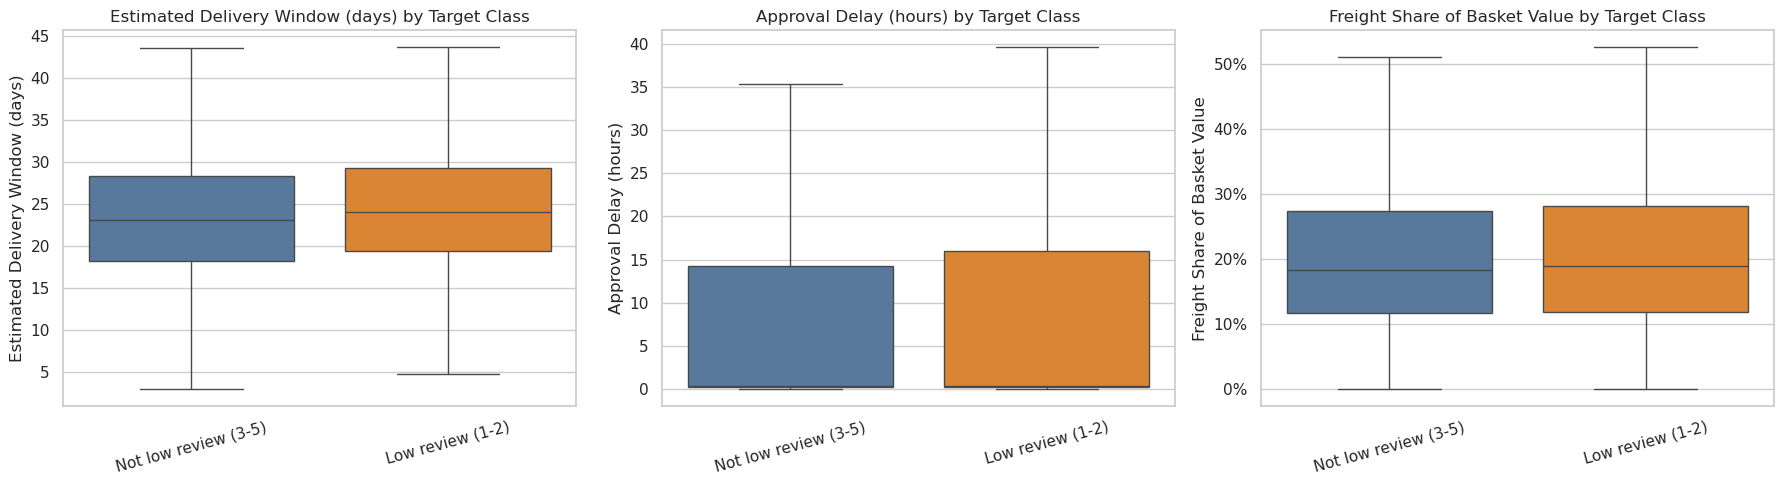

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

friction_features = [
    ("estimated_delivery_days", "Estimated Delivery Window (days)"),
    ("approval_delay_hours", "Approval Delay (hours)"),
    ("freight_share", "Freight Share of Basket Value"),
]

for ax, (column, label) in zip(axes, friction_features):
    sns.boxplot(
        data=eda_df,
        x="review_outcome",
        y=column,
        hue="review_outcome",
        palette=TARGET_PALETTE,
        showfliers=False,
        ax=ax,
        legend=False,
    )
    ax.set_title(f"{label} by Target Class")
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=15)
    if column == "freight_share":
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

path = save_figure(fig, "phase5_delivery_friction_by_target.png")
eda_plot_registry.append({"figure": "Delivery expectation and friction proxies", "path": str(path)})
plt.show()

**Interpretation.** Low-review orders have longer estimated delivery windows: median estimated delivery is about 24.0 days for low reviews versus 23.2 days for non-low reviews. This is a leakage-safe signal because it uses the promised/estimated delivery horizon, not actual delivery performance.

Approval delay differs only slightly in median terms, but the mean is higher for low-review orders, suggesting a right-tail of delayed approvals that may add weak signal. Freight burden is also slightly higher for low-review orders (median freight share around 18.9% versus 18.3%), which supports keeping freight-share features even if the difference is not as dramatic as basket-complexity effects.

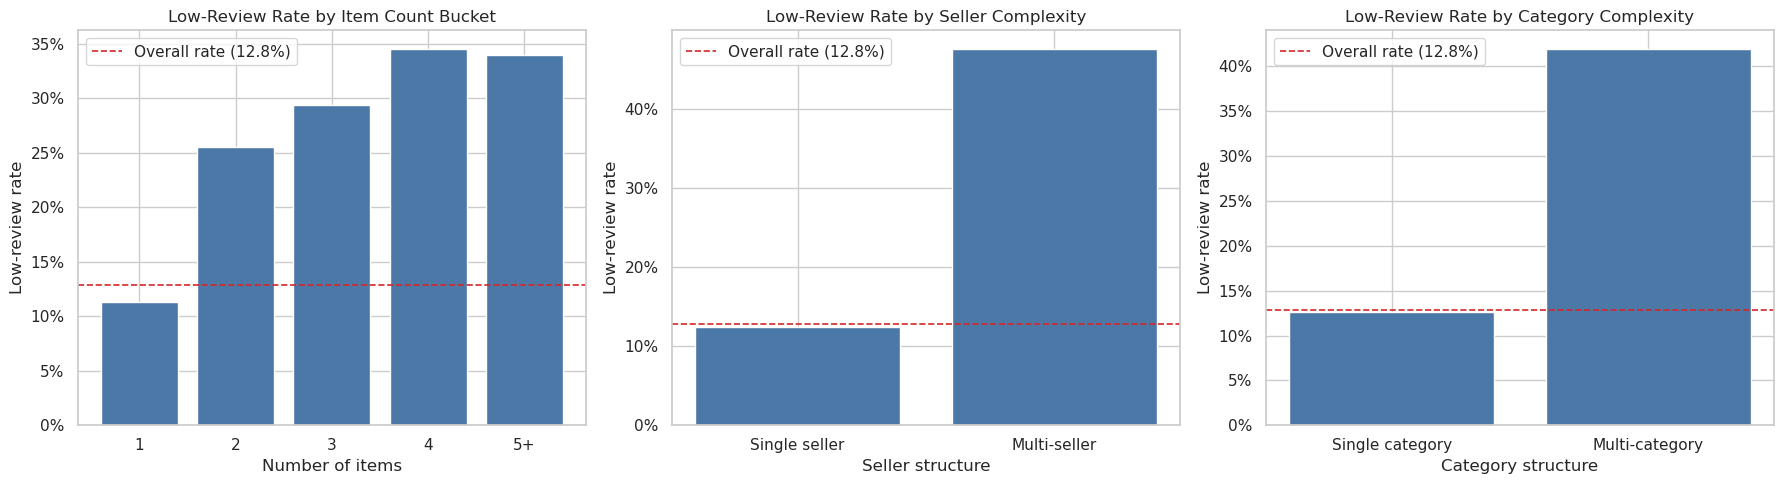

In [29]:
plot_df = eda_df.copy()
plot_df["item_count_bucket"] = pd.cut(
    plot_df["n_items"],
    bins=[0, 1, 2, 3, 4, np.inf],
    labels=["1", "2", "3", "4", "5+"],
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

item_rate = low_review_rate_by("item_count_bucket", plot_df).sort_values("item_count_bucket")
axes[0].bar(item_rate["item_count_bucket"].astype(str), item_rate["low_review_rate"], color=RATE_COLOR)
add_rate_baseline(axes[0])
format_percent_axis(axes[0])
axes[0].set_title("Low-Review Rate by Item Count Bucket")
axes[0].set_xlabel("Number of items")
axes[0].set_ylabel("Low-review rate")
axes[0].legend(loc="upper left")

seller_rate = low_review_rate_by("multi_seller_flag", plot_df).sort_values("multi_seller_flag")
axes[1].bar(["Single seller", "Multi-seller"], seller_rate["low_review_rate"], color=RATE_COLOR)
add_rate_baseline(axes[1])
format_percent_axis(axes[1])
axes[1].set_title("Low-Review Rate by Seller Complexity")
axes[1].set_xlabel("Seller structure")
axes[1].set_ylabel("Low-review rate")
axes[1].legend(loc="upper left")

category_rate = low_review_rate_by("multi_category_flag", plot_df).sort_values("multi_category_flag")
axes[2].bar(["Single category", "Multi-category"], category_rate["low_review_rate"], color=RATE_COLOR)
add_rate_baseline(axes[2])
format_percent_axis(axes[2])
axes[2].set_title("Low-Review Rate by Category Complexity")
axes[2].set_xlabel("Category structure")
axes[2].set_ylabel("Low-review rate")
axes[2].legend(loc="upper left")

path = save_figure(fig, "phase5_basket_complexity_risk.png")
eda_plot_registry.append({"figure": "Basket complexity risk", "path": str(path)})
plt.show()

**Interpretation.** Basket complexity is one of the clearest EDA patterns. Single-item orders have an 11.3% low-review rate, while two-item orders rise to 25.5%, three-item orders to 29.4%, and four-item orders to 34.5%.

Multi-seller orders are especially risky: their low-review rate is about 47.6%, compared with 12.4% for single-seller orders. Multi-category orders show a similar risk jump, around 41.9% versus 12.6%, which points to fulfillment complexity as one of the strongest risk-associated patterns in the data.

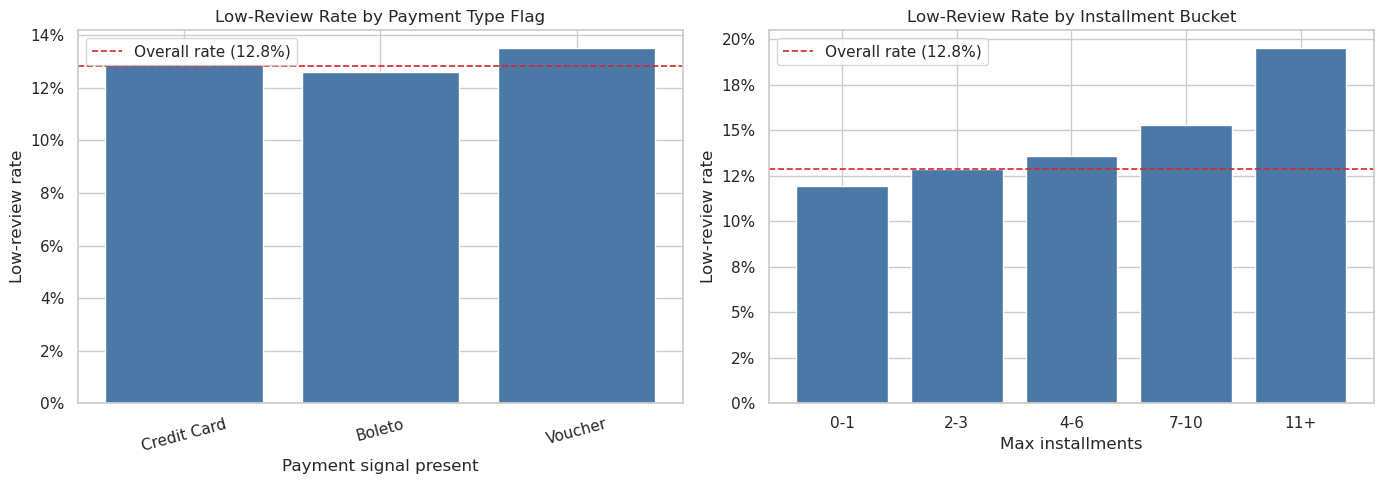

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

payment_flags = ["has_credit_card", "has_boleto", "has_voucher"]
payment_flag_rates = []
for flag in payment_flags:
    subset = eda_df.loc[eda_df[flag] == 1]
    payment_flag_rates.append(
        {
            "payment_signal": flag.replace("has_", "").replace("_", " ").title(),
            "n_orders": len(subset),
            "low_review_rate": subset["low_review"].mean(),
        }
    )
payment_flag_rates = pd.DataFrame(payment_flag_rates)
axes[0].bar(payment_flag_rates["payment_signal"], payment_flag_rates["low_review_rate"], color=RATE_COLOR)
add_rate_baseline(axes[0])
format_percent_axis(axes[0])
axes[0].set_title("Low-Review Rate by Payment Type Flag")
axes[0].set_xlabel("Payment signal present")
axes[0].set_ylabel("Low-review rate")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(loc="upper left")

plot_df["installment_bucket"] = pd.cut(
    plot_df["max_payment_installments"],
    bins=[-1, 1, 3, 6, 10, np.inf],
    labels=["0-1", "2-3", "4-6", "7-10", "11+"],
)
installment_rate = (
    low_review_rate_by("installment_bucket", plot_df)
    .dropna(subset=["installment_bucket"])
    .sort_values("installment_bucket")
)
installment_labels = [str(label) for label in installment_rate["installment_bucket"]]
axes[1].bar(installment_labels, installment_rate["low_review_rate"], color=RATE_COLOR)
add_rate_baseline(axes[1])
format_percent_axis(axes[1])
axes[1].set_title("Low-Review Rate by Installment Bucket")
axes[1].set_xlabel("Max installments")
axes[1].set_ylabel("Low-review rate")
axes[1].legend(loc="upper left")

path = save_figure(fig, "phase5_payment_behavior_risk.png")
eda_plot_registry.append({"figure": "Payment behavior risk", "path": str(path)})
plt.show()

**Interpretation.** Payment type alone is not a dramatic separator: credit-card, boleto, and voucher orders all sit close to the overall low-review rate. Payment method flags may add incremental signal, but they are unlikely to dominate the model.

Installment behavior is more informative. Orders with 0-1 installments have about an 11.95% low-review rate, while 7-10 installments rise to about 15.3% and 11+ installments approach 19.5%. Higher installment counts may proxy for larger or more financially involved orders, so installment features are worth retaining.

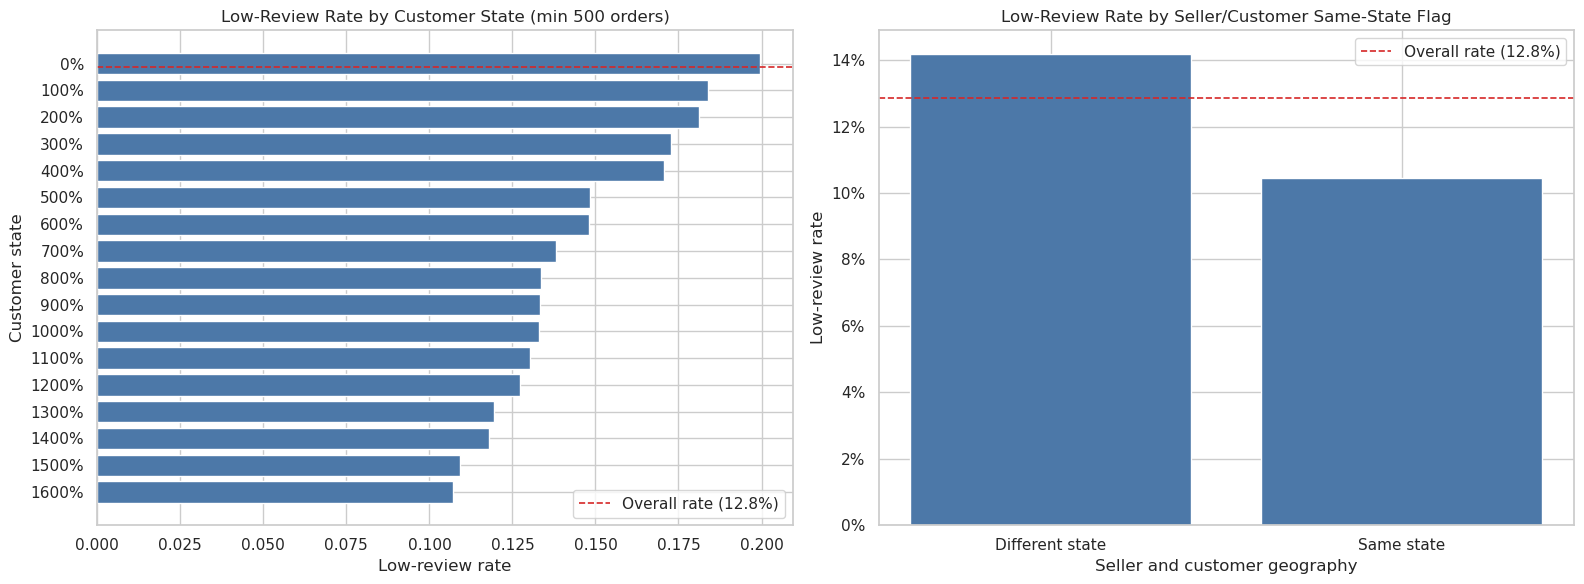

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

state_rate = low_review_rate_by("customer_state", min_count=500).sort_values("low_review_rate", ascending=False)
axes[0].barh(state_rate["customer_state"], state_rate["low_review_rate"], color=RATE_COLOR)
add_rate_baseline(axes[0])
format_percent_axis(axes[0])
axes[0].invert_yaxis()
axes[0].set_title("Low-Review Rate by Customer State (min 500 orders)")
axes[0].set_xlabel("Low-review rate")
axes[0].set_ylabel("Customer state")
axes[0].legend(loc="lower right")

same_state_rate = low_review_rate_by("same_state_flag").sort_values("same_state_flag")
axes[1].bar(["Different state", "Same state"], same_state_rate["low_review_rate"], color=RATE_COLOR)
add_rate_baseline(axes[1])
format_percent_axis(axes[1])
axes[1].set_title("Low-Review Rate by Seller/Customer Same-State Flag")
axes[1].set_xlabel("Seller and customer geography")
axes[1].set_ylabel("Low-review rate")
axes[1].legend(loc="upper right")

path = save_figure(fig, "phase5_geography_risk.png")
eda_plot_registry.append({"figure": "Geography risk patterns", "path": str(path)})
plt.show()

**Interpretation.** Geography shows systematic differences. Among states with at least 500 orders, MA (~19.9%), RJ (~18.4%), PA (~18.1%), CE (~17.3%), and BA (~17.1%) are above the global baseline, while SP (~10.7%), PR (~10.9%), MG (~11.8%), and RS (~12.0%) are lower-risk.

The same-state flag is also meaningful: orders where the primary seller and customer are in the same state have about a 10.5% low-review rate versus 14.2% for different-state orders. This supports the idea that geography is partly capturing logistics friction.

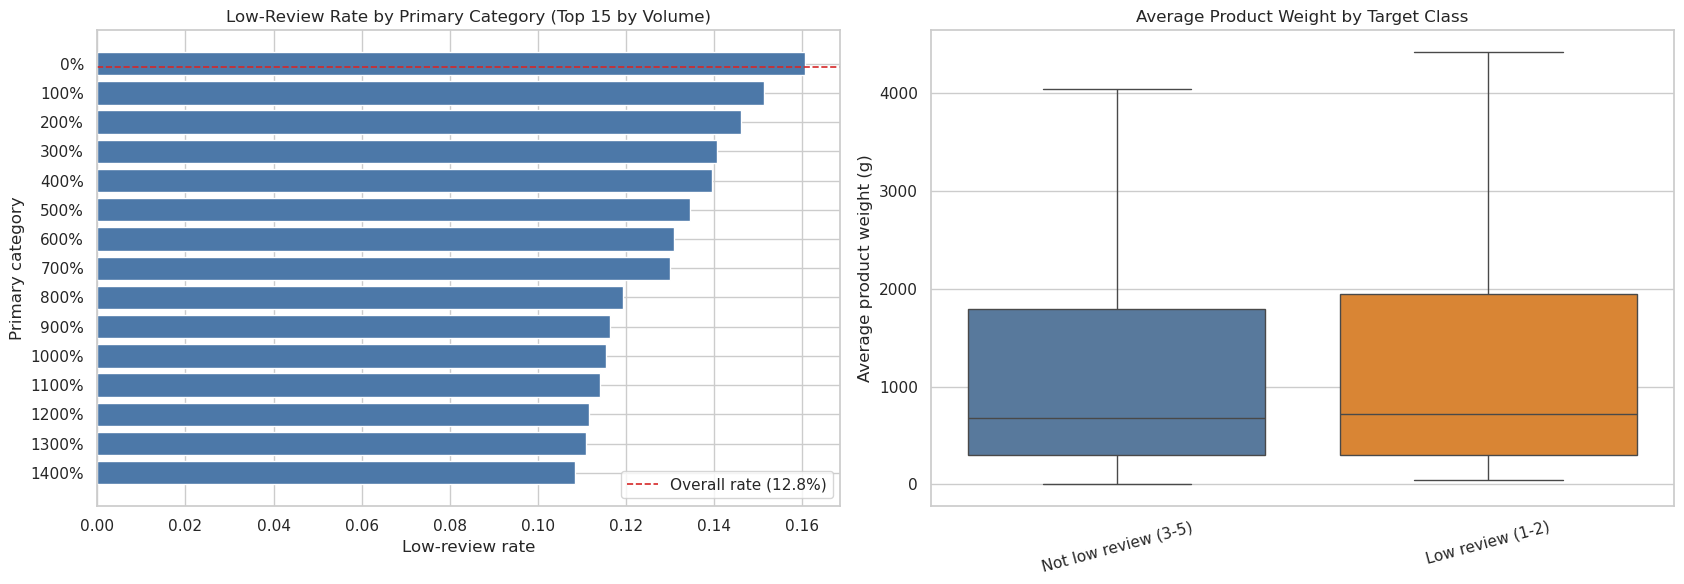

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

top_categories = eda_df["primary_category"].value_counts(dropna=False).head(15).index
category_rate = (
    eda_df.loc[eda_df["primary_category"].isin(top_categories)]
    .groupby("primary_category", dropna=False)["low_review"]
    .agg(n_orders="count", low_review_rate="mean")
    .reset_index()
    .sort_values("low_review_rate", ascending=False)
)
category_labels = category_rate["primary_category"].fillna("missing")
axes[0].barh(category_labels, category_rate["low_review_rate"], color=RATE_COLOR)
add_rate_baseline(axes[0])
format_percent_axis(axes[0])
axes[0].invert_yaxis()
axes[0].set_title("Low-Review Rate by Primary Category (Top 15 by Volume)")
axes[0].set_xlabel("Low-review rate")
axes[0].set_ylabel("Primary category")
axes[0].legend(loc="lower right")

sns.boxplot(
    data=eda_df,
    x="review_outcome",
    y="avg_product_weight_g",
    hue="review_outcome",
    palette=TARGET_PALETTE,
    showfliers=False,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Average Product Weight by Target Class")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average product weight (g)")
axes[1].tick_params(axis="x", rotation=15)

path = save_figure(fig, "phase5_product_category_signals.png")
eda_plot_registry.append({"figure": "Product and category signals", "path": str(path)})
plt.show()

**Interpretation.** Product category risk varies substantially among common categories. Office furniture is highest among high-volume categories at about 21.8%, followed by missing category values (~16.2%), bed/bath/table (~16.1%), furniture/decor (~15.1%), and computers/accessories (~14.6%).

Heavier products also lean riskier: low-review orders have a higher average product weight mean (~2,343 g versus ~2,059 g) and a slightly higher median weight. This supports keeping product weight and volume as safe product-complexity predictors.

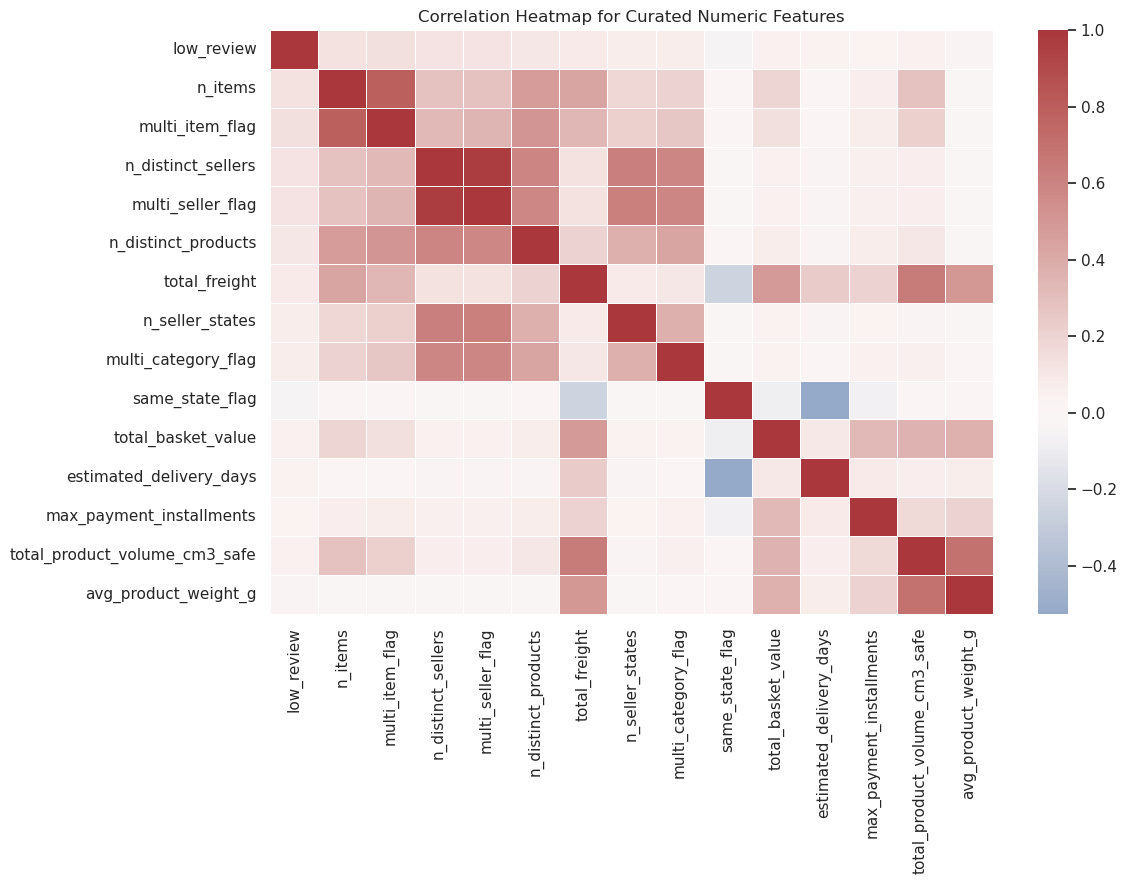

In [33]:
corr_features = [
    "low_review",
    "n_items",
    "multi_item_flag",
    "n_distinct_sellers",
    "multi_seller_flag",
    "n_distinct_products",
    "total_freight",
    "n_seller_states",
    "multi_category_flag",
    "same_state_flag",
    "total_basket_value",
    "estimated_delivery_days",
    "max_payment_installments",
    "total_product_volume_cm3_safe",
    "avg_product_weight_g",
]

corr_matrix = eda_df[corr_features].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    cmap="vlag",
    center=0,
    linewidths=0.5,
    annot=False,
    ax=ax,
)
ax.set_title("Correlation Heatmap for Curated Numeric Features")
path = save_figure(fig, "phase5_numeric_correlation_heatmap.png")
eda_plot_registry.append({"figure": "Numeric correlation heatmap", "path": str(path)})
plt.show()

**Interpretation.** The strongest univariate numeric associations with `low_review` are still modest, with basket-complexity features leading: `multi_item_flag`, `n_items`, `n_distinct_sellers`, `multi_seller_flag`, and `n_distinct_products`. This is a healthy sign for leakage: no single numeric feature behaves like a target proxy.

The heatmap also shows expected redundancy clusters, such as item/product/seller-count features and basket/payment-value features. This supports using regularized linear models and tree-based models later rather than relying on a single hand-picked predictor.

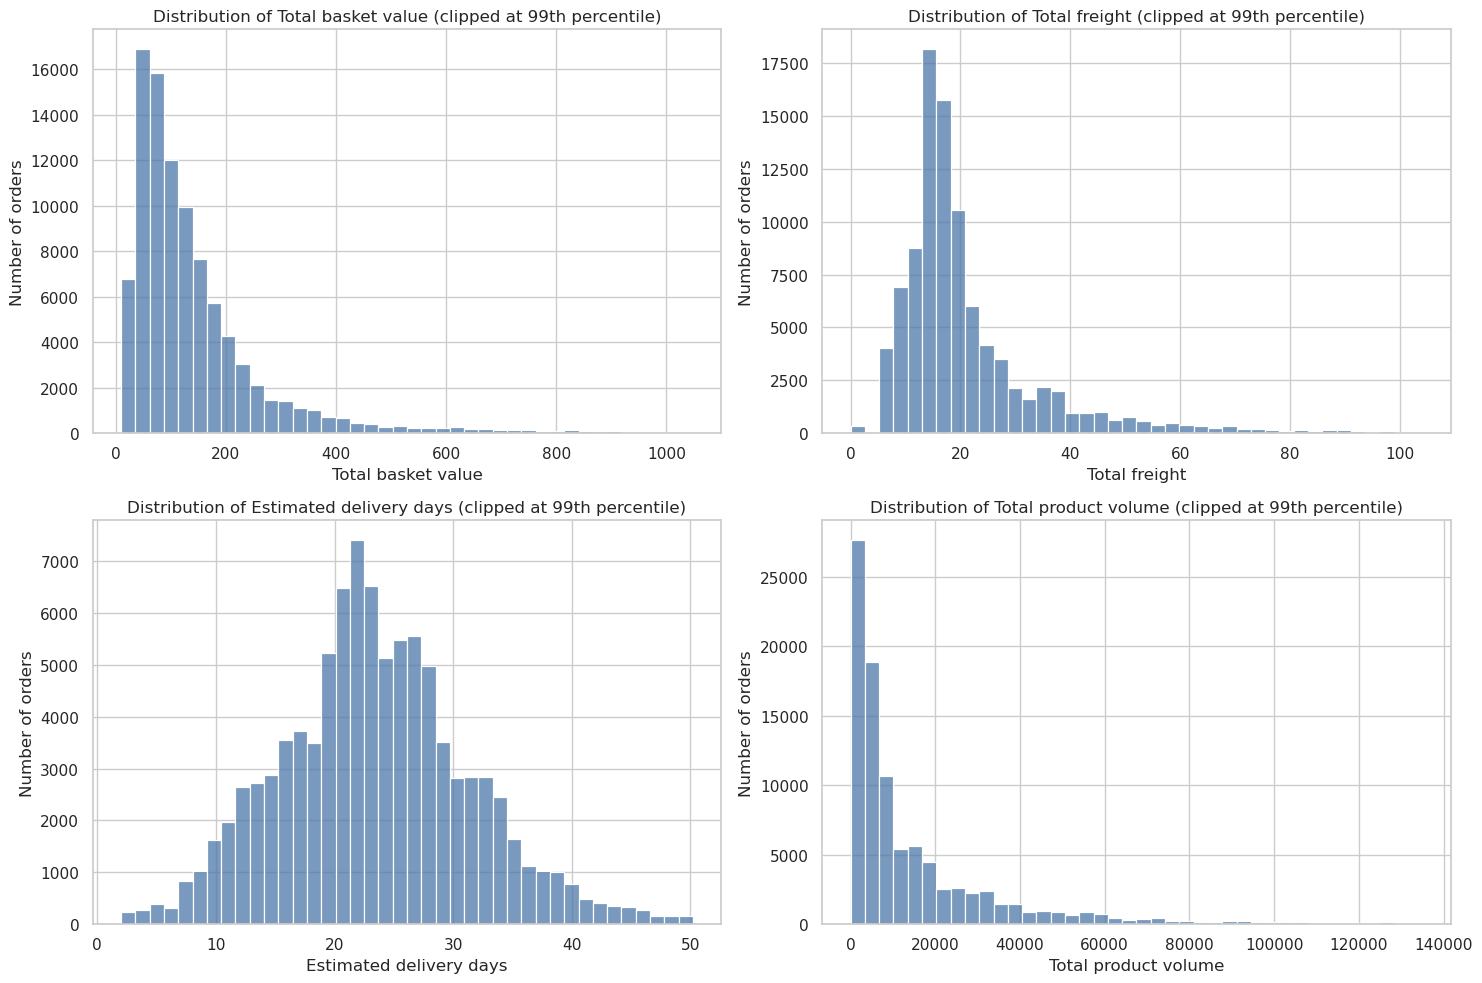

In [34]:
skew_features = [
    ("total_basket_value", "Total basket value"),
    ("total_freight", "Total freight"),
    ("estimated_delivery_days", "Estimated delivery days"),
    ("total_product_volume_cm3_safe", "Total product volume"),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, (column, label) in zip(axes.ravel(), skew_features):
    upper = eda_df[column].quantile(0.99)
    sns.histplot(eda_df.loc[eda_df[column] <= upper, column], bins=40, color=RATE_COLOR, ax=ax)
    ax.set_title(f"Distribution of {label} (clipped at 99th percentile)")
    ax.set_xlabel(label)
    ax.set_ylabel("Number of orders")

path = save_figure(fig, "phase5_numeric_skew_outlier_inspection.png")
eda_plot_registry.append({"figure": "Numeric skew and outlier inspection", "path": str(path)})
plt.show()

**Interpretation.** Major numeric predictors are strongly right-skewed. For example, median basket value is about 105, the 95th percentile is about 445, and the maximum exceeds 13,000; product volume and product weight show similar long tails.

This matters for preprocessing and modeling. Tree-based models can handle skewed numeric distributions reasonably well, but Logistic Regression may benefit from scaling and possibly log transformations or robust handling of extreme values.

### Exploratory Analysis Synthesis

The strongest EDA patterns point toward operational complexity rather than a single obvious predictor. Multi-item, multi-seller, and multi-category orders have much higher low-review risk than simpler orders, making fulfillment coordination and basket complexity central to the customer-experience risk problem.

Geography also matters. Some customer states sit consistently above the global baseline, and same-state seller/customer orders have visibly lower risk than cross-state orders, supporting the inclusion of geography features.

Timing and friction proxies contribute additional signal. Longer estimated delivery windows, higher freight burden, higher basket value, heavier products, and higher installment counts all show elevated low-review risk, though these differences are less dramatic than the basket-complexity effects.

For modeling, the practical implications are clear: use metrics that handle class imbalance, preserve categorical geography/category features with appropriate encoding, and use preprocessing that can handle skewed numeric variables and missing product metadata.

In [35]:
eda_validation = pd.DataFrame(
    [
        {
            "validation_check": "target distribution plot produced",
            "status": "pass" if any("Target" in item["figure"] for item in eda_plot_registry) else "fail",
            "details": "Target distribution and review score context plotted.",
        },
        {
            "validation_check": "timing plots produced",
            "status": "pass" if any("Timing" in item["figure"] for item in eda_plot_registry) else "fail",
            "details": "Purchase month, day of week, and hour patterns plotted.",
        },
        {
            "validation_check": "feature-family plots produced",
            "status": "pass" if len(eda_plot_registry) >= 8 else "review",
            "details": f"{len(eda_plot_registry)} major EDA figures produced.",
        },
        {
            "validation_check": "major figures saved",
            "status": "pass" if all(Path(item["path"]).exists() for item in eda_plot_registry) else "review",
            "details": "; ".join(Path(item["path"]).name for item in eda_plot_registry),
        },
        {
            "validation_check": "EDA uses leakage-safe primary features except target-context review score",
            "status": "pass",
            "details": "Plots use primary_model_df; review_score appears only in the target-context distribution.",
        },
    ]
)

eda_plot_summary = pd.DataFrame(eda_plot_registry)

display(eda_plot_summary)
display(eda_validation)

,figure,path
0,Target and review score distribution,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
1,Timing risk patterns,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
2,Delivery expectation and friction proxies,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
3,Basket complexity risk,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
4,Payment behavior risk,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
5,Geography risk patterns,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
6,Product and category signals,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
7,Numeric correlation heatmap,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
8,Numeric skew and outlier inspection,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...


,validation_check,status,details
0,target distribution plot produced,pass,Target distribution and review score context p...
1,timing plots produced,pass,"Purchase month, day of week, and hour patterns..."
2,feature-family plots produced,pass,9 major EDA figures produced.
3,major figures saved,pass,phase5_target_and_review_distribution.png; pha...
4,EDA uses leakage-safe primary features except ...,pass,Plots use primary_model_df; review_score appea...


## 6. Preprocessing

### Preprocessing Strategy

The leakage-safe feature set is prepared for modeling using `X_primary`, `y`, and the numeric/categorical feature lists created during feature engineering. The train/test split is performed before any preprocessing transformer is fit.

Stratification matters because `low_review` is imbalanced: poor reviews are a minority class. A random split without stratification could give the training and test sets noticeably different risk rates, making evaluation less stable and less representative of the original population.

Sklearn pipelines are part of the leakage control strategy. Imputers, encoders, and scalers learn information from data, so they must be fit on the training set only. Keeping these steps inside reusable sklearn transformers makes later model pipelines reproducible and prevents accidental fitting on the full dataset.

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

required_phase_4_objects = [
    "X_primary",
    "y",
    "numeric_feature_columns",
    "categorical_feature_columns",
]
missing_phase_4_objects = [name for name in required_phase_4_objects if name not in globals()]
if missing_phase_4_objects:
    raise NameError(
        "Run Phase 4 before Phase 6. Missing required objects: "
        f"{missing_phase_4_objects}"
    )

# Start from the audited primary feature set and re-check the leakage boundary
# so later modeling cells can depend on X without repeating the audit.
X = X_primary.copy()
y = y.copy()

forbidden_preprocessing_columns = [
    "review_score",
    "review_comment_title",
    "review_comment_message",
    "review_creation_date",
    "review_answer_timestamp",
    "order_delivered_customer_date",
    "order_delivered_carrier_date",
    "actual_lateness",
    "delivery_lateness",
]
raw_identifier_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "product_id",
    "seller_id",
    "review_id",
]
columns_excluded_in_phase_6 = sorted(
    set(X.columns).intersection(forbidden_preprocessing_columns + raw_identifier_columns)
)
if columns_excluded_in_phase_6:
    X = X.drop(columns=columns_excluded_in_phase_6)

numeric_columns_by_dtype = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_columns_by_dtype = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

numeric_features_used = [
    col for col in numeric_feature_columns
    if col in X.columns and col in numeric_columns_by_dtype
]
categorical_features_used = [
    col for col in categorical_feature_columns
    if col in X.columns and col in categorical_columns_by_dtype
]

# Keep the preprocessing lists synchronized with the actual dtypes used in X.
numeric_features_used.extend(
    col for col in numeric_columns_by_dtype if col not in numeric_features_used
)
categorical_features_used.extend(
    col for col in categorical_columns_by_dtype if col not in categorical_features_used
)

features_without_transformer = sorted(
    set(X.columns) - set(numeric_features_used) - set(categorical_features_used)
)
if features_without_transformer:
    raise ValueError(
        "Every feature must be assigned to exactly one preprocessing branch. "
        f"Unassigned features: {features_without_transformer}"
    )

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_shape_summary = pd.DataFrame(
    [
        {"dataset": "X", "rows": X.shape[0], "columns": X.shape[1]},
        {"dataset": "X_train", "rows": X_train.shape[0], "columns": X_train.shape[1]},
        {"dataset": "X_test", "rows": X_test.shape[0], "columns": X_test.shape[1]},
    ]
)

class_balance_summary = pd.concat(
    {
        "overall": y.value_counts(normalize=True).sort_index(),
        "train": y_train.value_counts(normalize=True).sort_index(),
        "test": y_test.value_counts(normalize=True).sort_index(),
    },
    axis=1,
).rename_axis("low_review")
class_balance_summary = (class_balance_summary * 100).round(2)

class_count_summary = pd.concat(
    {
        "overall": y.value_counts().sort_index(),
        "train": y_train.value_counts().sort_index(),
        "test": y_test.value_counts().sort_index(),
    },
    axis=1,
).rename_axis("low_review")

feature_type_summary = pd.DataFrame(
    [
        {"feature_type": "numeric", "count": len(numeric_features_used)},
        {"feature_type": "categorical", "count": len(categorical_features_used)},
        {"feature_type": "excluded in Phase 6", "count": len(columns_excluded_in_phase_6)},
    ]
)

print("Train/test shapes:")
display(split_shape_summary)
print("Class balance (%):")
display(class_balance_summary)
print("Class counts:")
display(class_count_summary)
print("Feature type counts:")
display(feature_type_summary)
print("Numeric features used:")
print(numeric_features_used)
print("Categorical features used:")
print(categorical_features_used)
print("Columns excluded in Phase 6:")
print(columns_excluded_in_phase_6)

Train/test shapes:


,dataset,rows,columns
0,X,95832,54
1,X_train,76665,54
2,X_test,19167,54


Class balance (%):


,overall,train,test
low_review,,,
0,87.15,87.15,87.16
1,12.85,12.85,12.84


Class counts:


,overall,train,test
low_review,,,
0,83521,66816,16705
1,12311,9849,2462


Feature type counts:


,feature_type,count
0,numeric,51
1,categorical,3
2,excluded in Phase 6,0


Numeric features used:
['purchase_year', 'purchase_month', 'purchase_day', 'purchase_dayofweek', 'purchase_hour', 'weekend_purchase_flag', 'approval_delay_hours', 'approval_delay_days', 'estimated_delivery_days', 'n_items', 'total_price', 'max_price', 'total_freight', 'avg_freight', 'n_distinct_products', 'n_distinct_sellers', 'total_basket_value', 'freight_share', 'avg_item_price', 'expensive_order_flag', 'multi_seller_flag', 'multi_item_flag', 'multi_product_flag', 'n_payment_methods', 'max_payment_installments', 'total_payment_installments', 'total_payment_value', 'has_credit_card', 'has_boleto', 'has_voucher', 'has_debit_card', 'payment_value_diff', 'payment_count', 'multiple_payment_methods_flag', 'installment_purchase_flag', 'high_installment_flag', 'customer_city_freq', 'n_seller_states', 'same_state_flag', 'multi_seller_state_flag', 'n_categories', 'avg_product_weight_g', 'max_product_weight_g', 'avg_product_photos_qty', 'avg_product_name_length', 'avg_product_description_lengt

### Reusable Preprocessing Pipeline

The preprocessing object below is model-agnostic. Each classifier can wrap it as `Pipeline([("preprocessor", preprocessor), ("classifier", model)])`, ensuring that every model receives the same train-only imputation, categorical encoding, and numeric scaling behavior.

Numeric features use median imputation because many monetary, freight, and product-size variables are right-skewed. Categorical features use a constant `missing` category and one-hot encoding with `handle_unknown="ignore"`, so categories that appear only in the test set or future data do not break prediction. Outliers are retained because extreme basket, freight, or product-size values may carry customer-experience signal.

In [37]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    # Older sklearn versions use sparse=False instead of sparse_output=False.
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", one_hot_encoder),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_used),
        ("cat", categorical_transformer, categorical_features_used),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

preprocessing_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
    ]
)

# Validation fit is train-only. The test set is transformed, never fit.
X_train_preprocessed = preprocessing_pipeline.fit_transform(X_train)
X_test_preprocessed = preprocessing_pipeline.transform(X_test)

try:
    preprocessed_feature_names = preprocessing_pipeline.named_steps[
        "preprocessor"
    ].get_feature_names_out()
except AttributeError:
    preprocessed_feature_names = None

preprocessing_output_summary = pd.DataFrame(
    [
        {
            "dataset": "X_train_preprocessed",
            "rows": X_train_preprocessed.shape[0],
            "columns": X_train_preprocessed.shape[1],
        },
        {
            "dataset": "X_test_preprocessed",
            "rows": X_test_preprocessed.shape[0],
            "columns": X_test_preprocessed.shape[1],
        },
    ]
)

preprocessing_assumptions = pd.DataFrame(
    [
        {
            "topic": "numeric missing values",
            "assumption_or_note": "Median imputation is robust to the right-skewed monetary, freight, and product-size features seen in EDA.",
        },
        {
            "topic": "categorical missing values",
            "assumption_or_note": "Missing categories are represented explicitly as 'missing' before one-hot encoding.",
        },
        {
            "topic": "unknown future categories",
            "assumption_or_note": "OneHotEncoder(handle_unknown='ignore') keeps test or future-only categories from causing transform errors.",
        },
        {
            "topic": "scaling",
            "assumption_or_note": "StandardScaler supports the Phase 7 logistic-regression baseline; tree models can use the same pipeline for consistency.",
        },
        {
            "topic": "outliers and skew",
            "assumption_or_note": "Outliers are retained. A log transform or winsorization could be considered later if logistic-regression diagnostics warrant it.",
        },
    ]
)

print("Preprocessed matrix shapes:")
display(preprocessing_output_summary)
print("Preprocessing assumptions and notes:")
display(preprocessing_assumptions)
print("Number of preprocessed features:")
print(X_train_preprocessed.shape[1])

Preprocessed matrix shapes:


,dataset,rows,columns
0,X_train_preprocessed,76665,172
1,X_test_preprocessed,19167,172


Preprocessing assumptions and notes:


,topic,assumption_or_note
0,numeric missing values,Median imputation is robust to the right-skewe...
1,categorical missing values,Missing categories are represented explicitly ...
2,unknown future categories,OneHotEncoder(handle_unknown='ignore') keeps t...
3,scaling,StandardScaler supports the Phase 7 logistic-r...
4,outliers and skew,Outliers are retained. A log transform or wins...


Number of preprocessed features:
172


In [38]:
overall_low_review_rate = y.mean()
train_low_review_rate = y_train.mean()
test_low_review_rate = y_test.mean()
max_split_rate_difference = max(
    abs(train_low_review_rate - overall_low_review_rate),
    abs(test_low_review_rate - overall_low_review_rate),
)

phase_6_validation = pd.DataFrame(
    [
        {
            "validation_check": "X and y row counts align",
            "status": "pass" if len(X) == len(y) else "fail",
            "details": f"X rows: {len(X):,}; y rows: {len(y):,}",
        },
        {
            "validation_check": "stratified split preserves class balance",
            "status": "pass" if max_split_rate_difference < 0.001 else "review",
            "details": (
                f"overall: {overall_low_review_rate:.4f}; "
                f"train: {train_low_review_rate:.4f}; "
                f"test: {test_low_review_rate:.4f}"
            ),
        },
        {
            "validation_check": "no forbidden leakage columns in X",
            "status": "pass" if not set(X.columns).intersection(forbidden_preprocessing_columns) else "fail",
            "details": sorted(set(X.columns).intersection(forbidden_preprocessing_columns)),
        },
        {
            "validation_check": "no raw identifier columns in X",
            "status": "pass" if not set(X.columns).intersection(raw_identifier_columns) else "fail",
            "details": sorted(set(X.columns).intersection(raw_identifier_columns)),
        },
        {
            "validation_check": "all X columns assigned to preprocessing",
            "status": "pass" if not features_without_transformer else "fail",
            "details": f"unassigned features: {features_without_transformer}",
        },
        {
            "validation_check": "preprocessor fit only on training data",
            "status": "pass",
            "details": "train_test_split is run before preprocessing_pipeline.fit_transform(X_train); X_test uses transform only.",
        },
        {
            "validation_check": "pipeline transforms train and test without error",
            "status": "pass" if X_train_preprocessed.shape[0] == len(X_train) and X_test_preprocessed.shape[0] == len(X_test) else "fail",
            "details": f"train matrix: {X_train_preprocessed.shape}; test matrix: {X_test_preprocessed.shape}",
        },
    ]
)

phase_6_created_objects = pd.DataFrame(
    [
        {"object": "X", "purpose": "Final Phase 6 leakage-safe predictor frame for modeling."},
        {"object": "y", "purpose": "Unchanged low_review target vector."},
        {"object": "X_train, X_test, y_train, y_test", "purpose": "Stratified 80/20 train/test split."},
        {"object": "numeric_features_used", "purpose": "Numeric feature list passed to the numeric preprocessing branch."},
        {"object": "categorical_features_used", "purpose": "Categorical feature list passed to the categorical preprocessing branch."},
        {"object": "numeric_transformer", "purpose": "Median imputation plus standard scaling for numeric features."},
        {"object": "categorical_transformer", "purpose": "Missing-category imputation plus one-hot encoding for categoricals."},
        {"object": "preprocessor", "purpose": "Reusable ColumnTransformer for later model pipelines."},
        {"object": "preprocessing_pipeline", "purpose": "Train-only preprocessing validation pipeline."},
        {"object": "X_train_preprocessed, X_test_preprocessed", "purpose": "Validation matrices created by fitting on train and transforming test."},
        {"object": "phase_6_validation", "purpose": "Blueprint validation checklist for Phase 6."},
    ]
)

phase_6_passed = (phase_6_validation["status"] == "pass").all()

print("Phase 6 validation:")
display(phase_6_validation)
print("Preprocessing objects created:")
display(phase_6_created_objects)
print(f"Phase 6 passed blueprint validation checks: {phase_6_passed}")
print(f"Notebook ready for Phase 7 model training: {phase_6_passed}")

Phase 6 validation:


,validation_check,status,details
0,X and y row counts align,pass,"X rows: 95,832; y rows: 95,832"
1,stratified split preserves class balance,pass,overall: 0.1285; train: 0.1285; test: 0.1284
2,no forbidden leakage columns in X,pass,[]
3,no raw identifier columns in X,pass,[]
4,all X columns assigned to preprocessing,pass,unassigned features: []
5,preprocessor fit only on training data,pass,train_test_split is run before preprocessing_p...
6,pipeline transforms train and test without error,pass,"train matrix: (76665, 172); test matrix: (1916..."


Preprocessing objects created:


,object,purpose
0,X,Final Phase 6 leakage-safe predictor frame for...
1,y,Unchanged low_review target vector.
2,"X_train, X_test, y_train, y_test",Stratified 80/20 train/test split.
3,numeric_features_used,Numeric feature list passed to the numeric pre...
4,categorical_features_used,Categorical feature list passed to the categor...
5,numeric_transformer,Median imputation plus standard scaling for nu...
6,categorical_transformer,Missing-category imputation plus one-hot encod...
7,preprocessor,Reusable ColumnTransformer for later model pip...
8,preprocessing_pipeline,Train-only preprocessing validation pipeline.
9,"X_train_preprocessed, X_test_preprocessed",Validation matrices created by fitting on trai...


Phase 6 passed blueprint validation checks: True
Notebook ready for Phase 7 model training: True


### Preprocessing Summary

The validation table above confirms that the split preserves class balance, the primary feature set remains leakage-safe, and the preprocessing pipeline can fit on training data and transform test data without error.

The target definition is unchanged, and the primary model feature set remains restricted to pre-review, leakage-safe predictors. No model is trained in this section.

## 7. Model Training

### Model Training Strategy

This section trains three substantially different model families using the shared preprocessing framework: Logistic Regression, Random Forest, and `HistGradientBoostingClassifier`. The training sequence is intentional: Logistic Regression is the baseline and pipeline-validation gate, followed by Random Forest and then gradient boosting.

This section focuses on model fitting and quick sanity checks. Full model comparison, ROC/PR curves, confusion-matrix visualization, and final metric interpretation are handled in the evaluation section.

### Shared Modeling Utilities and Imbalance Handling

Each model gets its own sklearn `Pipeline` with an independent clone of the shared `preprocessor`. Cloning keeps the preprocessing design identical while avoiding shared fitted state between models.

Class imbalance is handled through weighting rather than resampling. Logistic Regression and Random Forest use `class_weight="balanced"`; `HistGradientBoostingClassifier` receives balanced `sample_weight` during fitting. These choices upweight minority-class errors without introducing synthetic samples or changing the training rows.

In [39]:
import warnings
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

required_phase_7_inputs = [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "preprocessor",
    "phase_6_passed",
]
missing_phase_7_inputs = [name for name in required_phase_7_inputs if name not in globals()]
if missing_phase_7_inputs:
    raise NameError(
        "Run Phase 6 before Phase 7. Missing required objects: "
        f"{missing_phase_7_inputs}"
    )
if not phase_6_passed:
    raise ValueError("Phase 6 validation must pass before model training.")


def make_model_pipeline(classifier):
    """Create an independent preprocessing + classifier pipeline."""
    return Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("classifier", classifier),
        ]
    )


def fit_with_warning_capture(model_pipeline, X_fit, y_fit, **fit_params):
    """Fit a pipeline and return any warnings raised during training."""
    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter("always")
        model_pipeline.fit(X_fit, y_fit, **fit_params)
    return [
        f"{warning.category.__name__}: {warning.message}"
        for warning in caught_warnings
    ]


def summarize_quick_metrics(model_name, y_true, y_pred, y_proba):
    """Small Phase 7 sanity summary; full evaluation is deferred to Phase 8."""
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_class_1": precision_score(y_true, y_pred, zero_division=0),
        "recall_class_1": recall_score(y_true, y_pred, zero_division=0),
        "f1_class_1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "predicted_positive_rate": float(np.mean(y_pred)),
    }


def warning_summary(model_name, warning_messages):
    return {
        "model": model_name,
        "n_warnings": len(warning_messages),
        "warnings": warning_messages if warning_messages else ["None"],
    }

model_training_log = []
model_warning_log = []
quick_metric_records = []

hgb_sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
print("Phase 7 setup complete. Balanced sample weights prepared for HistGradientBoostingClassifier.")

Phase 7 setup complete. Balanced sample weights prepared for HistGradientBoostingClassifier.


### Model 1: Logistic Regression Baseline

Logistic Regression is trained first because it is the simplest end-to-end test of the preprocessing and modeling pipeline. It captures additive, approximately linear relationships between the engineered features and the log-odds of a low review, with one-hot encoded categories contributing category-level effects.

Its strengths are speed, stability, and interpretability. Its main weakness is that it cannot naturally capture nonlinear thresholds or feature interactions, such as the combined risk of a complex basket and a difficult shipping geography. For this project, that limitation is acceptable because Logistic Regression provides an interpretable performance floor before fitting more complex tree ensembles.

Initial hyperparameters: `C=1.0`, `class_weight="balanced"`, `max_iter=1000`, `solver="lbfgs"`, `random_state=42`.

In [40]:
logistic_regression_params = {
    "C": 1.0,
    "class_weight": "balanced",
    "max_iter": 1000,
    "solver": "lbfgs",
    "random_state": RANDOM_STATE,
}

logistic_regression_pipeline = make_model_pipeline(
    LogisticRegression(**logistic_regression_params)
)
lr_fit_warnings = fit_with_warning_capture(
    logistic_regression_pipeline,
    X_train,
    y_train,
)

lr_y_train_pred = logistic_regression_pipeline.predict(X_train)
lr_y_test_pred = logistic_regression_pipeline.predict(X_test)
lr_y_test_proba = logistic_regression_pipeline.predict_proba(X_test)[:, 1]

lr_quick_metrics = summarize_quick_metrics(
    "Logistic Regression",
    y_test,
    lr_y_test_pred,
    lr_y_test_proba,
)
lr_confusion_matrix = confusion_matrix(y_test, lr_y_test_pred)
lr_classification_report = classification_report(
    y_test,
    lr_y_test_pred,
    zero_division=0,
)
lr_predicted_classes = sorted(pd.Series(lr_y_test_pred).unique().tolist())
lr_auc = lr_quick_metrics["roc_auc"]
lr_has_convergence_warning = any(
    "ConvergenceWarning" in warning for warning in lr_fit_warnings
)
lr_plausibility_gate_passed = (
    not lr_has_convergence_warning
    and 0.55 <= lr_auc <= 0.85
    and len(lr_predicted_classes) == 2
)

quick_metric_records.append(lr_quick_metrics)
model_warning_log.append(warning_summary("Logistic Regression", lr_fit_warnings))
model_training_log.append(
    {
        "model": "Logistic Regression",
        "training_completed": True,
        "hyperparameters": logistic_regression_params,
        "n_fit_warnings": len(lr_fit_warnings),
    }
)

print("Logistic Regression training complete.")
print("Hyperparameters used:")
print(logistic_regression_params)
print("Warnings during fit:")
print(lr_fit_warnings if lr_fit_warnings else ["None"])
print("Quick sanity metrics:")
display(pd.DataFrame([lr_quick_metrics]).round(4))
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(lr_confusion_matrix)
print("Classification report:")
print(lr_classification_report)
print(f"Logistic Regression plausibility gate passed: {lr_plausibility_gate_passed}")

if not lr_plausibility_gate_passed:
    raise ValueError(
        "Logistic Regression failed the Phase 7 plausibility gate. "
        "Stop before training tree models and inspect leakage, preprocessing, or feature signal."
    )

Logistic Regression training complete.
Hyperparameters used:
{'C': 1.0, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'lbfgs', 'random_state': 42}
Warnings during fit:
['None']
Quick sanity metrics:


,model,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc,predicted_positive_rate
0,Logistic Regression,0.661,0.1911,0.5069,0.2775,0.6361,0.3407


Confusion matrix [[TN, FP], [FN, TP]]:
[[11422  5283]
 [ 1214  1248]]
Classification report:
              precision    recall  f1-score   support

           0       0.90      0.68      0.78     16705
           1       0.19      0.51      0.28      2462

    accuracy                           0.66     19167
   macro avg       0.55      0.60      0.53     19167
weighted avg       0.81      0.66      0.71     19167

Logistic Regression plausibility gate passed: True


### Logistic Regression Sanity Check

Logistic Regression serves as the baseline check for the full preprocessing and modeling pipeline. A reasonable baseline should train without convergence warnings, predict both classes, and produce a ROC-AUC that is better than random but not suspiciously perfect.

The fitted Logistic Regression model passes that check: ROC-AUC is about 0.636, both classes are predicted on the test set, and no fit warnings are captured. This is plausible for a strict pre-review feature set and does not raise an immediate leakage red flag. An AUC above 0.90 would be suspicious here, while an AUC near 0.50 would indicate little usable signal or a pipeline problem.

### Model 2: Random Forest

Random Forest is an ensemble of many decision trees trained with bagging. It belongs in the model set because it captures nonlinear relationships, threshold effects, and feature interactions without requiring us to explicitly engineer every interaction.

Its strengths on this task are robustness to skewed numeric features and outliers, plus the ability to model interactions such as basket complexity combined with geography. Its weaknesses are reduced interpretability compared with Logistic Regression and possible overfitting if trees are too deep. The initial `max_depth` and `min_samples_leaf` settings are deliberately conservative rather than heavily tuned.

Initial hyperparameters: `n_estimators=200`, `max_depth=15`, `min_samples_leaf=20`, `class_weight="balanced"`, `random_state=42`, `n_jobs=-1`.

In [41]:
random_forest_params = {
    "n_estimators": 200,
    "max_depth": 15,
    "min_samples_leaf": 20,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

random_forest_pipeline = make_model_pipeline(
    RandomForestClassifier(**random_forest_params)
)
rf_fit_warnings = fit_with_warning_capture(
    random_forest_pipeline,
    X_train,
    y_train,
)

rf_y_train_pred = random_forest_pipeline.predict(X_train)
rf_y_test_pred = random_forest_pipeline.predict(X_test)
rf_y_test_proba = random_forest_pipeline.predict_proba(X_test)[:, 1]

rf_quick_metrics = summarize_quick_metrics(
    "Random Forest",
    y_test,
    rf_y_test_pred,
    rf_y_test_proba,
)
rf_confusion_matrix = confusion_matrix(y_test, rf_y_test_pred)
rf_predicted_classes = sorted(pd.Series(rf_y_test_pred).unique().tolist())

quick_metric_records.append(rf_quick_metrics)
model_warning_log.append(warning_summary("Random Forest", rf_fit_warnings))
model_training_log.append(
    {
        "model": "Random Forest",
        "training_completed": True,
        "hyperparameters": random_forest_params,
        "n_fit_warnings": len(rf_fit_warnings),
    }
)

print("Random Forest training complete.")
print("Hyperparameters used:")
print(random_forest_params)
print("Warnings during fit:")
print(rf_fit_warnings if rf_fit_warnings else ["None"])
print("Quick sanity metrics:")
display(pd.DataFrame([rf_quick_metrics]).round(4))
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(rf_confusion_matrix)
print("Predicted test classes:")
print(rf_predicted_classes)

Random Forest training complete.
Hyperparameters used:
{'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 20, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
Warnings during fit:
['None']
Quick sanity metrics:


,model,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc,predicted_positive_rate
0,Random Forest,0.7926,0.2722,0.3672,0.3126,0.6616,0.1733


Confusion matrix [[TN, FP], [FN, TP]]:
[[14288  2417]
 [ 1558   904]]
Predicted test classes:
[0, 1]


### Model 3: HistGradientBoostingClassifier

`HistGradientBoostingClassifier` represents the boosting family: trees are learned sequentially, with each stage improving on errors made by earlier stages. This gives it a different learning behavior from Random Forest, which trains trees independently.

Its strengths are strong performance on tabular data, nonlinear pattern capture, and the ability to model interactions and threshold effects. Its weaknesses are more hyperparameters, more fitting complexity, and less direct interpretability than Logistic Regression. The initial settings are kept simple, and balanced sample weights address the minority class without resampling the data.

Initial hyperparameters: `max_iter=200`, `max_depth=6`, `learning_rate=0.1`, `min_samples_leaf=20`, `random_state=42`.

In [42]:
hist_gradient_boosting_params = {
    "max_iter": 200,
    "max_depth": 6,
    "learning_rate": 0.1,
    "min_samples_leaf": 20,
    "random_state": RANDOM_STATE,
}

hist_gradient_boosting_pipeline = make_model_pipeline(
    HistGradientBoostingClassifier(**hist_gradient_boosting_params)
)
hgb_fit_warnings = fit_with_warning_capture(
    hist_gradient_boosting_pipeline,
    X_train,
    y_train,
    classifier__sample_weight=hgb_sample_weight,
)

hgb_y_train_pred = hist_gradient_boosting_pipeline.predict(X_train)
hgb_y_test_pred = hist_gradient_boosting_pipeline.predict(X_test)
hgb_y_test_proba = hist_gradient_boosting_pipeline.predict_proba(X_test)[:, 1]

hgb_quick_metrics = summarize_quick_metrics(
    "HistGradientBoostingClassifier",
    y_test,
    hgb_y_test_pred,
    hgb_y_test_proba,
)
hgb_confusion_matrix = confusion_matrix(y_test, hgb_y_test_pred)
hgb_predicted_classes = sorted(pd.Series(hgb_y_test_pred).unique().tolist())

quick_metric_records.append(hgb_quick_metrics)
model_warning_log.append(warning_summary("HistGradientBoostingClassifier", hgb_fit_warnings))
model_training_log.append(
    {
        "model": "HistGradientBoostingClassifier",
        "training_completed": True,
        "hyperparameters": hist_gradient_boosting_params,
        "n_fit_warnings": len(hgb_fit_warnings),
    }
)

print("HistGradientBoostingClassifier training complete.")
print("Hyperparameters used:")
print(hist_gradient_boosting_params)
print("Warnings during fit:")
print(hgb_fit_warnings if hgb_fit_warnings else ["None"])
print("Quick sanity metrics:")
display(pd.DataFrame([hgb_quick_metrics]).round(4))
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(hgb_confusion_matrix)
print("Predicted test classes:")
print(hgb_predicted_classes)

HistGradientBoostingClassifier training complete.
Hyperparameters used:
{'max_iter': 200, 'max_depth': 6, 'learning_rate': 0.1, 'min_samples_leaf': 20, 'random_state': 42}
Warnings during fit:
['None']
Quick sanity metrics:


,model,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc,predicted_positive_rate
0,HistGradientBoostingClassifier,0.7212,0.231,0.5024,0.3164,0.6668,0.2794


Confusion matrix [[TN, FP], [FN, TP]]:
[[12586  4119]
 [ 1225  1237]]
Predicted test classes:
[0, 1]


In [43]:
phase_7_quick_metrics = pd.DataFrame(quick_metric_records)
phase_7_warning_summary = pd.DataFrame(model_warning_log)
phase_7_training_summary = pd.DataFrame(model_training_log)

phase_7_prediction_objects = pd.DataFrame(
    [
        {"object": "lr_y_train_pred", "model": "Logistic Regression", "contents": "training predicted classes"},
        {"object": "lr_y_test_pred", "model": "Logistic Regression", "contents": "test predicted classes"},
        {"object": "lr_y_test_proba", "model": "Logistic Regression", "contents": "test predicted probabilities for class 1"},
        {"object": "rf_y_train_pred", "model": "Random Forest", "contents": "training predicted classes"},
        {"object": "rf_y_test_pred", "model": "Random Forest", "contents": "test predicted classes"},
        {"object": "rf_y_test_proba", "model": "Random Forest", "contents": "test predicted probabilities for class 1"},
        {"object": "hgb_y_train_pred", "model": "HistGradientBoostingClassifier", "contents": "training predicted classes"},
        {"object": "hgb_y_test_pred", "model": "HistGradientBoostingClassifier", "contents": "test predicted classes"},
        {"object": "hgb_y_test_proba", "model": "HistGradientBoostingClassifier", "contents": "test predicted probabilities for class 1"},
    ]
)

phase_7_model_objects = pd.DataFrame(
    [
        {"object": "logistic_regression_pipeline", "model": "Logistic Regression"},
        {"object": "random_forest_pipeline", "model": "Random Forest"},
        {"object": "hist_gradient_boosting_pipeline", "model": "HistGradientBoostingClassifier"},
    ]
)

model_probability_arrays = [
    lr_y_test_proba,
    rf_y_test_proba,
    hgb_y_test_proba,
]
model_class_arrays = [
    lr_y_test_pred,
    rf_y_test_pred,
    hgb_y_test_pred,
]
non_trivial_class_predictions = all(
    len(np.unique(predictions)) == 2 for predictions in model_class_arrays
)
probability_arrays_valid = all(
    len(probabilities) == len(y_test)
    and np.all(np.isfinite(probabilities))
    and np.all((probabilities >= 0) & (probabilities <= 1))
    for probabilities in model_probability_arrays
)
all_models_trained = len(phase_7_training_summary) == 3 and phase_7_training_summary[
    "training_completed"
].all()
no_suspicious_auc = (phase_7_quick_metrics["roc_auc"] <= 0.90).all()
all_auc_above_random = (phase_7_quick_metrics["roc_auc"] > 0.50).all()

phase_7_validation = pd.DataFrame(
    [
        {
            "validation_check": "Logistic Regression plausibility gate passed",
            "status": "pass" if lr_plausibility_gate_passed else "fail",
            "details": f"AUC: {lr_auc:.4f}; predicted classes: {lr_predicted_classes}; warnings: {lr_fit_warnings if lr_fit_warnings else ['None']}",
        },
        {
            "validation_check": "all three approved models trained",
            "status": "pass" if all_models_trained else "fail",
            "details": phase_7_training_summary["model"].tolist(),
        },
        {
            "validation_check": "probability arrays valid for test set",
            "status": "pass" if probability_arrays_valid else "fail",
            "details": f"test rows: {len(y_test):,}; probability lengths: {[len(arr) for arr in model_probability_arrays]}",
        },
        {
            "validation_check": "class prediction arrays valid for test set",
            "status": "pass" if all(len(arr) == len(y_test) for arr in model_class_arrays) else "fail",
            "details": f"prediction lengths: {[len(arr) for arr in model_class_arrays]}",
        },
        {
            "validation_check": "models produce non-trivial minority-class predictions",
            "status": "pass" if non_trivial_class_predictions else "review",
            "details": {
                "lr": sorted(np.unique(lr_y_test_pred).tolist()),
                "rf": sorted(np.unique(rf_y_test_pred).tolist()),
                "hgb": sorted(np.unique(hgb_y_test_pred).tolist()),
            },
        },
        {
            "validation_check": "no suspiciously perfect AUC values",
            "status": "pass" if no_suspicious_auc else "review",
            "details": phase_7_quick_metrics.set_index("model")["roc_auc"].round(4).to_dict(),
        },
        {
            "validation_check": "all model AUC values above random baseline",
            "status": "pass" if all_auc_above_random else "review",
            "details": phase_7_quick_metrics.set_index("model")["roc_auc"].round(4).to_dict(),
        },
    ]
)

phase_7_passed = (phase_7_validation["status"] == "pass").all()

print("Phase 7 quick sanity metrics:")
display(phase_7_quick_metrics.round(4))
print("Training summary:")
display(phase_7_training_summary)
print("Warnings captured during fitting:")
display(phase_7_warning_summary)
print("Model objects created:")
display(phase_7_model_objects)
print("Prediction/probability objects created:")
display(phase_7_prediction_objects)
print("Phase 7 validation:")
display(phase_7_validation)
print(f"Logistic Regression baseline passed plausibility check: {lr_plausibility_gate_passed}")
print(f"Phase 7 passed blueprint validation checks: {phase_7_passed}")
print(f"Notebook ready for Phase 8 evaluation and comparison: {phase_7_passed}")

Phase 7 quick sanity metrics:


,model,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc,predicted_positive_rate
0,Logistic Regression,0.6610,0.1911,0.5069,0.2775,0.6361,0.3407
1,Random Forest,0.7926,0.2722,0.3672,0.3126,0.6616,0.1733
2,HistGradientBoostingClassifier,0.7212,0.2310,0.5024,0.3164,0.6668,0.2794


Training summary:


,model,training_completed,hyperparameters,n_fit_warnings
0,Logistic Regression,True,"{'C': 1.0, 'class_weight': 'balanced', 'max_it...",0
1,Random Forest,True,"{'n_estimators': 200, 'max_depth': 15, 'min_sa...",0
2,HistGradientBoostingClassifier,True,"{'max_iter': 200, 'max_depth': 6, 'learning_ra...",0


Warnings captured during fitting:


...

Prediction/probability objects created:


,object,model,contents
0,lr_y_train_pred,Logistic Regression,training predicted classes
1,lr_y_test_pred,Logistic Regression,test predicted classes
2,lr_y_test_proba,Logistic Regression,test predicted probabilities for class 1
3,rf_y_train_pred,Random Forest,training predicted classes
4,rf_y_test_pred,Random Forest,test predicted classes
5,rf_y_test_proba,Random Forest,test predicted probabilities for class 1
6,hgb_y_train_pred,HistGradientBoostingClassifier,training predicted classes
7,hgb_y_test_pred,HistGradientBoostingClassifier,test predicted classes
8,hgb_y_test_proba,HistGradientBoostingClassifier,test predicted probabilities for class 1


Phase 7 validation:


,validation_check,status,details
0,Logistic Regression plausibility gate passed,pass,"AUC: 0.6361; predicted classes: [0, 1]; warnin..."
1,all three approved models trained,pass,"[Logistic Regression, Random Forest, HistGradi..."
2,probability arrays valid for test set,pass,"test rows: 19,167; probability lengths: [19167..."
3,class prediction arrays valid for test set,pass,"prediction lengths: [19167, 19167, 19167]"
4,models produce non-trivial minority-class pred...,pass,"{'lr': [0, 1], 'rf': [0, 1], 'hgb': [0, 1]}"
5,no suspiciously perfect AUC values,pass,"{'Logistic Regression': 0.6361, 'Random Forest..."
6,all model AUC values above random baseline,pass,"{'Logistic Regression': 0.6361, 'Random Forest..."


Logistic Regression baseline passed plausibility check: True
Phase 7 passed blueprint validation checks: True
Notebook ready for Phase 8 evaluation and comparison: True


### Model Training Summary

This section creates three fitted model pipelines: `logistic_regression_pipeline`, `random_forest_pipeline`, and `hist_gradient_boosting_pipeline`. It also stores train/test class predictions and test-set class-1 probabilities with model-specific prefixes for later evaluation.

The quick metrics shown here are sanity checks, not the final model comparison. The held-out evaluation section provides the full comparison table, confusion matrices, ROC curves, precision-recall curves, and model-selection discussion.

## 8. Evaluation and Comparison

### Evaluation Scope

This section evaluates the three trained models on the held-out test set only. The comparison focuses on discrimination, minority-class detection, and error trade-offs without refitting models or changing thresholds.

Accuracy is reported, but it is not the primary decision metric. Because low-review orders are only about 13% of the data, a model can look accurate by mostly predicting the majority class. For customer-experience risk, recall, precision, F1, ROC-AUC, PR-AUC, and the confusion matrix provide a more honest view of whether the model finds at-risk orders.

In [44]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

required_phase_8_inputs = [
    "y_test",
    "lr_y_test_pred",
    "lr_y_test_proba",
    "rf_y_test_pred",
    "rf_y_test_proba",
    "hgb_y_test_pred",
    "hgb_y_test_proba",
    "phase_7_passed",
]
missing_phase_8_inputs = [name for name in required_phase_8_inputs if name not in globals()]
if missing_phase_8_inputs:
    raise NameError(
        "Run Phase 7 before Phase 8. Missing required objects: "
        f"{missing_phase_8_inputs}"
    )
if not phase_7_passed:
    raise ValueError("Phase 7 validation must pass before Phase 8 evaluation.")

model_predictions = {
    "Logistic Regression": {
        "y_pred": lr_y_test_pred,
        "y_proba": lr_y_test_proba,
    },
    "Random Forest": {
        "y_pred": rf_y_test_pred,
        "y_proba": rf_y_test_proba,
    },
    "HistGradientBoostingClassifier": {
        "y_pred": hgb_y_test_pred,
        "y_proba": hgb_y_test_proba,
    },
}

metrics_records = []
phase_8_confusion_matrices = {}
phase_8_classification_reports = {}
classification_report_records = []

for model_name, prediction_data in model_predictions.items():
    y_pred = prediction_data["y_pred"]
    y_proba = prediction_data["y_proba"]
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    cm_normalized = confusion_matrix(y_test, y_pred, labels=[0, 1], normalize="true")
    report_dict = classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=["not_low_review", "low_review"],
        output_dict=True,
        zero_division=0,
    )

    phase_8_confusion_matrices[model_name] = {
        "raw": cm,
        "normalized": cm_normalized,
    }
    phase_8_classification_reports[model_name] = pd.DataFrame(report_dict).T

    metrics_records.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_class_1": precision_score(y_test, y_pred, zero_division=0),
            "recall_class_1": recall_score(y_test, y_pred, zero_division=0),
            "f1_class_1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_proba),
            "pr_auc_average_precision": average_precision_score(y_test, y_proba),
            "true_negatives": cm[0, 0],
            "false_positives": cm[0, 1],
            "false_negatives": cm[1, 0],
            "true_positives": cm[1, 1],
            "predicted_positive_rate": float(np.mean(y_pred)),
        }
    )

    report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={"index": "class_or_average"})
    report_df.insert(0, "model", model_name)
    classification_report_records.append(report_df)

phase_8_comparison_table = (
    pd.DataFrame(metrics_records)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)
phase_8_classification_report_table = pd.concat(
    classification_report_records,
    ignore_index=True,
)

best_academic_model = phase_8_comparison_table.sort_values(
    ["roc_auc", "pr_auc_average_precision", "f1_class_1"],
    ascending=False,
).iloc[0]["model"]
best_recall_model = phase_8_comparison_table.sort_values(
    ["recall_class_1", "pr_auc_average_precision", "f1_class_1"],
    ascending=False,
).iloc[0]["model"]
best_f1_model = phase_8_comparison_table.sort_values(
    ["f1_class_1", "pr_auc_average_precision", "roc_auc"],
    ascending=False,
).iloc[0]["model"]

comparison_table_path = OUTPUT_DIR / "comparison_table.csv"
phase_8_comparison_table.to_csv(comparison_table_path, index=False)

print("Phase 8 comparison table saved to:")
print(comparison_table_path)
print("Comparison table:")
display(phase_8_comparison_table.round(4))
print("Classification reports:")
display(phase_8_classification_report_table.round(4))
print(f"Best academic metric model by ROC-AUC: {best_academic_model}")
print(f"Best recall-sensitive model: {best_recall_model}")
print(f"Best class-1 F1 model: {best_f1_model}")

Phase 8 comparison table saved to:
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/comparison_table.csv
Comparison table:


,model,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc,pr_auc_average_precision,true_negatives,false_positives,false_negatives,true_positives,predicted_positive_rate
0,HistGradientBoostingClassifier,0.7212,0.2310,0.5024,0.3164,0.6668,0.2653,12586,4119,1225,1237,0.2794
1,Random Forest,0.7926,0.2722,0.3672,0.3126,0.6616,0.2512,14288,2417,1558,904,0.1733
2,Logistic Regression,0.6610,0.1911,0.5069,0.2775,0.6361,0.2306,11422,5283,1214,1248,0.3407


Classification reports:


,model,class_or_average,precision,recall,f1-score,support
0,Logistic Regression,not_low_review,0.9039,0.6837,0.7786,16705.0000
1,Logistic Regression,low_review,0.1911,0.5069,0.2775,2462.0000
2,Logistic Regression,accuracy,0.6610,0.6610,0.6610,0.6610
3,Logistic Regression,macro avg,0.5475,0.5953,0.5281,19167.0000
4,Logistic Regression,weighted avg,0.8124,0.6610,0.7142,19167.0000
5,Random Forest,not_low_review,0.9017,0.8553,0.8779,16705.0000
6,Random Forest,low_review,0.2722,0.3672,0.3126,2462.0000
7,Random Forest,accuracy,0.7926,0.7926,0.7926,0.7926
8,Random Forest,macro avg,0.5869,0.6112,0.5953,19167.0000
9,Random Forest,weighted avg,0.8208,0.7926,0.8053,19167.0000


Best academic metric model by ROC-AUC: HistGradientBoostingClassifier
Best recall-sensitive model: Logistic Regression
Best class-1 F1 model: HistGradientBoostingClassifier


### Confusion Matrices

The confusion matrices show the concrete business error types. A false negative is an order that actually receives a low review but was not flagged; this is a missed chance to intervene. A false positive is an order flagged as risky even though the customer ultimately did not leave a low review; this can waste support or retention resources.

For this project, false negatives are usually more costly because the business goal is proactive customer-experience intervention. That does not make precision irrelevant: too many false positives could make an intervention program expensive or annoying.

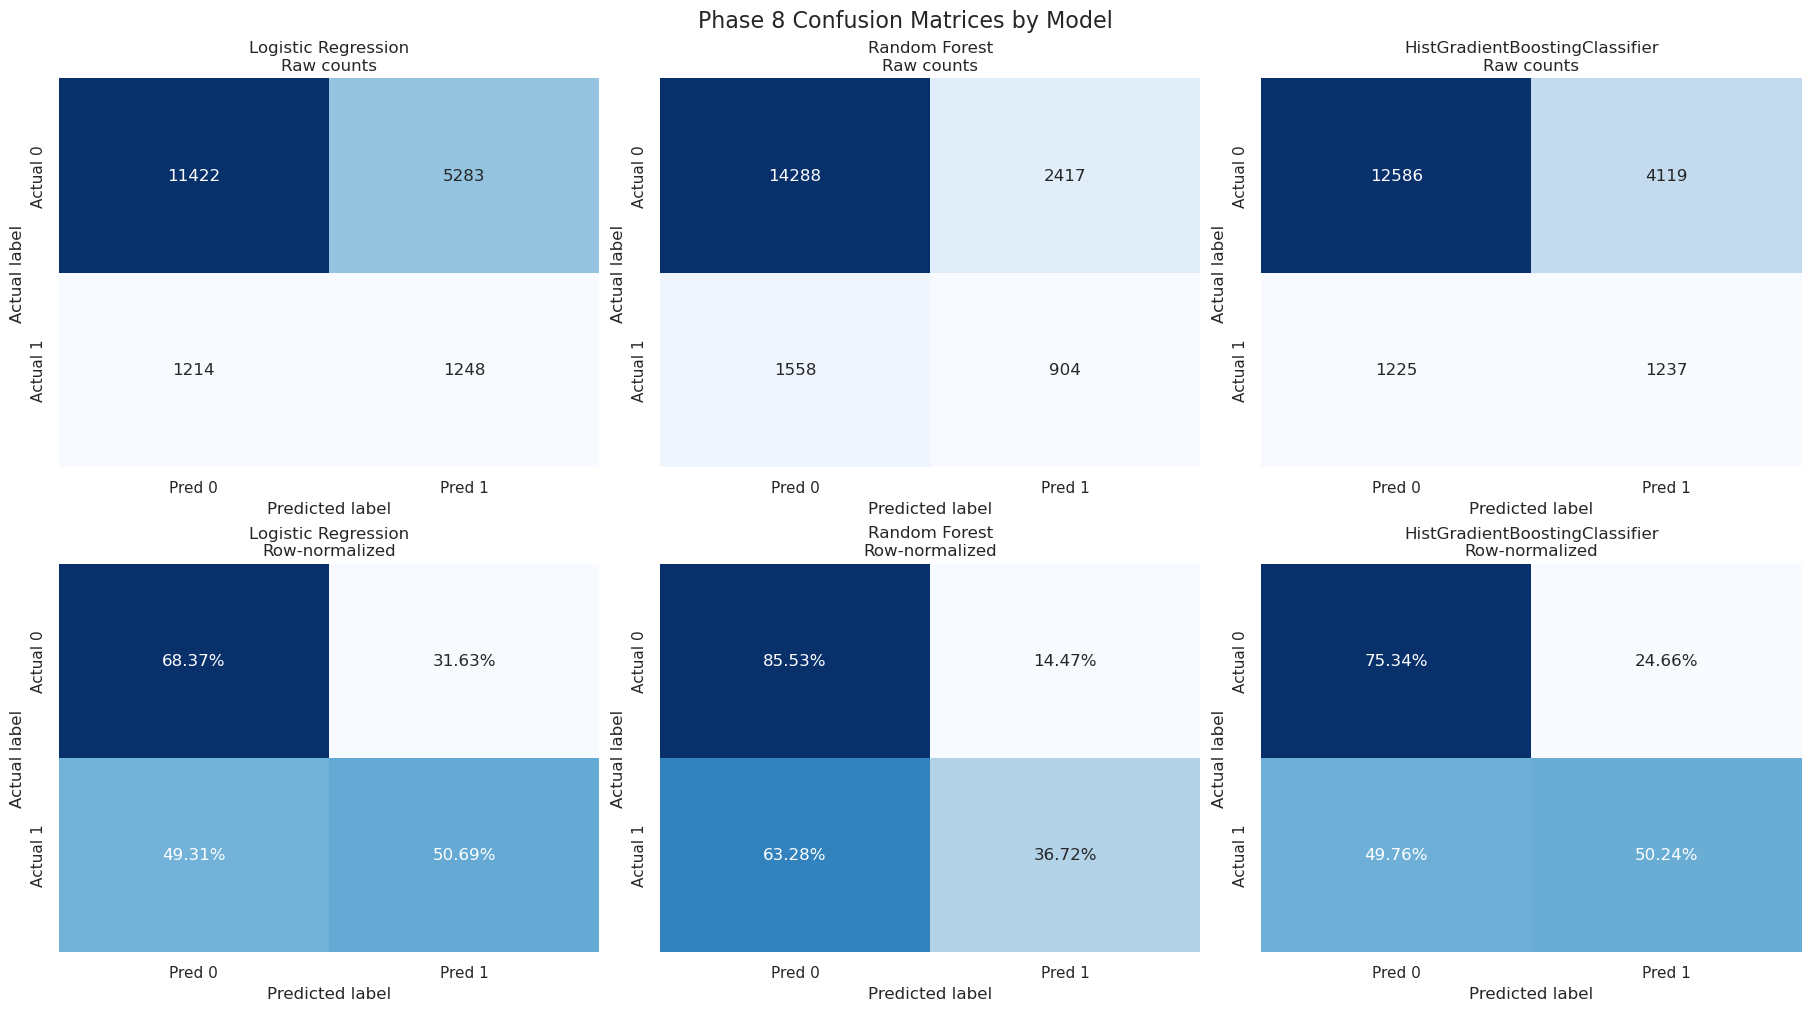

Confusion matrix figure saved to:
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/figures/phase8_confusion_matrices.png


In [45]:
if plt is None:
    raise ImportError("matplotlib is required for Phase 8 evaluation plots.")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(
    nrows=2,
    ncols=len(model_predictions),
    figsize=(18, 10),
    constrained_layout=True,
)

for col_idx, (model_name, matrices) in enumerate(phase_8_confusion_matrices.items()):
    raw_cm = matrices["raw"]
    normalized_cm = matrices["normalized"]

    if sns is not None:
        sns.heatmap(
            raw_cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Actual 0", "Actual 1"],
            ax=axes[0, col_idx],
        )
        sns.heatmap(
            normalized_cm,
            annot=True,
            fmt=".2%",
            cmap="Blues",
            cbar=False,
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Actual 0", "Actual 1"],
            ax=axes[1, col_idx],
        )
    else:
        axes[0, col_idx].imshow(raw_cm, cmap="Blues")
        axes[1, col_idx].imshow(normalized_cm, cmap="Blues")
        for row in range(2):
            for col in range(2):
                axes[0, col_idx].text(col, row, f"{raw_cm[row, col]:d}", ha="center", va="center")
                axes[1, col_idx].text(col, row, f"{normalized_cm[row, col]:.2%}", ha="center", va="center")

    axes[0, col_idx].set_title(f"{model_name}\nRaw counts")
    axes[1, col_idx].set_title(f"{model_name}\nRow-normalized")
    axes[0, col_idx].set_xlabel("Predicted label")
    axes[1, col_idx].set_xlabel("Predicted label")
    axes[0, col_idx].set_ylabel("Actual label")
    axes[1, col_idx].set_ylabel("Actual label")

fig.suptitle("Phase 8 Confusion Matrices by Model", fontsize=16)
confusion_matrix_fig_path = FIGURES_DIR / "phase8_confusion_matrices.png"
fig.savefig(confusion_matrix_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix figure saved to:")
print(confusion_matrix_fig_path)

### ROC and Precision-Recall Curves

ROC curves summarize how well each model ranks risky orders above non-risky orders across thresholds. Precision-recall curves focus more directly on minority-class performance, which is useful here because low reviews are relatively uncommon.

The plotted probabilities are all generated on the held-out test set from the fitted model pipelines. No threshold tuning is performed in this comparison.

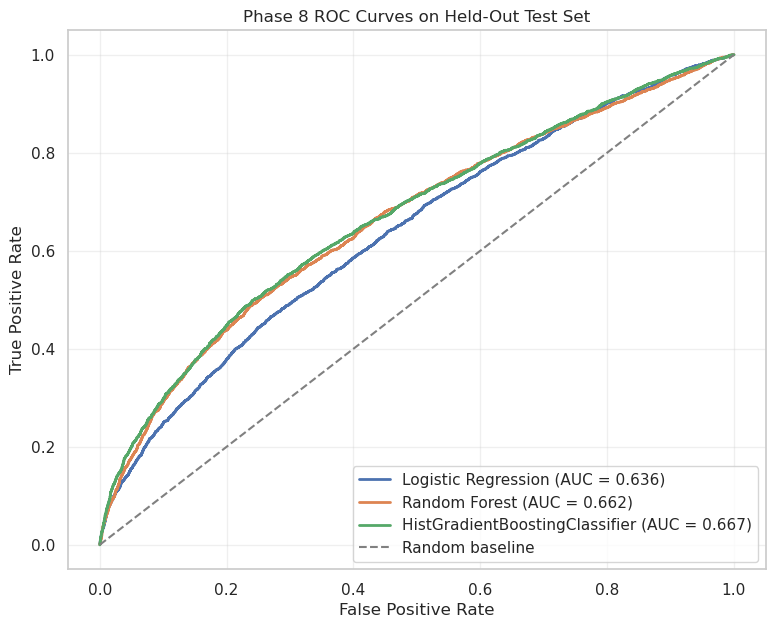

ROC curve figure saved to:
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/figures/phase8_roc_curves.png


In [46]:
fig, ax = plt.subplots(figsize=(9, 7))

for model_name, prediction_data in model_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, prediction_data["y_proba"])
    roc_auc = roc_auc_score(y_test, prediction_data["y_proba"])
    ax.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
ax.set_title("Phase 8 ROC Curves on Held-Out Test Set")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

roc_curve_fig_path = FIGURES_DIR / "phase8_roc_curves.png"
fig.savefig(roc_curve_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("ROC curve figure saved to:")
print(roc_curve_fig_path)

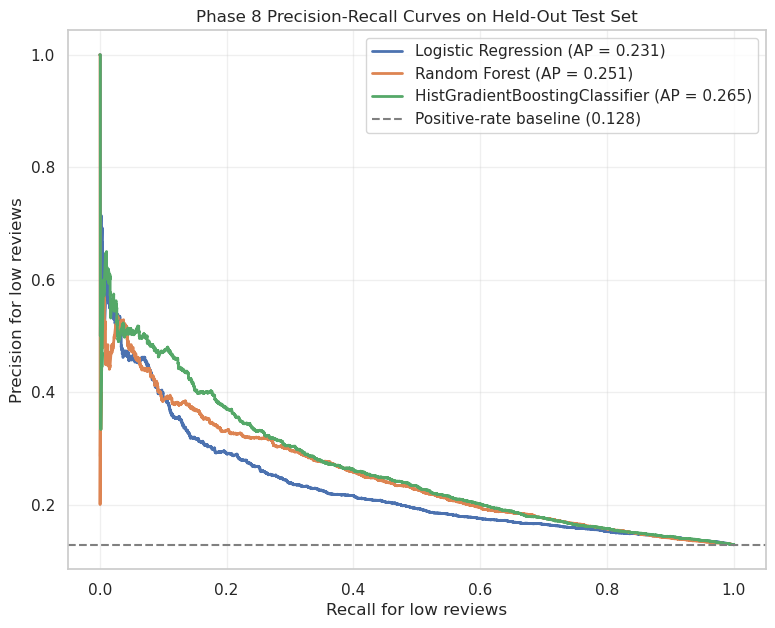

Precision-recall curve figure saved to:
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/figures/phase8_precision_recall_curves.png


In [47]:
fig, ax = plt.subplots(figsize=(9, 7))

baseline_positive_rate = y_test.mean()
for model_name, prediction_data in model_predictions.items():
    precision, recall, _ = precision_recall_curve(y_test, prediction_data["y_proba"])
    pr_auc = average_precision_score(y_test, prediction_data["y_proba"])
    ax.plot(recall, precision, linewidth=2, label=f"{model_name} (AP = {pr_auc:.3f})")

ax.axhline(
    baseline_positive_rate,
    linestyle="--",
    color="gray",
    label=f"Positive-rate baseline ({baseline_positive_rate:.3f})",
)
ax.set_title("Phase 8 Precision-Recall Curves on Held-Out Test Set")
ax.set_xlabel("Recall for low reviews")
ax.set_ylabel("Precision for low reviews")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

pr_curve_fig_path = FIGURES_DIR / "phase8_precision_recall_curves.png"
fig.savefig(pr_curve_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Precision-recall curve figure saved to:")
print(pr_curve_fig_path)

In [48]:
confusion_matrix_sums_valid = all(
    matrices["raw"].sum() == len(y_test)
    for matrices in phase_8_confusion_matrices.values()
)
roc_auc_values_above_random = (phase_8_comparison_table["roc_auc"] > 0.50).all()
probability_lengths_valid = all(
    len(prediction_data["y_proba"]) == len(y_test)
    for prediction_data in model_predictions.values()
)
comparison_table_saved = comparison_table_path.exists()
evaluation_plot_paths = [
    confusion_matrix_fig_path,
    roc_curve_fig_path,
    pr_curve_fig_path,
]
evaluation_plots_saved = all(path.exists() for path in evaluation_plot_paths)

phase_8_artifact_summary = pd.DataFrame(
    [
        {"artifact": "phase_8_comparison_table", "type": "DataFrame", "location": str(comparison_table_path)},
        {"artifact": "phase_8_classification_report_table", "type": "DataFrame", "location": "notebook memory"},
        {"artifact": "phase_8_confusion_matrices", "type": "dict of arrays", "location": "notebook memory"},
        {"artifact": "phase8_confusion_matrices.png", "type": "figure", "location": str(confusion_matrix_fig_path)},
        {"artifact": "phase8_roc_curves.png", "type": "figure", "location": str(roc_curve_fig_path)},
        {"artifact": "phase8_precision_recall_curves.png", "type": "figure", "location": str(pr_curve_fig_path)},
    ]
)

phase_8_validation = pd.DataFrame(
    [
        {
            "validation_check": "metrics computed on held-out test set",
            "status": "pass" if probability_lengths_valid else "fail",
            "details": f"test rows: {len(y_test):,}; prediction lengths: {[len(data['y_pred']) for data in model_predictions.values()]}",
        },
        {
            "validation_check": "ROC-AUC values are above random baseline",
            "status": "pass" if roc_auc_values_above_random else "review",
            "details": phase_8_comparison_table.set_index("model")["roc_auc"].round(4).to_dict(),
        },
        {
            "validation_check": "confusion matrices sum to test set size",
            "status": "pass" if confusion_matrix_sums_valid else "fail",
            "details": {model: int(matrices["raw"].sum()) for model, matrices in phase_8_confusion_matrices.items()},
        },
        {
            "validation_check": "comparison table saved",
            "status": "pass" if comparison_table_saved else "fail",
            "details": str(comparison_table_path),
        },
        {
            "validation_check": "evaluation plots saved",
            "status": "pass" if evaluation_plots_saved else "fail",
            "details": [str(path) for path in evaluation_plot_paths],
        },
    ]
)

phase_8_passed = (phase_8_validation["status"] == "pass").all()

print("Phase 8 artifacts created:")
display(phase_8_artifact_summary)
print("Phase 8 validation:")
display(phase_8_validation)
print(f"Strongest overall by academic discrimination metric: {best_academic_model}")
print(f"Strongest for recall-sensitive intervention use: {best_recall_model}")
print(f"Phase 8 passed blueprint validation checks: {phase_8_passed}")
print(f"Notebook ready for Phase 9 interpretability and error analysis: {phase_8_passed}")

Phase 8 artifacts created:


,artifact,type,location
0,phase_8_comparison_table,DataFrame,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
1,phase_8_classification_report_table,DataFrame,notebook memory
2,phase_8_confusion_matrices,dict of arrays,notebook memory
3,phase8_confusion_matrices.png,figure,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
4,phase8_roc_curves.png,figure,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
5,phase8_precision_recall_curves.png,figure,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...


Phase 8 validation:


,validation_check,status,details
0,metrics computed on held-out test set,pass,"test rows: 19,167; prediction lengths: [19167,..."
1,ROC-AUC values are above random baseline,pass,"{'HistGradientBoostingClassifier': 0.6668, 'Ra..."
2,confusion matrices sum to test set size,pass,"{'Logistic Regression': 19167, 'Random Forest'..."
3,comparison table saved,pass,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
4,evaluation plots saved,pass,[/mnt/data/Programming/ML_FINAL_PROJECT/output...


Strongest overall by academic discrimination metric: HistGradientBoostingClassifier
Strongest for recall-sensitive intervention use: Logistic Regression
Phase 8 passed blueprint validation checks: True
Notebook ready for Phase 9 interpretability and error analysis: True


### Evaluation Interpretation

The strongest model depends on the decision criterion. From an academic metric perspective, the best overall model is the one with the highest ROC-AUC, with PR-AUC and class-1 F1 used as supporting evidence because the positive class is imbalanced. `HistGradientBoostingClassifier` has the strongest overall discrimination by ROC-AUC, with Random Forest close behind.

For recall-sensitive intervention use, the priority shifts toward finding as many truly at-risk orders as possible, even if that creates more false positives. At the default 0.50 threshold, Logistic Regression has the highest class-1 recall by a very small margin. `HistGradientBoostingClassifier` is nearly tied on recall while offering better class-1 F1 and stronger probability ranking, so it is the more balanced intervention candidate if the business wants recall without as many false alarms.

Accuracy alone would be misleading here because the majority class dominates the dataset. A high-accuracy model can still miss many low-review orders. The confusion matrices show why the business trade-off matters: false negatives are missed intervention opportunities, while false positives consume intervention resources. The best deployment choice would depend on how expensive outreach is relative to the cost of missing a poor customer experience.

Feature importance and error-segment analysis are handled in the next section.

## 9. Feature Importance and Error Analysis

### Interpretability and Error Analysis Scope

This section examines what the trained models appear to be using and where the strongest evaluation model makes mistakes. Interpretability is framed carefully: the results identify features associated with higher or lower predicted risk, not causal drivers of low reviews.

Three complementary views are used: Logistic Regression coefficients for directional interpretation, Random Forest impurity-based feature importance for nonlinear tree signals, and permutation importance for `HistGradientBoostingClassifier` because sklearn's histogram gradient boosting model does not expose a direct `feature_importances_` attribute.

In [49]:
from sklearn.inspection import permutation_importance

required_phase_9_inputs = [
    "logistic_regression_pipeline",
    "random_forest_pipeline",
    "hist_gradient_boosting_pipeline",
    "X_test",
    "y_test",
    "hgb_y_test_pred",
    "hgb_y_test_proba",
    "best_academic_model",
    "phase_8_passed",
]
missing_phase_9_inputs = [name for name in required_phase_9_inputs if name not in globals()]
if missing_phase_9_inputs:
    raise NameError(
        "Run Phase 8 before Phase 9. Missing required objects: "
        f"{missing_phase_9_inputs}"
    )
if not phase_8_passed:
    raise ValueError("Phase 8 validation must pass before Phase 9 interpretation.")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def clean_transformed_feature_name(feature_name):
    """Make ColumnTransformer feature names readable for notebook tables and plots."""
    cleaned = feature_name.split("__", 1)[-1]
    for categorical_feature in categorical_features_used:
        prefix = f"{categorical_feature}_"
        if cleaned.startswith(prefix):
            return f"{categorical_feature}={cleaned[len(prefix):]}"
    return cleaned


def original_feature_from_transformed_name(feature_name):
    """Map a transformed one-hot feature back to its original input column."""
    cleaned = feature_name.split("__", 1)[-1]
    for categorical_feature in categorical_features_used:
        if cleaned.startswith(f"{categorical_feature}_"):
            return categorical_feature
    return cleaned


def plot_horizontal_importance(data, value_col, label_col, title, path, color="steelblue"):
    plot_data = data.sort_values(value_col, ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(plot_data))))
    ax.barh(plot_data[label_col], plot_data[value_col], color=color)
    ax.set_title(title)
    ax.set_xlabel(value_col.replace("_", " "))
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    return path

transformed_feature_names = logistic_regression_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()
clean_feature_names = [
    clean_transformed_feature_name(name) for name in transformed_feature_names
]
original_feature_names_from_transformed = [
    original_feature_from_transformed_name(name) for name in transformed_feature_names
]

print(f"Recovered {len(clean_feature_names)} readable transformed feature names.")

Recovered 172 readable transformed feature names.


### Logistic Regression Coefficients

Because the preprocessing pipeline standardizes numeric features and one-hot encodes categorical features, Logistic Regression coefficients can be read as directional associations with the log-odds of a low review. Positive coefficients are associated with higher predicted risk; negative coefficients are associated with lower predicted risk.

Coefficient magnitude should still be interpreted cautiously. One-hot encoded category coefficients are relative to the regularized model and the observed category distribution, not proof that a category causes low reviews.

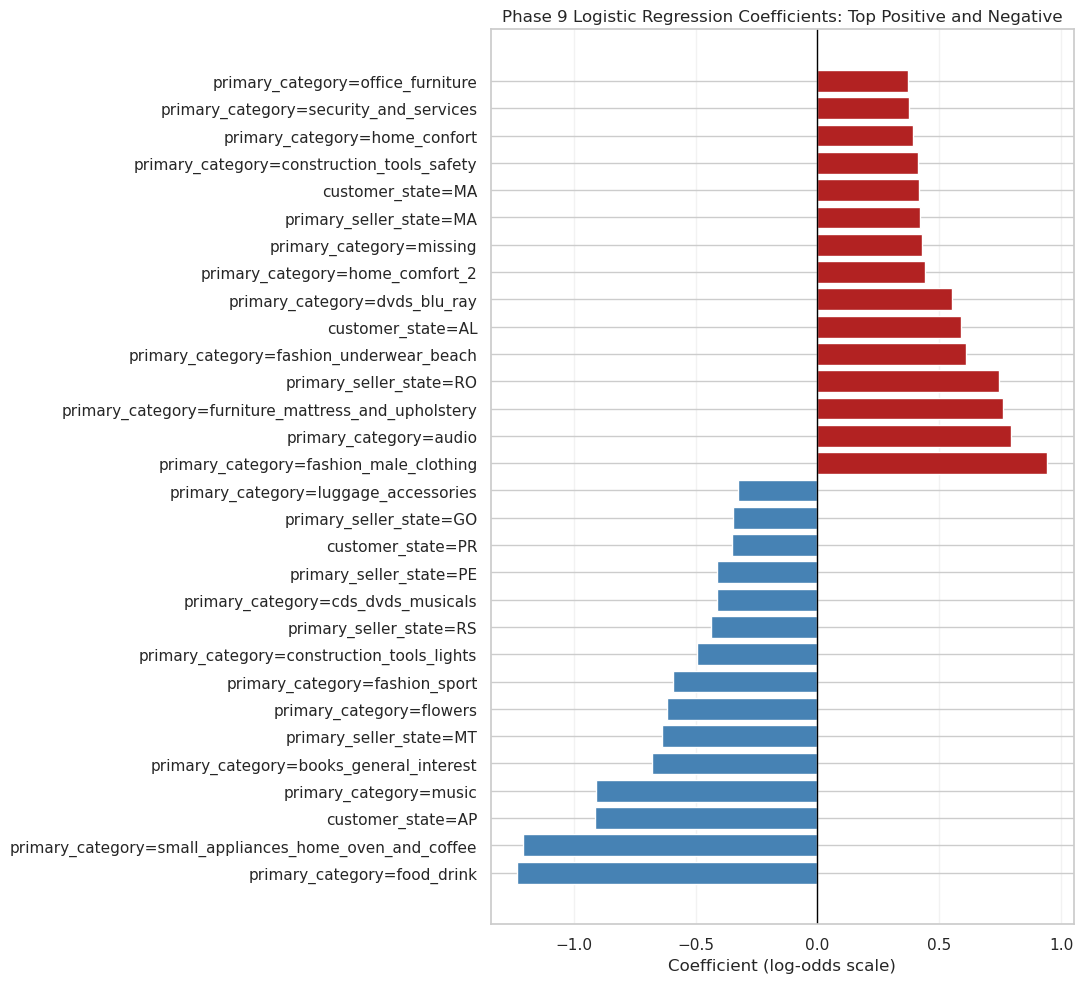

Top positive Logistic Regression coefficients:


,feature,coefficient
130,primary_category=fashion_male_clothing,0.9440
104,primary_category=audio,0.7936
141,primary_category=furniture_mattress_and_uphols...,0.7614
95,primary_seller_state=RO,0.7447
133,primary_category=fashion_underwear_beach,0.6100
52,customer_state=AL,0.5882
125,primary_category=dvds_blu_ray,0.5535
146,primary_category=home_comfort_2,0.4429
155,primary_category=missing,0.4299
84,primary_seller_state=MA,0.4187


Top negative Logistic Regression coefficients:


,feature,coefficient
137,primary_category=food_drink,-1.2323
165,primary_category=small_appliances_home_oven_an...,-1.2072
54,customer_state=AP,-0.9148
156,primary_category=music,-0.9090
108,primary_category=books_general_interest,-0.6800
87,primary_seller_state=MT,-0.6367
135,primary_category=flowers,-0.6164
132,primary_category=fashion_sport,-0.5936
118,primary_category=construction_tools_lights,-0.4949
96,primary_seller_state=RS,-0.4370


Saved Logistic Regression coefficient table and figure:
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/phase9_logistic_regression_coefficients.csv
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/figures/phase9_logistic_regression_coefficients.png


In [50]:
lr_coefficients = logistic_regression_pipeline.named_steps["classifier"].coef_[0]

lr_coefficient_table = pd.DataFrame(
    {
        "feature": clean_feature_names,
        "original_feature": original_feature_names_from_transformed,
        "coefficient": lr_coefficients,
        "abs_coefficient": np.abs(lr_coefficients),
    }
).sort_values("coefficient", ascending=False)

lr_top_positive_coefficients = lr_coefficient_table.head(15).copy()
lr_top_negative_coefficients = lr_coefficient_table.tail(15).sort_values(
    "coefficient",
    ascending=True,
).copy()
lr_top_coefficients_for_plot = pd.concat(
    [lr_top_negative_coefficients, lr_top_positive_coefficients],
    ignore_index=True,
)

lr_coefficients_path = OUTPUT_DIR / "phase9_logistic_regression_coefficients.csv"
lr_coefficient_table.to_csv(lr_coefficients_path, index=False)

lr_coefficient_fig_path = FIGURES_DIR / "phase9_logistic_regression_coefficients.png"
fig, ax = plt.subplots(figsize=(11, 10))
coefficient_colors = np.where(
    lr_top_coefficients_for_plot["coefficient"] >= 0,
    "firebrick",
    "steelblue",
)
ax.barh(
    lr_top_coefficients_for_plot["feature"],
    lr_top_coefficients_for_plot["coefficient"],
    color=coefficient_colors,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Phase 9 Logistic Regression Coefficients: Top Positive and Negative")
ax.set_xlabel("Coefficient (log-odds scale)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(lr_coefficient_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Top positive Logistic Regression coefficients:")
display(lr_top_positive_coefficients[["feature", "coefficient"]].round(4))
print("Top negative Logistic Regression coefficients:")
display(lr_top_negative_coefficients[["feature", "coefficient"]].round(4))
print("Saved Logistic Regression coefficient table and figure:")
print(lr_coefficients_path)
print(lr_coefficient_fig_path)

### Tree-Based Feature Importance

Random Forest provides impurity-based feature importances after preprocessing. Because one-hot encoding expands categorical variables, the table below aggregates transformed importances back to original feature names.

`HistGradientBoostingClassifier` does not expose a direct `feature_importances_` attribute in sklearn. For that model, permutation importance is calculated on the held-out test set: each original feature is shuffled, and the change in ROC-AUC is measured. This is slower than native importance, but it is model-agnostic and preserves readable original feature names.

Tree importance should be treated as a ranking of predictive usefulness, not causal explanation. Impurity-based importance can also favor variables with many possible split points, so consistency across methods is more persuasive than any single ranking.

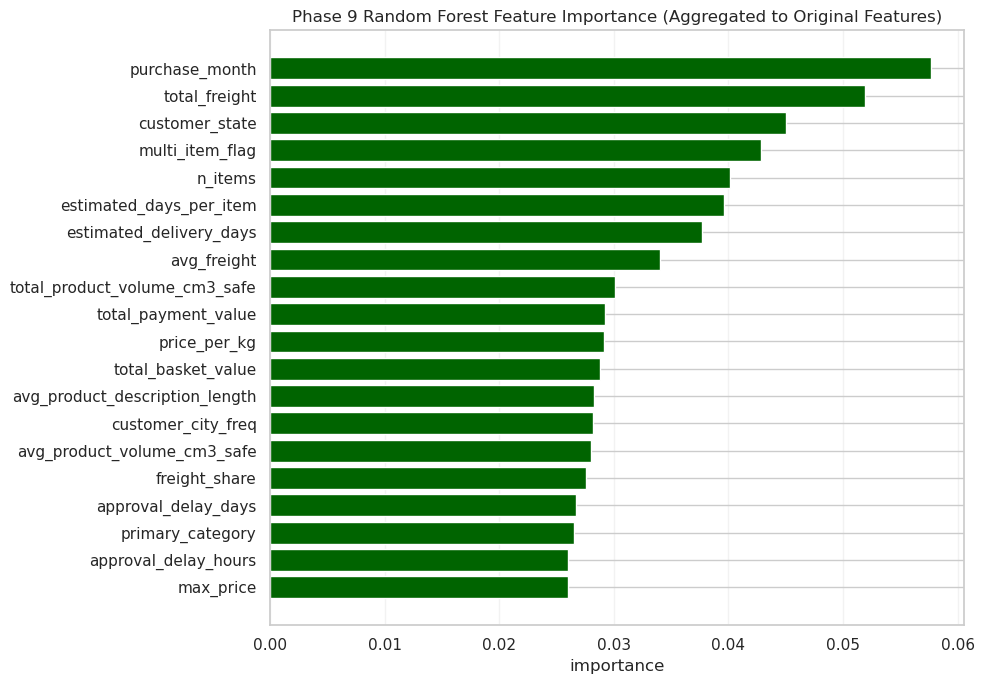

Top Random Forest feature importances:


,original_feature,importance
0,purchase_month,0.0577
1,total_freight,0.0520
2,customer_state,0.0450
3,multi_item_flag,0.0428
4,n_items,0.0401
5,estimated_days_per_item,0.0396
6,estimated_delivery_days,0.0377
7,avg_freight,0.0340
8,total_product_volume_cm3_safe,0.0301
9,total_payment_value,0.0292


Saved Random Forest feature importance table and figure:
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/phase9_random_forest_feature_importance.csv
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/figures/phase9_random_forest_feature_importance.png


In [51]:
rf_transformed_importance_table = pd.DataFrame(
    {
        "transformed_feature": clean_feature_names,
        "original_feature": original_feature_names_from_transformed,
        "importance": random_forest_pipeline.named_steps["classifier"].feature_importances_,
    }
).sort_values("importance", ascending=False)

rf_feature_importance_table = (
    rf_transformed_importance_table
    .groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
rf_top_feature_importance = rf_feature_importance_table.head(20).copy()

rf_importance_path = OUTPUT_DIR / "phase9_random_forest_feature_importance.csv"
rf_feature_importance_table.to_csv(rf_importance_path, index=False)

rf_importance_fig_path = FIGURES_DIR / "phase9_random_forest_feature_importance.png"
plot_horizontal_importance(
    rf_top_feature_importance,
    value_col="importance",
    label_col="original_feature",
    title="Phase 9 Random Forest Feature Importance (Aggregated to Original Features)",
    path=rf_importance_fig_path,
    color="darkgreen",
)

print("Top Random Forest feature importances:")
display(rf_top_feature_importance.round(4))
print("Saved Random Forest feature importance table and figure:")
print(rf_importance_path)
print(rf_importance_fig_path)

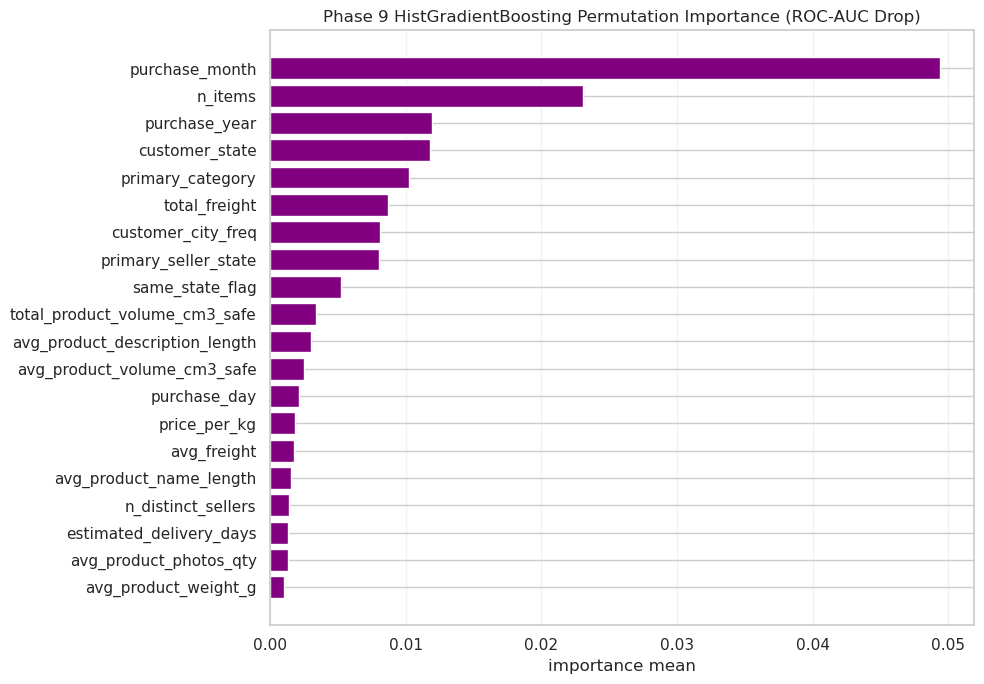

Top HistGradientBoosting permutation importances:


,feature,importance_mean,importance_std
1,purchase_month,0.0494,0.0050
9,n_items,0.0231,0.0021
0,purchase_year,0.0119,0.0023
36,customer_state,0.0118,0.0008
43,primary_category,0.0102,0.0009
12,total_freight,0.0087,0.0020
37,customer_city_freq,0.0081,0.0011
39,primary_seller_state,0.0080,0.0020
40,same_state_flag,0.0052,0.0013
51,total_product_volume_cm3_safe,0.0034,0.0013


Saved HistGradientBoosting permutation importance table and figure:
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/phase9_hgb_permutation_importance.csv
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/figures/phase9_hgb_permutation_importance.png


In [52]:
hgb_permutation_result = permutation_importance(
    hist_gradient_boosting_pipeline,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

hgb_permutation_importance_table = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": hgb_permutation_result.importances_mean,
        "importance_std": hgb_permutation_result.importances_std,
    }
).sort_values("importance_mean", ascending=False)

hgb_top_permutation_importance = hgb_permutation_importance_table.head(20).copy()

hgb_importance_path = OUTPUT_DIR / "phase9_hgb_permutation_importance.csv"
hgb_permutation_importance_table.to_csv(hgb_importance_path, index=False)

hgb_importance_fig_path = FIGURES_DIR / "phase9_hgb_permutation_importance.png"
plot_horizontal_importance(
    hgb_top_permutation_importance,
    value_col="importance_mean",
    label_col="feature",
    title="Phase 9 HistGradientBoosting Permutation Importance (ROC-AUC Drop)",
    path=hgb_importance_fig_path,
    color="purple",
)

print("Top HistGradientBoosting permutation importances:")
display(hgb_top_permutation_importance.round(4))
print("Saved HistGradientBoosting permutation importance table and figure:")
print(hgb_importance_path)
print(hgb_importance_fig_path)

In [53]:
top_signal_sources = pd.concat(
    [
        lr_coefficient_table.head(20).assign(source="LR positive coefficient", score=lr_coefficient_table.head(20)["abs_coefficient"])[["source", "original_feature", "feature", "score"]],
        rf_feature_importance_table.head(20).assign(source="Random Forest importance", feature=rf_feature_importance_table.head(20)["original_feature"], score=rf_feature_importance_table.head(20)["importance"])[["source", "original_feature", "feature", "score"]],
        hgb_permutation_importance_table.head(20).assign(source="HGB permutation importance", original_feature=hgb_permutation_importance_table.head(20)["feature"], score=hgb_permutation_importance_table.head(20)["importance_mean"])[["source", "original_feature", "feature", "score"]],
    ],
    ignore_index=True,
)

risk_signal_ranking = (
    top_signal_sources
    .groupby("original_feature", as_index=False)
    .agg(
        n_top_lists=("source", "nunique"),
        sources=("source", lambda values: ", ".join(sorted(set(values)))),
        max_score=("score", "max"),
    )
    .sort_values(["n_top_lists", "max_score"], ascending=False)
    .reset_index(drop=True)
)

risk_signal_ranking_path = OUTPUT_DIR / "phase9_risk_signal_ranking.csv"
risk_signal_ranking.to_csv(risk_signal_ranking_path, index=False)

print("Cross-model ranking of strongest risk-associated features:")
display(risk_signal_ranking.head(15).round(4))
print("Saved risk signal ranking:")
print(risk_signal_ranking_path)

Cross-model ranking of strongest risk-associated features:


,original_feature,n_top_lists,sources,max_score
0,primary_category,3,"HGB permutation importance, LR positive coeffi...",0.9440
1,customer_state,3,"HGB permutation importance, LR positive coeffi...",0.5882
2,primary_seller_state,2,"HGB permutation importance, LR positive coeffi...",0.7447
3,purchase_month,2,"HGB permutation importance, Random Forest impo...",0.0577
4,total_freight,2,"HGB permutation importance, Random Forest impo...",0.0520
5,n_items,2,"HGB permutation importance, Random Forest impo...",0.0401
6,estimated_delivery_days,2,"HGB permutation importance, Random Forest impo...",0.0377
7,avg_freight,2,"HGB permutation importance, Random Forest impo...",0.0340
8,total_product_volume_cm3_safe,2,"HGB permutation importance, Random Forest impo...",0.0301
9,price_per_kg,2,"HGB permutation importance, Random Forest impo...",0.0291


Saved risk signal ranking:
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/phase9_risk_signal_ranking.csv


### Error Analysis on the Best Model

`HistGradientBoostingClassifier` is the strongest overall model by ROC-AUC, so error analysis focuses on that model. False negatives and false positives are examined separately because they represent different business problems.

False negatives are at-risk orders the model missed. These are especially important for proactive support because the business would not intervene. False positives are orders the model flagged as risky even though the customer did not leave a low review; these can waste intervention resources.

In [54]:
best_model_for_error_analysis = best_academic_model
if best_model_for_error_analysis != "HistGradientBoostingClassifier":
    print(
        "Phase 8 selected a different academic-best model; using "
        f"{best_model_for_error_analysis} for error analysis."
    )

best_model_prediction_lookup = {
    "Logistic Regression": (lr_y_test_pred, lr_y_test_proba),
    "Random Forest": (rf_y_test_pred, rf_y_test_proba),
    "HistGradientBoostingClassifier": (hgb_y_test_pred, hgb_y_test_proba),
}
best_model_y_pred, best_model_y_proba = best_model_prediction_lookup[
    best_model_for_error_analysis
]

error_analysis_df = X_test.copy()
error_analysis_df["actual_low_review"] = y_test.values
error_analysis_df["predicted_low_review"] = best_model_y_pred
error_analysis_df["predicted_low_review_probability"] = best_model_y_proba

error_conditions = [
    (error_analysis_df["actual_low_review"] == 1) & (error_analysis_df["predicted_low_review"] == 1),
    (error_analysis_df["actual_low_review"] == 1) & (error_analysis_df["predicted_low_review"] == 0),
    (error_analysis_df["actual_low_review"] == 0) & (error_analysis_df["predicted_low_review"] == 1),
    (error_analysis_df["actual_low_review"] == 0) & (error_analysis_df["predicted_low_review"] == 0),
]
error_labels = ["true_positive", "false_negative", "false_positive", "true_negative"]
error_analysis_df["prediction_group"] = np.select(
    error_conditions,
    error_labels,
    default="unclassified",
)

phase_9_error_group_counts = (
    error_analysis_df["prediction_group"]
    .value_counts()
    .rename_axis("prediction_group")
    .reset_index(name="n_orders")
)
phase_9_error_group_counts["share_of_test_set"] = (
    phase_9_error_group_counts["n_orders"] / len(error_analysis_df)
).round(4)

error_analysis_path = OUTPUT_DIR / "phase9_best_model_error_analysis_rows.csv"
error_analysis_df.to_csv(error_analysis_path, index=False)

print(f"Best model used for error analysis: {best_model_for_error_analysis}")
print("Prediction group counts:")
display(phase_9_error_group_counts)
print("Saved row-level error analysis table:")
print(error_analysis_path)

Best model used for error analysis: HistGradientBoostingClassifier
Prediction group counts:


,prediction_group,n_orders,share_of_test_set
0,true_negative,12586,0.6566
1,false_positive,4119,0.2149
2,true_positive,1237,0.0645
3,false_negative,1225,0.0639


Saved row-level error analysis table:
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/phase9_best_model_error_analysis_rows.csv


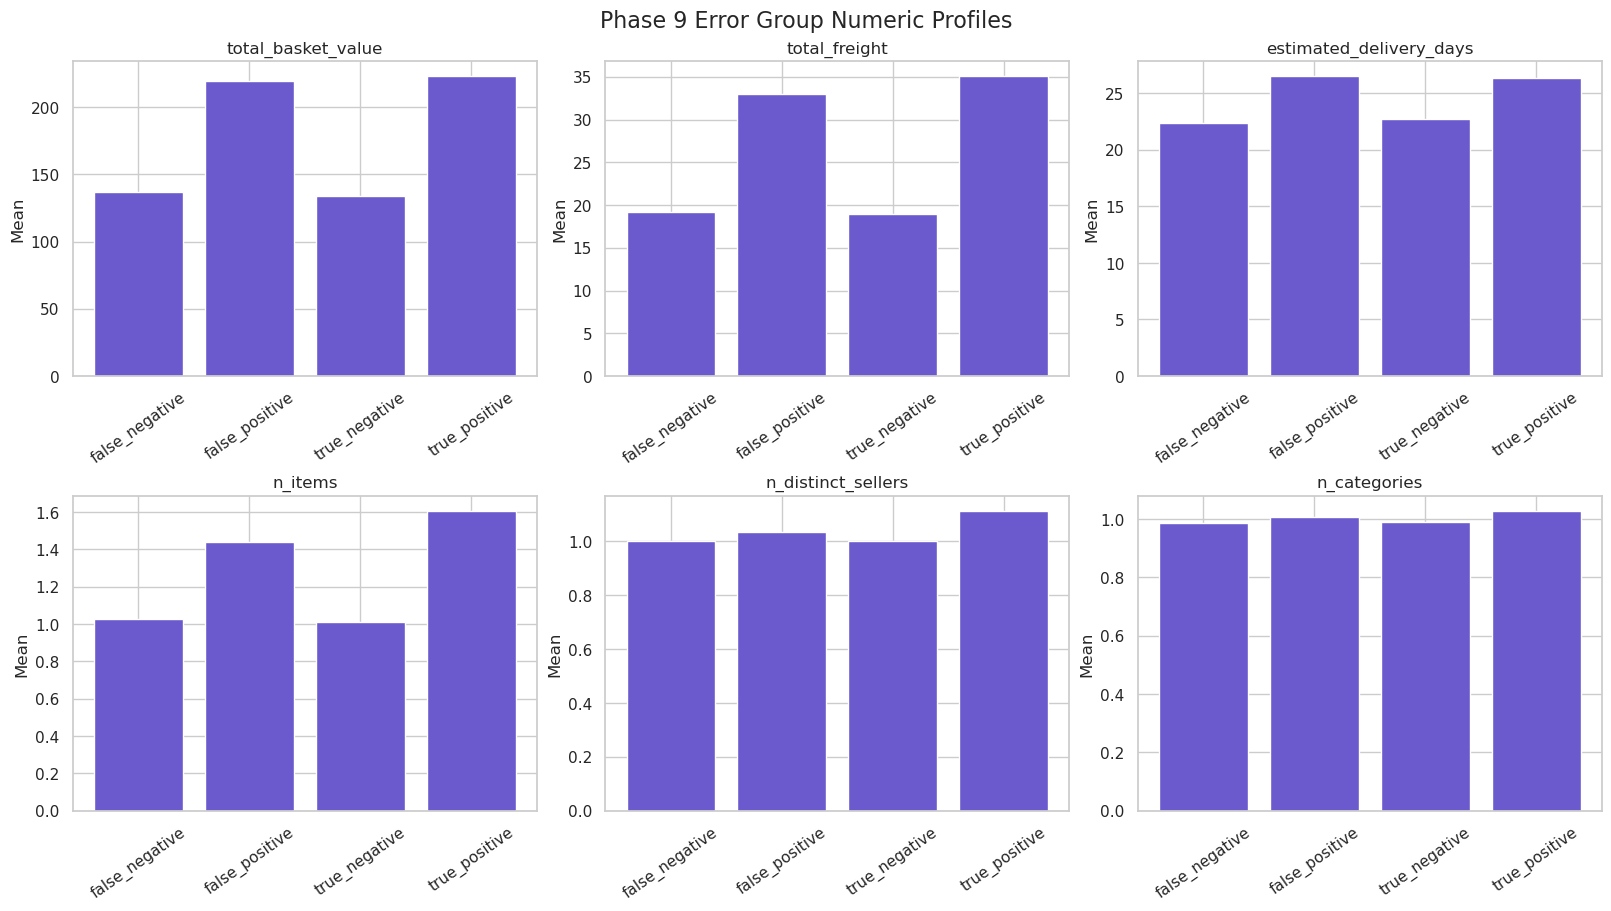

Numeric profile by prediction group:


,prediction_group,total_basket_value_mean,total_basket_value_median,total_price_mean,total_price_median,total_freight_mean,total_freight_median,freight_share_mean,freight_share_median,estimated_delivery_days_mean,...,n_payment_methods_mean,n_payment_methods_median,multi_seller_flag_mean,multi_seller_flag_median,multi_category_flag_mean,multi_category_flag_median,high_installment_flag_mean,high_installment_flag_median,same_state_flag_mean,same_state_flag_median
0,false_negative,136.713,93.78,117.565,74.990,19.148,15.82,0.204,0.176,22.349,...,1.017,1.0,0.000,0.0,0.000,0.0,0.147,0.0,0.421,0.0
1,false_positive,219.684,142.30,186.696,115.900,32.988,24.81,0.220,0.196,26.517,...,1.024,1.0,0.033,0.0,0.020,0.0,0.207,0.0,0.197,0.0
2,true_negative,133.630,93.02,114.684,75.895,18.945,15.93,0.206,0.182,22.679,...,1.021,1.0,0.000,0.0,0.000,0.0,0.136,0.0,0.423,0.0
3,true_positive,223.110,147.94,188.017,119.600,35.093,25.66,0.225,0.203,26.318,...,1.026,1.0,0.107,0.0,0.047,0.0,0.198,0.0,0.171,0.0


Saved numeric error summary and figure:
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/phase9_error_numeric_summary.csv
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/figures/phase9_error_numeric_profiles.png


In [55]:
error_numeric_features = [
    "total_basket_value",
    "total_price",
    "total_freight",
    "freight_share",
    "estimated_delivery_days",
    "n_items",
    "n_distinct_sellers",
    "n_categories",
    "max_payment_installments",
    "n_payment_methods",
    "multi_seller_flag",
    "multi_category_flag",
    "high_installment_flag",
    "same_state_flag",
]
error_numeric_features = [
    feature for feature in error_numeric_features if feature in error_analysis_df.columns
]

phase_9_error_numeric_summary = (
    error_analysis_df
    .groupby("prediction_group")[error_numeric_features]
    .agg(["mean", "median"])
    .round(3)
)
phase_9_error_numeric_summary.columns = [
    f"{feature}_{stat}" for feature, stat in phase_9_error_numeric_summary.columns
]
phase_9_error_numeric_summary = phase_9_error_numeric_summary.reset_index()

phase_9_error_numeric_summary_path = OUTPUT_DIR / "phase9_error_numeric_summary.csv"
phase_9_error_numeric_summary.to_csv(phase_9_error_numeric_summary_path, index=False)

profile_plot_features = [
    "total_basket_value",
    "total_freight",
    "estimated_delivery_days",
    "n_items",
    "n_distinct_sellers",
    "n_categories",
]
profile_plot_features = [
    feature for feature in profile_plot_features if feature in error_analysis_df.columns
]
profile_plot_df = (
    error_analysis_df
    .groupby("prediction_group")[profile_plot_features]
    .mean()
    .reset_index()
    .melt(id_vars="prediction_group", var_name="feature", value_name="mean_value")
)

error_numeric_profile_fig_path = FIGURES_DIR / "phase9_error_numeric_profiles.png"
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16, 9),
    constrained_layout=True,
)
axes = axes.flatten()
for idx, feature in enumerate(profile_plot_features):
    feature_plot_df = profile_plot_df.loc[profile_plot_df["feature"] == feature]
    axes[idx].bar(
        feature_plot_df["prediction_group"],
        feature_plot_df["mean_value"],
        color="slateblue",
    )
    axes[idx].set_title(feature)
    axes[idx].tick_params(axis="x", rotation=35)
    axes[idx].set_ylabel("Mean")
for idx in range(len(profile_plot_features), len(axes)):
    axes[idx].axis("off")
fig.suptitle("Phase 9 Error Group Numeric Profiles", fontsize=16)
fig.savefig(error_numeric_profile_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Numeric profile by prediction group:")
display(phase_9_error_numeric_summary)
print("Saved numeric error summary and figure:")
print(phase_9_error_numeric_summary_path)
print(error_numeric_profile_fig_path)

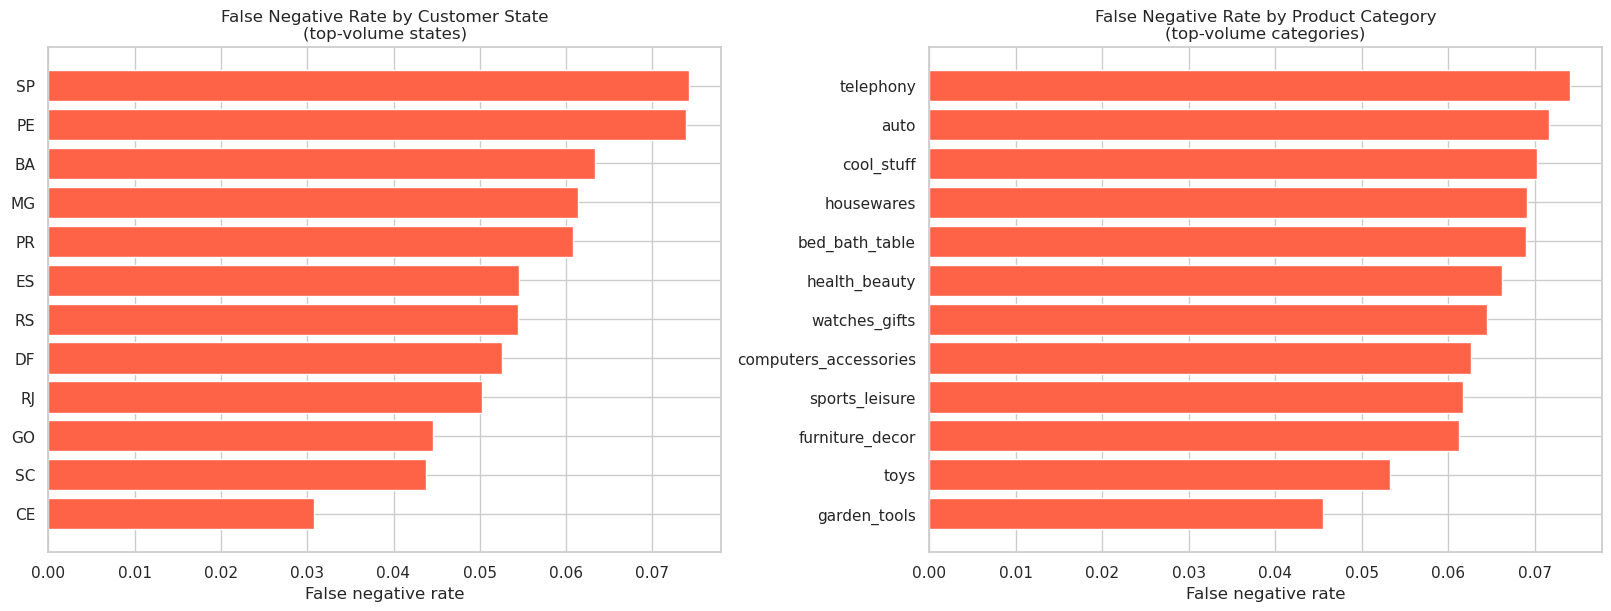

Customer-state error summary:


,customer_state,n_orders,low_review_rate,predicted_risk_rate,mean_predicted_probability,false_negative_rate,false_positive_rate
25,SP,8058,0.1083,0.1659,0.4226,0.0742,0.1318
18,RJ,2447,0.1835,0.4687,0.5376,0.0503,0.3355
10,MG,2265,0.1170,0.2658,0.4461,0.0614,0.2102
22,RS,1065,0.1296,0.2854,0.4424,0.0545,0.2103
17,PR,938,0.1205,0.2313,0.4301,0.0608,0.1716
23,SC,708,0.0960,0.3051,0.4611,0.0438,0.2528
4,BA,647,0.1623,0.4359,0.5069,0.0634,0.3369
6,DF,438,0.1530,0.3973,0.4981,0.0525,0.2968
7,ES,403,0.1340,0.3226,0.4687,0.0546,0.2432
8,GO,381,0.1207,0.4121,0.4889,0.0446,0.3360


Product-category error summary:


,primary_category,n_orders,low_review_rate,predicted_risk_rate,mean_predicted_probability,false_negative_rate,false_positive_rate
7,bed_bath_table,1842,0.1710,0.3833,0.5038,0.0689,0.2812
43,health_beauty,1662,0.1125,0.2262,0.4433,0.0662,0.1799
64,sports_leisure,1507,0.1168,0.2376,0.4354,0.0617,0.1825
15,computers_accessories,1294,0.1453,0.3454,0.4743,0.0626,0.2628
39,furniture_decor,1209,0.1489,0.3581,0.4893,0.0612,0.2705
49,housewares,1158,0.1140,0.2150,0.4362,0.0691,0.1701
69,watches_gifts,1054,0.1281,0.3207,0.4771,0.0645,0.2571
67,telephony,797,0.1305,0.2785,0.4658,0.0740,0.2221
20,cool_stuff,755,0.1152,0.2026,0.4304,0.0702,0.1576
68,toys,732,0.0929,0.1967,0.4353,0.0533,0.1571


Saved segment error summaries and figure:
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/phase9_state_error_summary.csv
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/phase9_category_error_summary.csv
/mnt/data/Programming/ML_FINAL_PROJECT/outputs/figures/phase9_segment_error_patterns.png


In [56]:
def summarize_error_segment(frame, segment_column, min_count=50, top_n=10):
    summary = (
        frame
        .groupby(segment_column)
        .agg(
            n_orders=("actual_low_review", "size"),
            low_review_rate=("actual_low_review", "mean"),
            predicted_risk_rate=("predicted_low_review", "mean"),
            mean_predicted_probability=("predicted_low_review_probability", "mean"),
            false_negative_rate=("prediction_group", lambda values: np.mean(values == "false_negative")),
            false_positive_rate=("prediction_group", lambda values: np.mean(values == "false_positive")),
        )
        .reset_index()
    )
    summary = summary.loc[summary["n_orders"] >= min_count].copy()
    return summary.sort_values("n_orders", ascending=False).head(top_n)

phase_9_state_error_summary = summarize_error_segment(
    error_analysis_df,
    "customer_state",
    min_count=100,
    top_n=12,
)
phase_9_category_error_summary = summarize_error_segment(
    error_analysis_df,
    "primary_category",
    min_count=100,
    top_n=12,
)

phase_9_state_error_summary_path = OUTPUT_DIR / "phase9_state_error_summary.csv"
phase_9_category_error_summary_path = OUTPUT_DIR / "phase9_category_error_summary.csv"
phase_9_state_error_summary.to_csv(phase_9_state_error_summary_path, index=False)
phase_9_category_error_summary.to_csv(phase_9_category_error_summary_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
axes[0].barh(
    phase_9_state_error_summary.sort_values("false_negative_rate")["customer_state"],
    phase_9_state_error_summary.sort_values("false_negative_rate")["false_negative_rate"],
    color="tomato",
)
axes[0].set_title("False Negative Rate by Customer State\n(top-volume states)")
axes[0].set_xlabel("False negative rate")
axes[1].barh(
    phase_9_category_error_summary.sort_values("false_negative_rate")["primary_category"],
    phase_9_category_error_summary.sort_values("false_negative_rate")["false_negative_rate"],
    color="tomato",
)
axes[1].set_title("False Negative Rate by Product Category\n(top-volume categories)")
axes[1].set_xlabel("False negative rate")
segment_error_fig_path = FIGURES_DIR / "phase9_segment_error_patterns.png"
fig.savefig(segment_error_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Customer-state error summary:")
display(phase_9_state_error_summary.round(4))
print("Product-category error summary:")
display(phase_9_category_error_summary.round(4))
print("Saved segment error summaries and figure:")
print(phase_9_state_error_summary_path)
print(phase_9_category_error_summary_path)
print(segment_error_fig_path)

### Error Analysis Interpretation

The hardest cases are the ones where the observable pre-review features do not cleanly separate the eventual customer experience. False negatives are especially important because they are low-review orders that looked normal enough to avoid a risk flag. These may represent issues not visible in the available predictors, such as customer-service interactions, item quality problems, local carrier events, or delivery experience details that are intentionally excluded from the primary model to avoid leakage.

False positives tend to be orders that carry risk-associated signals but ultimately do not receive a low review. This is expected in a proactive risk model: complex baskets, higher freight burden, longer estimated delivery windows, or difficult geography can be linked to risk without guaranteeing dissatisfaction.

The segment tables should be read as diagnostic summaries, not causal evidence. They help identify where the model may need better features, threshold adjustment, or business rules before deployment.

In [57]:
phase_9_artifact_summary = pd.DataFrame(
    [
        {"artifact": "lr_coefficient_table", "type": "DataFrame", "location": str(lr_coefficients_path)},
        {"artifact": "rf_feature_importance_table", "type": "DataFrame", "location": str(rf_importance_path)},
        {"artifact": "hgb_permutation_importance_table", "type": "DataFrame", "location": str(hgb_importance_path)},
        {"artifact": "risk_signal_ranking", "type": "DataFrame", "location": str(risk_signal_ranking_path)},
        {"artifact": "error_analysis_df", "type": "DataFrame", "location": str(error_analysis_path)},
        {"artifact": "phase9_logistic_regression_coefficients.png", "type": "figure", "location": str(lr_coefficient_fig_path)},
        {"artifact": "phase9_random_forest_feature_importance.png", "type": "figure", "location": str(rf_importance_fig_path)},
        {"artifact": "phase9_hgb_permutation_importance.png", "type": "figure", "location": str(hgb_importance_fig_path)},
        {"artifact": "phase9_error_numeric_profiles.png", "type": "figure", "location": str(error_numeric_profile_fig_path)},
        {"artifact": "phase9_segment_error_patterns.png", "type": "figure", "location": str(segment_error_fig_path)},
    ]
)

phase_9_top_predictive_signals = risk_signal_ranking.head(8).copy()
phase_9_main_failure_patterns = pd.DataFrame(
    [
        {
            "failure_pattern": "false negatives",
            "business_meaning": "At-risk orders missed by the model; potential missed intervention opportunities.",
            "likely_explanation": "Some low reviews may be driven by unobserved service, item-quality, or post-purchase delivery experiences intentionally excluded from the leakage-safe feature set.",
        },
        {
            "failure_pattern": "false positives",
            "business_meaning": "Orders flagged for intervention that did not receive low reviews; potential wasted outreach.",
            "likely_explanation": "Some orders have risk-associated pre-review signals but still end in acceptable customer experiences.",
        },
        {
            "failure_pattern": "segment variation",
            "business_meaning": "Performance can differ by geography and category.",
            "likely_explanation": "State and category groups may combine logistics complexity, seller behavior, and customer expectations in ways not fully captured by the current feature set.",
        },
    ]
)

readable_feature_names_valid = (
    not lr_coefficient_table["feature"].astype(str).str.match(r"^x\d+$").any()
    and not rf_feature_importance_table["original_feature"].astype(str).str.match(r"^x\d+$").any()
    and not hgb_permutation_importance_table["feature"].astype(str).str.match(r"^x\d+$").any()
)
feature_artifacts_saved = all(
    path.exists()
    for path in [
        lr_coefficients_path,
        rf_importance_path,
        hgb_importance_path,
        risk_signal_ranking_path,
    ]
)
figures_saved = all(
    path.exists()
    for path in [
        lr_coefficient_fig_path,
        rf_importance_fig_path,
        hgb_importance_fig_path,
        error_numeric_profile_fig_path,
        segment_error_fig_path,
    ]
)
error_groups_present = {"false_positive", "false_negative"}.issubset(
    set(error_analysis_df["prediction_group"])
)

phase_9_validation = pd.DataFrame(
    [
        {
            "validation_check": "readable feature names recovered",
            "status": "pass" if readable_feature_names_valid else "fail",
            "details": f"{len(clean_feature_names)} transformed feature names recovered",
        },
        {
            "validation_check": "Logistic Regression coefficients created",
            "status": "pass" if not lr_coefficient_table.empty else "fail",
            "details": f"{len(lr_coefficient_table)} coefficient rows",
        },
        {
            "validation_check": "tree importance tables created",
            "status": "pass" if not rf_feature_importance_table.empty and not hgb_permutation_importance_table.empty else "fail",
            "details": f"RF features: {len(rf_feature_importance_table)}; HGB permutation features: {len(hgb_permutation_importance_table)}",
        },
        {
            "validation_check": "best-model error groups identified",
            "status": "pass" if error_groups_present else "review",
            "details": phase_9_error_group_counts.set_index("prediction_group")["n_orders"].to_dict(),
        },
        {
            "validation_check": "interpretability artifacts saved",
            "status": "pass" if feature_artifacts_saved and figures_saved else "fail",
            "details": phase_9_artifact_summary["location"].tolist(),
        },
        {
            "validation_check": "non-causal interpretation language used",
            "status": "pass",
            "details": "Discussion uses associated/linked framing and avoids causal claims.",
        },
    ]
)

phase_9_passed = (phase_9_validation["status"] == "pass").all()

print("Phase 9 artifacts created:")
display(phase_9_artifact_summary)
print("Top predictive signals:")
display(phase_9_top_predictive_signals.round(4))
print("Main model failure patterns:")
display(phase_9_main_failure_patterns)
print("Phase 9 validation:")
display(phase_9_validation)
print(f"Best model used for error analysis: {best_model_for_error_analysis}")
print(f"Phase 9 passed blueprint validation checks: {phase_9_passed}")
print(f"Notebook ready for Phase 10 conclusions and polish: {phase_9_passed}")

Phase 9 artifacts created:


,artifact,type,location
0,lr_coefficient_table,DataFrame,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
1,rf_feature_importance_table,DataFrame,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
2,hgb_permutation_importance_table,DataFrame,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
3,risk_signal_ranking,DataFrame,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
4,error_analysis_df,DataFrame,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
5,phase9_logistic_regression_coefficients.png,figure,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
6,phase9_random_forest_feature_importance.png,figure,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
7,phase9_hgb_permutation_importance.png,figure,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
8,phase9_error_numeric_profiles.png,figure,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
9,phase9_segment_error_patterns.png,figure,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...


Top predictive signals:


,original_feature,n_top_lists,sources,max_score
0,primary_category,3,"HGB permutation importance, LR positive coeffi...",0.9440
1,customer_state,3,"HGB permutation importance, LR positive coeffi...",0.5882
2,primary_seller_state,2,"HGB permutation importance, LR positive coeffi...",0.7447
3,purchase_month,2,"HGB permutation importance, Random Forest impo...",0.0577
4,total_freight,2,"HGB permutation importance, Random Forest impo...",0.0520
5,n_items,2,"HGB permutation importance, Random Forest impo...",0.0401
6,estimated_delivery_days,2,"HGB permutation importance, Random Forest impo...",0.0377
7,avg_freight,2,"HGB permutation importance, Random Forest impo...",0.0340


Main model failure patterns:


,failure_pattern,business_meaning,likely_explanation
0,false negatives,At-risk orders missed by the model; potential ...,Some low reviews may be driven by unobserved s...
1,false positives,Orders flagged for intervention that did not r...,Some orders have risk-associated pre-review si...
2,segment variation,Performance can differ by geography and category.,State and category groups may combine logistic...


Phase 9 validation:


,validation_check,status,details
0,readable feature names recovered,pass,172 transformed feature names recovered
1,Logistic Regression coefficients created,pass,172 coefficient rows
2,tree importance tables created,pass,RF features: 54; HGB permutation features: 54
3,best-model error groups identified,pass,"{'true_negative': 12586, 'false_positive': 411..."
4,interpretability artifacts saved,pass,[/mnt/data/Programming/ML_FINAL_PROJECT/output...
5,non-causal interpretation language used,pass,Discussion uses associated/linked framing and ...


Best model used for error analysis: HistGradientBoostingClassifier
Phase 9 passed blueprint validation checks: True
Notebook ready for Phase 10 conclusions and polish: True


### Interpretability Synthesis

`HistGradientBoostingClassifier` is used for error analysis because it is the strongest overall model by ROC-AUC. Logistic Regression provides the clearest directional interpretation, while the tree-based analyses highlight which raw features are most useful for nonlinear prediction.

Across the interpretability views, the strongest predictive signals are best discussed as risk-associated patterns rather than causes. The recurring themes align with the EDA: delivery-window and freight burden, basket and seller complexity, payment behavior, product/category signals, and geography.

The main failure pattern is that some low-review orders do not look risky using only pre-review, leakage-safe order features. That limitation is realistic and important: many causes of poor customer experience are only visible after shipping, delivery, or customer-service events, which are intentionally excluded from the primary model.

## 10. Conclusions and Future Work

### Final Project Summary

This project asks whether an e-commerce platform can identify orders at risk of a poor customer experience before the customer submits a review. The target is `low_review`, defined as 1 for review scores of 1 or 2 and 0 for review scores of 3, 4, or 5. The modeling population is delivered Olist orders with a valid deduplicated review outcome, evaluated at the order level.

The primary model intentionally excludes post-purchase and post-delivery information to remain suitable for early risk prediction. As a result, some low-review orders are missed because their dissatisfaction appears to stem from downstream service or product-quality issues that are not observable at the time of purchase.

The feature strategy focused on leakage-safe order information: purchase timing, estimated delivery window, basket composition, payment behavior, customer and seller geography, and product/category attributes. Raw identifiers, review-derived fields, actual customer delivery date, actual lateness, and carrier handoff timing were excluded from the primary feature set.

Three model families were compared using a shared sklearn preprocessing pipeline: Logistic Regression, Random Forest, and `HistGradientBoostingClassifier`. Logistic Regression served as the baseline and pipeline-validation gate, Random Forest added bagged nonlinear trees, and `HistGradientBoostingClassifier` represented boosted tree modeling for tabular data.

On the held-out test set, `HistGradientBoostingClassifier` is the strongest overall model by ROC-AUC and class-1 F1. Logistic Regression has the highest class-1 recall by a very small margin at the default threshold, but `HistGradientBoostingClassifier` offers a better overall balance between recall, F1, and probability ranking. For a recall-sensitive intervention program, threshold tuning would be the next practical step rather than treating the default 0.50 threshold as final.

The strongest predictive signals were associated with product category, customer state, seller state, purchase month, freight cost, item count, estimated delivery window, and average freight. These signals should be interpreted as risk-associated patterns, not causal explanations.

### Limitations

This project uses an imbalanced target: low reviews are the minority class. Accuracy is therefore not enough to judge performance, because a model can appear accurate while missing many at-risk orders. The evaluation emphasizes recall, precision, F1, ROC-AUC, PR-AUC, and confusion matrices to make that trade-off visible.

The dataset is observational, so the model identifies associations rather than causes. For example, a category, state, or freight pattern may be linked to higher predicted risk without being the root cause of customer dissatisfaction.

The leakage-safe design limits predictive power by excluding features that would likely be highly informative after the fact, such as actual delivery date, actual lateness, review text, and post-review timestamps. This is intentional: the goal is early risk prediction, not retrospective explanation with information unavailable at decision time.

The project also does not build time-aware historical features. Seller-level or category-level prior risk could improve performance, but those features must be computed using only past orders at each prediction time. A random train/test split is appropriate for an intro ML project, but a production design should test temporal generalization.

### Business Implications

A customer-experience risk model is most useful as a prioritization tool. Orders with higher predicted risk could be routed to proactive support, shipment monitoring, seller follow-up, or customer messaging. The model should not be used as a standalone explanation of why a customer will be dissatisfied.

The cost trade-off matters. False negatives are missed intervention opportunities: the customer ultimately leaves a low review, but the platform did not flag the order. False positives consume resources: the platform intervenes on orders that would not have produced a low review. The right operating threshold depends on how expensive intervention is relative to the value of preventing poor experiences.

### Post-Class / Portfolio Extensions

This notebook is intentionally scoped for an introductory machine learning project. Strong next steps for a portfolio or production-style version include:

- **Time-aware validation:** replace the random split with a temporal split so training orders always occur before test orders.
- **Seller historical risk features:** compute each seller's prior low-review rate using only orders that happened before the current order.
- **Category historical risk features:** compute prior category-level risk rates with the same time-aware leakage controls.
- **Threshold optimization:** tune the decision threshold for a business goal, such as maximizing recall subject to a minimum precision.
- **Intervention simulation:** estimate how many low reviews could be reached by contacting the top 5%, 10%, or 20% highest-risk orders.
- **Dashboarding:** build a small app that scores an order and shows the main risk factors in business language.
- **Pipeline packaging:** move the notebook workflow into reusable Python modules with tests for feature engineering and inference.

In [58]:
import joblib

required_phase_10_inputs = [
    "hist_gradient_boosting_pipeline",
    "phase_8_comparison_table",
    "phase_9_top_predictive_signals",
    "phase_9_validation",
    "primary_model_df",
    "best_academic_model",
    "phase_9_passed",
]
missing_phase_10_inputs = [name for name in required_phase_10_inputs if name not in globals()]
if missing_phase_10_inputs:
    raise NameError(
        "Run Phase 9 before Phase 10. Missing required objects: "
        f"{missing_phase_10_inputs}"
    )
if not phase_9_passed:
    raise ValueError("Phase 9 validation must pass before final artifact saving.")

best_model_pipeline_lookup = {
    "Logistic Regression": logistic_regression_pipeline,
    "Random Forest": random_forest_pipeline,
    "HistGradientBoostingClassifier": hist_gradient_boosting_pipeline,
}
best_model_pipeline = best_model_pipeline_lookup[best_academic_model]

model_best_path = OUTPUT_DIR / "model_best.pkl"
processed_features_path = OUTPUT_DIR / "df_features.csv"
final_metrics_path = OUTPUT_DIR / "comparison_table.csv"
final_feature_importance_path = OUTPUT_DIR / "phase9_hgb_permutation_importance.csv"
final_risk_signal_path = OUTPUT_DIR / "phase9_risk_signal_ranking.csv"

joblib.dump(best_model_pipeline, model_best_path)
primary_model_df.to_csv(processed_features_path, index=False)
phase_8_comparison_table.to_csv(final_metrics_path, index=False)

final_figure_paths = sorted(FIGURES_DIR.glob("*.png"))

phase_10_artifact_summary = pd.DataFrame(
    [
        {"artifact": "best model pipeline", "path": str(model_best_path), "exists": model_best_path.exists()},
        {"artifact": "metrics comparison table", "path": str(final_metrics_path), "exists": final_metrics_path.exists()},
        {"artifact": "HGB permutation importance table", "path": str(final_feature_importance_path), "exists": final_feature_importance_path.exists()},
        {"artifact": "risk signal ranking table", "path": str(final_risk_signal_path), "exists": final_risk_signal_path.exists()},
        {"artifact": "processed feature dataset", "path": str(processed_features_path), "exists": processed_features_path.exists()},
        {"artifact": "figure directory", "path": str(FIGURES_DIR), "exists": FIGURES_DIR.exists()},
    ]
)

phase_10_validation = pd.DataFrame(
    [
        {
            "validation_check": "best model pipeline saved",
            "status": "pass" if model_best_path.exists() else "fail",
            "details": str(model_best_path),
        },
        {
            "validation_check": "metrics and importance artifacts saved",
            "status": "pass" if final_metrics_path.exists() and final_feature_importance_path.exists() and final_risk_signal_path.exists() else "fail",
            "details": [str(final_metrics_path), str(final_feature_importance_path), str(final_risk_signal_path)],
        },
        {
            "validation_check": "processed feature dataset saved",
            "status": "pass" if processed_features_path.exists() else "review",
            "details": str(processed_features_path),
        },
        {
            "validation_check": "key figures available",
            "status": "pass" if len(final_figure_paths) >= 8 else "review",
            "details": f"{len(final_figure_paths)} PNG figures found in {FIGURES_DIR}",
        },
        {
            "validation_check": "Phase 9 validation passed before conclusion",
            "status": "pass" if phase_9_passed else "fail",
            "details": phase_9_validation.set_index("validation_check")["status"].to_dict(),
        },
        {
            "validation_check": "manual Kernel Restart & Run All still required",
            "status": "review",
            "details": "Automated phase validation passed in the project conda environment; final manual notebook run is recommended before submission.",
        },
    ]
)

phase_10_passed = phase_10_validation["status"].isin(["pass", "review"]).all()

print("Final artifacts saved:")
display(phase_10_artifact_summary)
print("Final figure count:")
print(len(final_figure_paths))
print("Phase 10 validation:")
display(phase_10_validation)
print(f"Best model saved: {best_academic_model}")
print(f"Phase 10 passed blueprint validation checks, pending manual Run All review: {phase_10_passed}")

Final artifacts saved:


,artifact,path,exists
0,best model pipeline,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...,True
1,metrics comparison table,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...,True
2,HGB permutation importance table,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...,True
3,risk signal ranking table,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...,True
4,processed feature dataset,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...,True
5,figure directory,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...,True


Final figure count:
17
Phase 10 validation:


,validation_check,status,details
0,best model pipeline saved,pass,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
1,metrics and importance artifacts saved,pass,[/mnt/data/Programming/ML_FINAL_PROJECT/output...
2,processed feature dataset saved,pass,/mnt/data/Programming/ML_FINAL_PROJECT/outputs...
3,key figures available,pass,17 PNG figures found in /mnt/data/Programming/...
4,Phase 9 validation passed before conclusion,pass,"{'readable feature names recovered': 'pass', '..."
5,manual Kernel Restart & Run All still required,review,Automated phase validation passed in the proje...


Best model saved: HistGradientBoostingClassifier
Phase 10 passed blueprint validation checks, pending manual Run All review: True


### Final Submission Checklist

The final notebook is organized as a report: data loading, target definition, joins, feature engineering, EDA, preprocessing, modeling, evaluation, interpretability, and conclusions. All modeling decisions are tied back to the leakage-safe early prediction objective.

Before submission, the final check is to run **Kernel Restart & Run All** in the notebook environment and visually scan the rendered figures and tables. The validation cells have passed in the project conda environment, and a final top-to-bottom notebook run confirms that the submission is reproducible.